# Results Figures & Statistics (v2 — Revised)

**Dissertation:** Examining the effects of theta-tACS over left DLPFC on reward-based learning across the adult lifespan

This notebook produces all manuscript figures and statistical tests, organized to mirror the Results section. Key revisions in v2:
- **Reduced cognitive composite** (5 universally-available measures) as primary; original composite as sensitivity
- **Consistent median age split** throughout all subgroup analyses
- **Boundary-hit audit** for RW learning rate estimates
- **EEG reference robustness check** for θ_p95 findings
- **Cognitive composite reliability and missingness** documented

### Results Structure
1. §3.1 Blinding Integrity
2. §3.2 Baseline Behavioral Characterization
3. §3.3 H1.1: Cognitive Function and Baseline Learning (Preregistered)
4. §3.3.1 H1.1 Exploratory: Age × Cognition Interactions
5. §3.4 H1.2: Reward/Punishment Sensitivity (Preregistered)
6. §3.5 H2.1: Stimulation Effects (Preregistered)
7. §3.6 H2.2: Age Moderation of Stimulation (Preregistered)
8. §3.6.1 H2.2 Exploratory: Subgroup Decomposition
9. §3.7 Physiological Measures
10. §3.8 Survey Measures & Individual Differences
11. Supplementary Analyses
12. Export

---
## 0. Setup

In [4]:
# ============================================================================
# 0.1 Imports, paths, and constants
# ============================================================================

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import pearsonr, ttest_rel, ttest_ind
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# Plotly (for interactive exploration only; publication figures use matplotlib)
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
pio.templates.default = 'plotly_white'
pio.renderers.default = 'notebook_connected'

# ── Paths ──
from config import *
MASTER_CSV = DATA_DIR.parent / 'master_subject_data_edu.csv'
FIG_DIR = DATA_DIR.parent / 'figures'
FIG_DIR.mkdir(exist_ok=True)
print(f'Master CSV: {MASTER_CSV}')
print(f'Figures:    {FIG_DIR}')

Master CSV: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/data/master_subject_data_edu.csv
Figures:    /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/data/figures


In [5]:
# ============================================================================
# 0.2 Publication figure style constants (JNeurosci format)
# ============================================================================

# ── Layout ──
CM_TO_IN = 1 / 2.54
WIDTH_1COL = 8.5 * CM_TO_IN       # 8.5 cm single-column
WIDTH_1_5COL = 11.5 * CM_TO_IN    # 11.5 cm 1.5-column
WIDTH_2COL = 17.5 * CM_TO_IN      # 17.5 cm full-width

# ── Typography ──
FONT_FAMILY = 'Arial'
FONT_AXIS_TITLE = 7
FONT_TICK = 6.5
FONT_PANEL_LABEL = 10
FONT_LEGEND = 6
FONT_ANNOTATION = 6
FONT_STATS_BOX = 6.5

# ── Colors ──
SHAM_COLOR = '#1565C0'       # blue
ACTIVE_COLOR = '#E64A19'     # red-orange
ACCENT_GREEN = '#2E7D32'     # significance regions
ACCENT_RED = '#C62828'       # J-N thresholds, zero lines
NEUTRAL_GRAY = '#757575'
REGRESSION_COLOR = '#404040'
CI_COLOR = 'gray'
CI_ALPHA = 0.18
SESOI_COLOR = '#BDBDBD'

# Age colormap
AGE_MIN, AGE_MAX = 20, 80
AGE_YOUNG = '#1565C0'
AGE_OLD = '#FFB300'
AGE_CMAP = mcolors.LinearSegmentedColormap.from_list('blue_gold', [AGE_YOUNG, AGE_OLD])

def age_to_hex(age):
    norm = np.clip((age - AGE_MIN) / (AGE_MAX - AGE_MIN), 0, 1)
    r, g, b, _ = AGE_CMAP(norm)
    return f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}'

def age_to_rgb(age):
    norm = np.clip((age - AGE_MIN) / (AGE_MAX - AGE_MIN), 0, 1)
    r, g, b, _ = AGE_CMAP(norm)
    return f'rgb({int(r*255)},{int(g*255)},{int(b*255)})'

# ── Matplotlib defaults ──
def style_ax(ax, xlabel='', ylabel='', labelpad=3):
    ax.set_xlabel(xlabel, fontsize=FONT_AXIS_TITLE, fontfamily=FONT_FAMILY, labelpad=labelpad)
    ax.set_ylabel(ylabel, fontsize=FONT_AXIS_TITLE, fontfamily=FONT_FAMILY, labelpad=labelpad)
    ax.tick_params(axis='both', which='major', labelsize=FONT_TICK, width=0.5, length=3)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FONT_FAMILY)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor('white')

def stats_box(ax, text, x=0.97, y=0.97, ha='right', va='top'):
    ax.text(x, y, text, transform=ax.transAxes, fontsize=FONT_STATS_BOX,
            fontfamily=FONT_FAMILY, color='#404040', ha=ha, va=va,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='none'))

def scatter_regression_mpl(ax, x, y, age, zero_line=False):
    """Manuscript-quality scatter + regression on a matplotlib axes."""
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(age)
    x, y, age = x[mask], y[mask], age[mask]
    n = len(x)
    # Points
    for xi, yi, ai in zip(x, y, age):
        ax.plot(xi, yi, 'o', color=age_to_hex(ai), markersize=3.5,
                markeredgewidth=0.3, markeredgecolor='white', zorder=3)
    # Regression
    slope, intercept, r, p, se = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = intercept + slope * x_line
    y_pred = intercept + slope * x
    resid_se = np.sqrt(np.sum((y - y_pred)**2) / (n - 2))
    ci = stats.t.ppf(0.975, n-2) * resid_se * np.sqrt(
        1/n + (x_line - x.mean())**2 / np.sum((x - x.mean())**2))
    ax.fill_between(x_line, y_line - ci, y_line + ci,
                    color=CI_COLOR, alpha=CI_ALPHA, zorder=1, linewidth=0)
    ax.plot(x_line, y_line, color=REGRESSION_COLOR, linewidth=1.2, zorder=2)
    if zero_line:
        ax.axhline(0, color='#BDBDBD', linewidth=0.6, linestyle='--', zorder=0)
    sig = '*' if p < .05 else ''
    stats_box(ax, f'r = {r:.3f}, p = {p:.3f}{sig}, N = {n}')
    return {'r': r, 'p': p, 'n': n, 'slope': slope}

# Plotly helpers (kept for interactive exploration)
FONT = dict(family='Arial', size=13)
AXIS_STYLE = dict(showgrid=False, showline=True, linewidth=1, linecolor='black',
                  tickfont=dict(size=12), titlefont=dict(size=13))
def style_fig(fig, height=400, width=500):
    fig.update_layout(template='plotly_white', font=FONT,
                      margin=dict(l=65, r=50, t=55, b=60),
                      height=height, width=width, showlegend=False)
    fig.update_xaxes(**AXIS_STYLE)
    fig.update_yaxes(**AXIS_STYLE)
    return fig

def add_age_colorbar(fig):
    dummy = np.linspace(AGE_MIN, AGE_MAX, 50)
    fig.add_trace(go.Scatter(
        x=[None]*50, y=[None]*50, mode='markers',
        marker=dict(size=0.1, color=dummy,
                    colorscale=[[0, AGE_YOUNG], [1, AGE_OLD]],
                    cmin=AGE_MIN, cmax=AGE_MAX,
                    colorbar=dict(x=1.06, y=0.5, len=0.6, thickness=10,
                                  title='Age', titleside='right',
                                  tickfont=dict(size=11))),
        showlegend=False, hoverinfo='skip'))

print('Style constants loaded.')

Style constants loaded.


In [6]:
# ============================================================================
# Load data
# ============================================================================

# Subject-level master data
subj = pd.read_csv(MASTER_CSV, dtype={'subject_id': str})
print(f'Master CSV: {len(subj)} subjects, {len(subj.columns)} columns')

# Trial-level data (for WSLS decompositions, reversal curves, etc.)
from data_loading import load_all_subjects
from exclusions import apply_all_exclusions

data = load_all_subjects()
exclusion_results = apply_all_exclusions(data)
trials = exclusion_results['data_clean']
h2_eligible = [str(s) for s in exclusion_results['h2_eligible']]

# Sham-only trials for H1 analyses
trials_sham = trials[trials['condition'] == 'sham'].copy()

print(f'Trial-level: {len(trials)} clean trials, {trials["subject_id"].nunique()} subjects')
print(f'H2-eligible: {len(h2_eligible)} subjects')
print(f'\nSubject-level columns:')
for i, col in enumerate(sorted(subj.columns)):
    print(f'  {col}', end='\n' if (i+1) % 5 == 0 else ', ')


Master CSV: 39 subjects, 162 columns
Loading sub-10369...
  Run 1: 67 trials, 4 missed
  Run 2: 68 trials, 2 missed
  Run 3: 74 trials, 0 missed
  Run 4: 77 trials, 0 missed
  Run 5: 79 trials, 0 missed
  Run 6: 76 trials, 1 missed
  Run 7: 76 trials, 0 missed
  Run 8: 77 trials, 0 missed
Loading sub-10418...
  Run 1: 73 trials, 0 missed
  Run 2: 71 trials, 0 missed
  Run 3: 73 trials, 0 missed
  Run 4: 73 trials, 0 missed
  Run 5: 74 trials, 0 missed
  Run 6: 73 trials, 0 missed
  Run 7: 70 trials, 1 missed
  Run 8: 69 trials, 0 missed
Loading sub-10541...
  Run 1: 70 trials, 2 missed
  Run 2: 69 trials, 1 missed
  Run 3: 70 trials, 4 missed
  Run 4: 71 trials, 5 missed
  Run 5: 72 trials, 0 missed
  Run 6: 72 trials, 2 missed
  Run 7: 73 trials, 1 missed
  Run 8: 71 trials, 2 missed
Loading sub-10559...
  Run 1: 72 trials, 2 missed
  Run 2: 72 trials, 4 missed
  Run 3: 76 trials, 1 missed
  Run 4: 77 trials, 0 missed
  Run 5: 77 trials, 0 missed
  Run 6: 75 trials, 1 missed
  Run 7: 

---
## 0.3 Reduced Cognitive Composite & Consistent Median Split

In [11]:
# ============================================================================
# 0.3a Build reduced cognitive composite (5 universally-available measures)
# ============================================================================
# Problem: Digit Span, BVMT, and Trails A are available ONLY for 40+ participants.
# Solution: Primary composite from 5 measures with ≥95% coverage across all ages.

reduced_measures = {
    'Attention': ['flanker_score', 'running_dots_score'],
    'Memory': ['hvlt_total'],
    'Speed': ['salthouse_letter', 'salthouse_pattern'],
}

# Z-score each measure within the available sample
for domain, measures in reduced_measures.items():
    for m in measures:
        if m in subj.columns:
            vals = subj[m].dropna()
            if len(vals) > 1:
                subj[f'{m}_z_reduced'] = (subj[m] - vals.mean()) / vals.std()

# Build domain composites
subj['attention_reduced'] = subj[['flanker_score_z_reduced', 'running_dots_score_z_reduced']].mean(axis=1)
subj['memory_reduced'] = subj[['hvlt_total_z_reduced']].mean(axis=1)
subj['speed_reduced'] = subj[['salthouse_letter_z_reduced', 'salthouse_pattern_z_reduced']].mean(axis=1)

# Global reduced composite
subj['global_reduced'] = subj[['attention_reduced', 'memory_reduced', 'speed_reduced']].mean(axis=1)

# Report
n_orig = subj['global_composite'].notna().sum()
n_reduced = subj['global_reduced'].notna().sum()
r_corr, p_corr = pearsonr(
    subj[['global_composite', 'global_reduced']].dropna().iloc[:, 0],
    subj[['global_composite', 'global_reduced']].dropna().iloc[:, 1])
print(f'Original composite: {n_orig}/{len(subj)} subjects')
print(f'Reduced composite:  {n_reduced}/{len(subj)} subjects')
print(f'Correlation: r = {r_corr:.3f}')
print(f'\nUsing REDUCED composite as primary for all analyses.')

# ── Set the primary composite variable ──
COG_COMPOSITE = 'global_reduced'   # Change to 'global_composite' for sensitivity
COG_LABEL = 'Global Cognitive Composite (reduced)'

Original composite: 39/39 subjects
Reduced composite:  39/39 subjects
Correlation: r = 0.963

Using REDUCED composite as primary for all analyses.


In [13]:
# ============================================================================
# 0.3b Consistent median age split for all subgroup analyses
# ============================================================================

# Compute median from H2-eligible subjects (used for all subgroup analyses)
h2_subj = subj[subj['subject_id'].isin(h2_eligible)].copy()
for c in ['age']:
    h2_subj[c] = pd.to_numeric(h2_subj[c], errors='coerce')
MEDIAN_AGE = h2_subj['age'].median()

# Apply to full dataset
subj['age_group'] = np.where(
    pd.to_numeric(subj['age'], errors='coerce') < MEDIAN_AGE, 'Younger', 'Older')

# Count
younger_n = (subj['age_group'] == 'Younger').sum()
older_n = (subj['age_group'] == 'Older').sum()
print(f'Median age (H2 sample): {MEDIAN_AGE:.1f}')
print(f'Younger: N = {younger_n}, Older: N = {older_n}')

# Non-earclip subjects (for EEG robustness checks)
NON_EARCLIP_SUBS = ['10886', '10998', '11773', '10656', '10951', '10418']
subj['has_earclip'] = ~subj['subject_id'].astype(str).isin(NON_EARCLIP_SUBS)

Median age (H2 sample): 35.0
Younger: N = 18, Older: N = 21


---
## 1. Blinding Integrity (§3.1)

In [16]:
# ============================================================================
# 3.2 Blinding Integrity
# ============================================================================
# Participants guessed active vs sham after each run.
# Signal detection: d' tests whether they could discriminate.

from blinding_analysis import run_blinding_analysis

blinding = run_blinding_analysis(trials, verbose=True)

# Extract metrics (nested under 'metrics' key)
m = blinding['metrics']

print(f'\n── For manuscript ──')
print(f'Available metrics: {list(m.keys())}')
# d' and accuracy — adapt key names to whatever the module returns
for key in ['d_prime', 'dprime', 'd']:
    if key in m:
        print(f"d' = {m[key]:.2f}")
        break
for key in ['accuracy', 'overall_accuracy', 'acc']:
    if key in m:
        print(f'Classification accuracy: {m[key]:.1%}')
        break
for key in ['binomial_p', 'p', 'binom_p']:
    if key in m:
        print(f'Binomial p = {m[key]:.3f}')
        break


Blinding Integrity Analysis

Data: 141 run-level observations from 38 participants

--- Contingency Table ---
                 Participant Guess
Actual Condition   Active    Sham    Total
---------------------------------------------
     Active            48       23       71
      Sham             39       31       70
---------------------------------------------
     Total             87       54      141

--- Signal Detection Metrics ---
  Hits (say Active | Active):            48 / 71 = 67.6%
  Misses (say Sham | Active):            23 / 71 = 32.4%
  False Alarms (say Active | Sham):      39 / 70 = 55.7%
  Correct Rejections (say Sham | Sham):  31 / 70 = 44.3%

  d' (sensitivity):  +0.31  (near zero — no discrimination)
  c (criterion):     -0.30  (no strong bias)

  Overall accuracy: 56.0% (79/141)
  Binomial vs 50%: p = 0.178
  χ² = 1.64, p = 0.201

--- By Counterbalance Order ---
Order    N_runs        Hits          FA       d'      Acc
-----------------------------------------


── For manuscript ──
Available metrics: ['n_obs', 'n_subjects', 'n_stim', 'n_sham', 'hits', 'misses', 'false_alarms', 'correct_rejections', 'hit_rate', 'fa_rate', 'dprime', 'criterion', 'accuracy', 'n_correct', 'binom_p', 'chi2', 'chi_p']
d' = 0.31
Classification accuracy: 56.0%
Binomial p = 0.178


---
## 2. Baseline Behavioral Characterization (§3.2)

In [19]:
# ============================================================================
# 3.5 Baseline descriptives
# ============================================================================

# Sham-condition descriptives
sham_vars = ['sham_accuracy', 'sham_p_stay_win', 'sham_p_shift_lose',
             'sham_alpha', 'sham_beta']
available = [v for v in sham_vars if v in subj.columns]

print('Baseline (sham) performance descriptives:')
print(subj[available].describe().round(3).to_string())

# Age × baseline accuracy
df = subj[['age', 'sham_accuracy']].dropna()
x, y = df['age'].astype(float).values, df['sham_accuracy'].astype(float).values
r, p = stats.pearsonr(x, y)
print(f'\nAge × Sham accuracy: r = {r:.3f}, p = {p:.3f}, N = {len(df)}')


Baseline (sham) performance descriptives:
       sham_accuracy  sham_p_stay_win  sham_p_shift_lose  sham_alpha  sham_beta
count         38.000           38.000             38.000      38.000     38.000
mean           0.642            0.828              0.538       0.621      5.152
std            0.094            0.168              0.161       0.408      7.513
min            0.471            0.423              0.200       0.001      0.010
25%            0.570            0.715              0.437       0.180      1.715
50%            0.627            0.892              0.530       0.766      2.957
75%            0.681            0.961              0.639       0.999      5.392
max            0.840            1.000              0.955       0.999     44.644

Age × Sham accuracy: r = -0.084, p = 0.614, N = 38


---
## 3. H1.1: Cognitive Function and Baseline Learning (§3.3)

**Preregistered:** OLS regression, WSLS DVs ~ global cognition + age + education.  
**Revision:** Uses REDUCED composite as primary; original composite as sensitivity check.

In [22]:
# ============================================================================
# 3.3 H1.1 — Statistical tests
# ============================================================================

def run_h1_regression(y_col, x_cols, data, label):
    """Run OLS, print APA-style summary, return model."""
    df = data[['subject_id', y_col] + x_cols].dropna()
    y = df[y_col].astype(float)
    X = sm.add_constant(df[x_cols].astype(float))
    model = sm.OLS(y, X).fit()
    
    print(f'\n{label}')
    print(f'  N = {int(model.nobs)}')
    print(f'  F({model.df_model:.0f}, {model.df_resid:.0f}) = {model.fvalue:.2f}, '
          f'p = {model.f_pvalue:.3f}, R² = {model.rsquared:.3f}')
    for var in x_cols:
        b = model.params[var]
        p = model.pvalues[var]
        beta = b * (df[var].std() / y.std()) if y.std() > 0 else np.nan
        sig = ' *' if p < .05 else ''
        print(f'  {var:25s}: b = {b:+.4f}, β = {beta:+.3f}, p = {p:.3f}{sig}')
    return model, df


# H1.1a: p(stay|win) ~ global_composite + age + education (preregistered)
h1_1a_model, h1_1a_df = run_h1_regression(
    'sham_p_stay_win',
    [COG_COMPOSITE, 'age', 'education_years'],
    subj,
    'H1.1a [preregistered]: p(stay|win) ~ Global Cognition + Age + Education',
)

# H1.1b: p(shift|lose) ~ global_composite + age + education (preregistered)
h1_1b_model, h1_1b_df = run_h1_regression(
    'sham_p_shift_lose',
    [COG_COMPOSITE, 'age', 'education_years'],
    subj,
    'H1.1b [preregistered]: p(shift|lose) ~ Global Cognition + Age + Education',
)

# Full-sample regressions (education dropped to preserve N)
print(f'\n── Full sample (education dropped) ──')
h1_1a_full, _ = run_h1_regression(
    'sham_p_stay_win',
    [COG_COMPOSITE, 'age'],
    subj,
    'H1.1a [full sample]: p(stay|win) ~ Global Cognition + Age',
)

h1_1b_full, _ = run_h1_regression(
    'sham_p_shift_lose',
    [COG_COMPOSITE, 'age'],
    subj,
    'H1.1b [full sample]: p(shift|lose) ~ Global Cognition + Age',
)

# Bivariate correlations (full sample)
print(f'\n── Bivariate (full sample) ──')
for dv, label in [('sham_p_stay_win', 'p(stay|win)'),
                   ('sham_p_shift_lose', 'p(shift|lose)')]:
    df = subj[[COG_COMPOSITE, dv]].dropna()
    r, p = stats.pearsonr(df[COG_COMPOSITE].astype(float), df[dv].astype(float))
    print(f'  Cognition × {label}: r = {r:+.3f}, p = {p:.3f}, N = {len(df)}')



H1.1a [preregistered]: p(stay|win) ~ Global Cognition + Age + Education
  N = 35
  F(3, 31) = 1.40, p = 0.263, R² = 0.119
  global_reduced           : b = -0.0189, β = -0.074, p = 0.733
  age                      : b = -0.0007, β = -0.086, p = 0.711
  education_years          : b = +0.0297, β = +0.363, p = 0.056

H1.1b [preregistered]: p(shift|lose) ~ Global Cognition + Age + Education
  N = 35
  F(3, 31) = 0.44, p = 0.727, R² = 0.041
  global_reduced           : b = -0.0508, β = -0.209, p = 0.361
  age                      : b = -0.0009, β = -0.113, p = 0.641
  education_years          : b = -0.0069, β = -0.088, p = 0.648

── Full sample (education dropped) ──

H1.1a [full sample]: p(stay|win) ~ Global Cognition + Age
  N = 38
  F(2, 35) = 0.10, p = 0.904, R² = 0.006
  global_reduced           : b = -0.0097, β = -0.040, p = 0.848
  age                      : b = +0.0004, β = +0.046, p = 0.824

H1.1b [full sample]: p(shift|lose) ~ Global Cognition + Age
  N = 38
  F(2, 35) = 0.66, p =

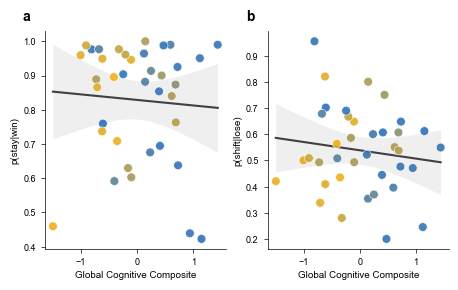

In [24]:
# ============================================================================
# 3.3 H1.1 — Figure 2: Cognition × WSLS (JNeurosci format) [REVISED]
# ============================================================================
# Changes from original:
#   1. Removed annotated stats at top of each panel
#   2. X-axis label changed to "Global Cognitive Composite"
#   3. Added age gradient colorbar on right side
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(WIDTH_1_5COL, WIDTH_1COL * 0.85))

for col_idx, (dv, dv_label) in enumerate([
    ('sham_p_stay_win', 'p(stay|win)'),
    ('sham_p_shift_lose', 'p(shift|lose)')
]):
    ax = axes[col_idx]
    df = subj[[COG_COMPOSITE, dv, 'age']].dropna()
    x = df[COG_COMPOSITE].astype(float).values
    y = df[dv].astype(float).values
    age = df['age'].astype(float).values

    # --- Scatter with age coloring ---
    norm = plt.Normalize(AGE_MIN, AGE_MAX)
    colors = AGE_CMAP(norm(age))
    ax.scatter(x, y, c=colors, s=40, alpha=0.85, edgecolors='white',
               linewidths=0.5, zorder=3)

    # --- OLS regression line + 95% CI band ---
    slope, intercept, r, p, se = stats.linregress(x, y)
    n = len(x)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = intercept + slope * x_line

    y_pred = intercept + slope * x
    resid_se = np.sqrt(np.sum((y - y_pred)**2) / (n - 2))
    x_mean = x.mean()
    ss_x = np.sum((x - x_mean)**2)
    ci = stats.t.ppf(0.975, n - 2) * resid_se * np.sqrt(1/n + (x_line - x_mean)**2 / ss_x)

    ax.fill_between(x_line, y_line - ci, y_line + ci,
                    color='gray', alpha=0.12, linewidth=0)
    ax.plot(x_line, y_line, color='#404040', linewidth=1.5, zorder=2)

    # --- NO stats annotation (removed per revision) ---

    # --- Axis styling ---
    style_ax(ax, xlabel='Global Cognitive Composite', ylabel=dv_label)

    # --- Panel label ---
    ax.text(-0.12, 1.05, chr(97 + col_idx), transform=ax.transAxes,
            fontsize=FONT_PANEL_LABEL, fontfamily=FONT_FAMILY, fontweight='bold')

# --- Age colorbar on right side ---
#sm = plt.cm.ScalarMappable(cmap=AGE_CMAP, norm=plt.Normalize(AGE_MIN, AGE_MAX))
#sm.set_array([])
#cbar = fig.colorbar(sm, ax=axes, shrink=0.7, pad=0.03, aspect=20)
#cbar.set_label('Age (years)', fontsize=FONT_AXIS_TITLE, fontfamily=FONT_FAMILY)
#cbar.ax.tick_params(labelsize=FONT_TICK)

plt.tight_layout(pad=0.5)
plt.savefig(str(FIG_DIR / 'fig_h1_1_cognition_wsls.png'), dpi=300, bbox_inches='tight')
plt.savefig(str(FIG_DIR / 'fig_h1_1_cognition_wsls.svg'), format='svg', bbox_inches='tight')
plt.show()

---
## 4. H1.1 Exploratory (§3.3.1)

1. Task-derived β predicts lose-shifting
2. Age × Cognition interactions on lose-shifting, α, and β

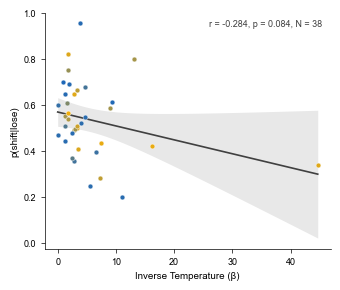


Bivariate (full sample): r = -0.284, p = 0.084, N = 38

── Preregistered specification (with education covariate) ──

p(shift|lose) ~ β + Global Cog + Age + Education
  N = 35
  F(4, 30) = 1.11, p = 0.368, R² = 0.129
  sham_beta                : b = -0.0069, β = -0.324, p = 0.091
  global_reduced           : b = -0.0640, β = -0.264, p = 0.242
  age                      : b = -0.0006, β = -0.080, p = 0.734
  education_years          : b = -0.0001, β = -0.001, p = 0.996

── Full sample (education dropped to preserve N) ──

p(shift|lose) ~ β + Global Cog + Age
  N = 38
  F(3, 34) = 1.67, p = 0.192, R² = 0.128
  sham_beta                : b = -0.0068, β = -0.317, p = 0.067
  global_reduced           : b = -0.0611, β = -0.260, p = 0.192
  age                      : b = -0.0007, β = -0.092, p = 0.645

── Sensitivity check ──
  With education (N=35):    β p = 0.091
  Without education (N=38): β p = 0.067


In [27]:
# ============================================================================
# 3.3.1a — β predicts lose-shifting
# ============================================================================

# Bivariate (full sample)
df_beta = subj[['sham_beta', 'sham_p_shift_lose', 'age']].dropna()
x = df_beta['sham_beta'].astype(float).values
y = df_beta['sham_p_shift_lose'].astype(float).values
age = df_beta['age'].astype(float).values

fig, ax = plt.subplots(figsize=(WIDTH_1COL, WIDTH_1COL * 0.85))
stats_beta = scatter_regression_mpl(ax, x, y, age)
style_ax(ax, xlabel='Inverse Temperature (β)', ylabel='p(shift|lose)')
plt.tight_layout(pad=0.5)
plt.savefig(str(FIG_DIR / 'fig_h1_1_beta_loseshift.png'), dpi=300, bbox_inches='tight')
plt.savefig(str(FIG_DIR / 'fig_h1_1_beta_loseshift.svg'), format='svg', bbox_inches='tight')
plt.show()

print(f'\nBivariate (full sample): r = {stats_beta["r"]:.3f}, p = {stats_beta["p"]:.3f}, N = {stats_beta["n"]}')

# ── Model 1: Preregistered specification (with education, reduced N) ──
print(f'\n── Preregistered specification (with education covariate) ──')
h1_beta_prereg, df_prereg = run_h1_regression(
    'sham_p_shift_lose',
    ['sham_beta', COG_COMPOSITE, 'age', 'education_years'],
    subj,
    'p(shift|lose) ~ β + Global Cog + Age + Education',
)

# ── Model 2: Full sample (without education) ──
print(f'\n── Full sample (education dropped to preserve N) ──')
h1_beta_full, df_full = run_h1_regression(
    'sham_p_shift_lose',
    ['sham_beta', COG_COMPOSITE, 'age'],
    subj,
    'p(shift|lose) ~ β + Global Cog + Age',
)

# ── Comparison ──
print(f'\n── Sensitivity check ──')
if h1_beta_prereg is not None and h1_beta_full is not None:
    p_prereg = h1_beta_prereg.pvalues['sham_beta']
    p_full = h1_beta_full.pvalues['sham_beta']
    n_prereg = int(h1_beta_prereg.nobs)
    n_full = int(h1_beta_full.nobs)
    print(f'  With education (N={n_prereg}):    β p = {p_prereg:.3f}{" *" if p_prereg < .05 else ""}')
    print(f'  Without education (N={n_full}): β p = {p_full:.3f}{" *" if p_full < .05 else ""}')
    if p_prereg < .05 and p_full >= .05:
        print(f'  → Effect significant in preregistered model but attenuated at full N.')
        print(f'    {abs(n_full - n_prereg)} subjects excluded by missing education data;')
        print(f'    result is sensitive to sample composition.')
    elif p_prereg < .05 and p_full < .05:
        print(f'  → Effect robust across both specifications.')


In [29]:
# ============================================================================
# 3.3.1b — Age × Cognition interactions
# ============================================================================
# Three DVs: p(shift|lose), α, β
# Each tested as: DV ~ global_cog * age + education (mean-centered)

from scipy.optimize import brentq

interaction_dvs = [
    ('sham_p_shift_lose', 'p(shift|lose)'),
    ('sham_alpha', 'Learning Rate (α)'),
    ('sham_beta', 'Inverse Temperature (β)'),
]

interaction_results = {}

for dv_col, dv_label in interaction_dvs:
    # Prepare data — mean-center continuous predictors
    cols = [dv_col, COG_COMPOSITE, 'age', 'education_years']
    df = subj[['subject_id'] + cols].dropna().copy()
    for c in [COG_COMPOSITE, 'age']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df['cog_c'] = df[COG_COMPOSITE] - df[COG_COMPOSITE].mean()
    df['age_c'] = df['age'] - df['age'].mean()
    df['cog_x_age'] = df['cog_c'] * df['age_c']
    
    y = df[dv_col].astype(float)
    X = sm.add_constant(df[['cog_c', 'age_c', 'education_years', 'cog_x_age']].astype(float))
    model = sm.OLS(y, X).fit()
    
    int_b = model.params['cog_x_age']
    int_p = model.pvalues['cog_x_age']
    int_sig = ' *' if int_p < .05 else ''
    delta_r2 = model.rsquared - sm.OLS(y, sm.add_constant(
        df[['cog_c', 'age_c', 'education_years']].astype(float))).fit().rsquared
    
    interaction_results[dv_col] = {
        'model': model, 'int_b': int_b, 'int_p': int_p,
        'delta_r2': delta_r2, 'n': int(model.nobs),
    }
    
    print(f'\n{dv_label}: Cognition × Age interaction')
    print(f'  N = {int(model.nobs)}')
    print(f'  Interaction b = {int_b:+.4f}, p = {int_p:.3f}{int_sig}')
    print(f'  ΔR² = {delta_r2:.3f}')
    print(f'  Full model R² = {model.rsquared:.3f}')


p(shift|lose): Cognition × Age interaction
  N = 35
  Interaction b = +0.0055, p = 0.017 *
  ΔR² = 0.168
  Full model R² = 0.209

Learning Rate (α): Cognition × Age interaction
  N = 35
  Interaction b = +0.0096, p = 0.106
  ΔR² = 0.081
  Full model R² = 0.125

Inverse Temperature (β): Cognition × Age interaction
  N = 35
  Interaction b = -0.2020, p = 0.053
  ΔR² = 0.101
  Full model R² = 0.255


Interaction model (N = 35):
  Cog × Age: b = 0.0055, p = 0.017
  ΔR² = 0.168, full model R² = 0.209
  Johnson-Neyman threshold(s): [np.float64(29.3)]
  Region of significance: ages 19.8–29.3


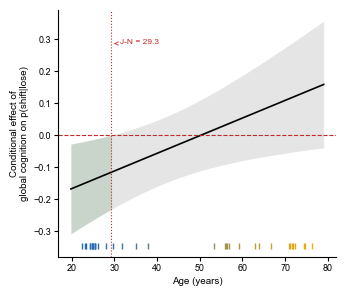


Figure 3 stats (for legend text):
  Cog × Age: b = 0.0055, p = 0.017
  ΔR² = 0.168, N = 35
  J-N threshold(s): [np.float64(29.3)]


In [31]:
# ============================================================================
# 3.3.1b — Figure 3: Johnson-Neyman (Age × Cognition on lose-shifting)
#          JNeurosci format
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
from scipy.stats import t as t_dist

# ── Fit the interaction model ──
cols = ['sham_p_shift_lose', COG_COMPOSITE, 'age', 'education_years']
df_jn = subj[['subject_id'] + cols].dropna().copy()
for c in cols:
    df_jn[c] = pd.to_numeric(df_jn[c], errors='coerce')
df_jn = df_jn.dropna()

age_mean = df_jn['age'].mean()
cog_mean = df_jn[COG_COMPOSITE].mean()
df_jn['cog_c'] = df_jn[COG_COMPOSITE] - cog_mean
df_jn['age_c'] = df_jn['age'] - age_mean
df_jn['cog_x_age'] = df_jn['cog_c'] * df_jn['age_c']

y = df_jn['sham_p_shift_lose'].astype(float)
X = sm.add_constant(df_jn[['cog_c', 'age_c', 'education_years', 'cog_x_age']].astype(float))
model = sm.OLS(y, X).fit()

b_cog = model.params['cog_c']
b_int = model.params['cog_x_age']
vcov = model.cov_params()
var_cog = vcov.loc['cog_c', 'cog_c']
var_int = vcov.loc['cog_x_age', 'cog_x_age']
cov_cog_int = vcov.loc['cog_c', 'cog_x_age']
df_resid = model.df_resid

# ── Conditional effect across age range ──
age_min, age_max = df_jn['age'].min(), df_jn['age'].max()
age_pad = 0.05 * (age_max - age_min)
age_range = np.linspace(age_min - age_pad, age_max + age_pad, 300)
age_range_c = age_range - age_mean

cond_slope = b_cog + b_int * age_range_c
cond_se = np.sqrt(var_cog + 2 * age_range_c * cov_cog_int + age_range_c**2 * var_int)

t_vals = cond_slope / cond_se
p_vals = 2 * (1 - t_dist.cdf(np.abs(t_vals), df_resid))

t_crit = t_dist.ppf(0.975, df_resid)
upper = cond_slope + t_crit * cond_se
lower = cond_slope - t_crit * cond_se

# ── J-N thresholds ──
sig_mask = p_vals < 0.05
jn_points = []
for i in range(len(sig_mask) - 1):
    if sig_mask[i] != sig_mask[i + 1]:
        frac = abs(p_vals[i] - 0.05) / (abs(p_vals[i] - 0.05) + abs(p_vals[i + 1] - 0.05))
        jn_points.append(round(age_range[i] + frac * (age_range[i + 1] - age_range[i]), 1))

# ── ΔR² ──
X_no_int = sm.add_constant(df_jn[['cog_c', 'age_c', 'education_years']].astype(float))
model_no_int = sm.OLS(y, X_no_int).fit()
delta_r2 = model.rsquared - model_no_int.rsquared

# Print results
print(f'Interaction model (N = {int(model.nobs)}):')
print(f'  Cog × Age: b = {b_int:.4f}, p = {model.pvalues["cog_x_age"]:.3f}')
print(f'  ΔR² = {delta_r2:.3f}, full model R² = {model.rsquared:.3f}')
print(f'  Johnson-Neyman threshold(s): {jn_points}')
sig_ages = age_range[sig_mask]
if len(sig_ages) > 0:
    print(f'  Region of significance: ages {sig_ages.min():.1f}–{sig_ages.max():.1f}')

# ── JNeurosci constants ────────────────────────────────────────────────────
CM_TO_IN = 1 / 2.54
WIDTH_1COL = 8.5 * CM_TO_IN

FONT_FAMILY = 'Arial'
FONT_AXIS_TITLE = 7
FONT_TICK = 6.5
FONT_PANEL_LABEL = 10
FONT_JN_LABEL = 6
FONT_LEGEND = 6

SIG_COLOR = '#2E7D32'
ZERO_COLOR = '#C62828'
JN_COLOR = '#C62828'

# ── Build figure ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(WIDTH_1COL, WIDTH_1COL * 0.85))

# CI band
ax.fill_between(age_range, lower, upper, color='gray', alpha=0.20,
                label='95% CI', linewidth=0)

# Significant region
ax.fill_between(age_range, lower, upper, where=sig_mask,
                color=SIG_COLOR, alpha=0.15,
                label='Significant region (p < .05)', linewidth=0)

# Conditional slope
ax.plot(age_range, cond_slope, color='black', linewidth=1.2,
        label='Conditional effect')

# Zero reference
ax.axhline(0, color=ZERO_COLOR, linestyle='--', linewidth=0.8,
           label='Zero (no effect)')

# J-N thresholds
for idx, jn_age in enumerate(jn_points):
    ax.axvline(jn_age, color=JN_COLOR, linestyle=':', linewidth=0.8,
               label='J-N threshold' if idx == 0 else None)
    y_pos = max(upper) * 0.80
    ax.annotate(f'J-N = {jn_age:.1f}',
                xy=(jn_age, y_pos),
                xytext=(jn_age + 2.0, y_pos),
                fontsize=FONT_JN_LABEL, color=JN_COLOR, fontfamily=FONT_FAMILY,
                arrowprops=dict(arrowstyle='->', color=JN_COLOR, lw=0.6))

# Age rug (colored by age)
rug_y = min(lower) * 1.12
for age_val in df_jn['age'].values:
    ax.plot(age_val, rug_y, '|', color=age_to_hex(age_val),
            markersize=4, markeredgewidth=1.0)

# Labels
ax.set_xlabel('Age (years)', fontsize=FONT_AXIS_TITLE,
              fontfamily=FONT_FAMILY, labelpad=3)
ax.set_ylabel('Conditional effect of\nglobal cognition on p(shift|lose)',
              fontsize=FONT_AXIS_TITLE, fontfamily=FONT_FAMILY, labelpad=3)

# Spines and ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='both', which='major', labelsize=FONT_TICK,
               width=0.8, length=3, pad=2)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FONT_FAMILY)
ax.set_facecolor('white')

# No legend -- elements described in figure caption
#ax.legend(fontsize=FONT_LEGEND, loc='lower right', framealpha=0.9,
#          edgecolor='none', prop={'family': FONT_FAMILY})

plt.tight_layout(pad=0.3)
fig.savefig(str(FIG_DIR / 'fig3_h1_1_jn_loseshift.svg'),
            format='svg', bbox_inches='tight', pad_inches=0.02)
fig.savefig(str(FIG_DIR / 'fig3_h1_1_jn_loseshift.png'),
            dpi=600, bbox_inches='tight', pad_inches=0.02)
plt.show()

print('\nFigure 3 stats (for legend text):')
print(f'  Cog × Age: b = {b_int:.4f}, p = {model.pvalues["cog_x_age"]:.3f}')
print(f'  ΔR² = {delta_r2:.3f}, N = {int(model.nobs)}')
print(f'  J-N threshold(s): {jn_points}')

---
## 5. H1.2: Reward/Punishment Sensitivity (§3.4)

In [34]:
# ============================================================================
# 3.4 H1.2 — Statistical tests
# ============================================================================

# H1.2a: p(stay|win) ~ SPSRQ-SR + global_composite + age + education
h1_2a_model, h1_2a_df = run_h1_regression(
    'sham_p_stay_win',
    ['spsrq_sr', COG_COMPOSITE, 'age', 'education_years'],
    subj,
    'H1.2a: p(stay|win) ~ SPSRQ-SR + Global Cog + Age + Education',
)

# ΔR² for SR over H1.1a
if h1_2a_model is not None and h1_1a_model is not None:
    delta_r2_sr = h1_2a_model.rsquared - h1_1a_model.rsquared
    print(f'  ΔR² (adding SR): {delta_r2_sr:+.3f}')

# H1.2b: p(shift|lose) ~ SPSRQ-SP + global_composite + age + education
h1_2b_model, h1_2b_df = run_h1_regression(
    'sham_p_shift_lose',
    ['spsrq_sp', COG_COMPOSITE, 'age', 'education_years'],
    subj,
    'H1.2b: p(shift|lose) ~ SPSRQ-SP + Global Cog + Age + Education',
)

if h1_2b_model is not None and h1_1b_model is not None:
    delta_r2_sp = h1_2b_model.rsquared - h1_1b_model.rsquared
    print(f'  ΔR² (adding SP): {delta_r2_sp:+.3f}')


H1.2a: p(stay|win) ~ SPSRQ-SR + Global Cog + Age + Education
  N = 31
  F(4, 26) = 1.25, p = 0.314, R² = 0.162
  spsrq_sr                 : b = -0.0005, β = -0.013, p = 0.945
  global_reduced           : b = +0.0146, β = +0.056, p = 0.824
  age                      : b = +0.0000, β = +0.006, p = 0.983
  education_years          : b = +0.0342, β = +0.400, p = 0.044 *
  ΔR² (adding SR): +0.043

H1.2b: p(shift|lose) ~ SPSRQ-SP + Global Cog + Age + Education
  N = 31
  F(4, 26) = 0.21, p = 0.928, R² = 0.032
  spsrq_sp                 : b = -0.0030, β = -0.173, p = 0.417
  global_reduced           : b = -0.0044, β = -0.020, p = 0.943
  age                      : b = -0.0000, β = -0.001, p = 0.998
  education_years          : b = +0.0008, β = +0.010, p = 0.960
  ΔR² (adding SP): -0.009


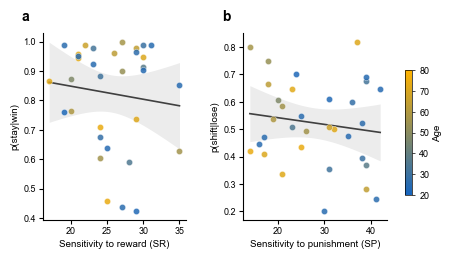

Supplementary Figure 2 stats (for legend text):
  spsrq_sr: r = -0.115, p = 0.525, N = 33
  spsrq_sp: r = -0.143, p = 0.428, N = 33


In [36]:
# ============================================================================
# Supplementary Figure 2: SPSRQ × WSLS (JNeurosci format)
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats

CM_TO_IN = 1 / 2.54
WIDTH_1_5COL = 11.5 * CM_TO_IN

FONT_FAMILY = 'Arial'
FONT_AXIS_TITLE = 7
FONT_TICK = 6.5
FONT_PANEL_LABEL = 10

REGRESSION_COLOR = '#404040'
CI_COLOR = 'gray'
CI_ALPHA = 0.15

fig, axes = plt.subplots(1, 2, figsize=(WIDTH_1_5COL, WIDTH_1_5COL * 0.55))
plt.subplots_adjust(left=0.12, right=0.88, bottom=0.15, top=0.90, wspace=0.40)

panels = [
    ('spsrq_sr', 'sham_p_stay_win', 'Sensitivity to reward (SR)', 'p(stay|win)', 'a'),
    ('spsrq_sp', 'sham_p_shift_lose', 'Sensitivity to punishment (SP)', 'p(shift|lose)', 'b'),
]

sfig2_stats = {}
for ax, (pred, dv, xlabel, ylabel, label) in zip(axes, panels):
    df = subj[[pred, dv, 'age']].dropna()
    x = df[pred].astype(float).values
    y = df[dv].astype(float).values
    age = df['age'].astype(float).values
    n = len(x)

    if n < 5:
        print(f'Insufficient SPSRQ data for {pred} (n={n})')
        continue

    # Age-colored points
    for xi, yi, ai in zip(x, y, age):
        norm_val = np.clip((ai - AGE_MIN) / (AGE_MAX - AGE_MIN), 0, 1)
        r_c, g_c, b_c, _ = AGE_CMAP(norm_val)
        color = f'#{int(r_c*255):02x}{int(g_c*255):02x}{int(b_c*255):02x}'
        ax.plot(xi, yi, 'o', color=color, markersize=4.5,
                markeredgecolor='white', markeredgewidth=0.3,
                alpha=0.85, zorder=3)

    # OLS regression + 95% CI
    slope, intercept, r, p, se = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = intercept + slope * x_line

    y_pred = intercept + slope * x
    resid_se = np.sqrt(np.sum((y - y_pred)**2) / (n - 2))
    ss_x = np.sum((x - x.mean())**2)
    ci = stats.t.ppf(0.975, n - 2) * resid_se * np.sqrt(1/n + (x_line - x.mean())**2 / ss_x)

    ax.fill_between(x_line, y_line - ci, y_line + ci,
                     color=CI_COLOR, alpha=CI_ALPHA, zorder=1, linewidth=0)
    ax.plot(x_line, y_line, color=REGRESSION_COLOR, linewidth=1.2, zorder=2)

    # Labels
    ax.set_xlabel(xlabel, fontsize=FONT_AXIS_TITLE, fontfamily=FONT_FAMILY, labelpad=3)
    ax.set_ylabel(ylabel, fontsize=FONT_AXIS_TITLE, fontfamily=FONT_FAMILY, labelpad=3)

    # Panel label
    ax.text(-0.15, 1.05, label, transform=ax.transAxes,
            fontsize=FONT_PANEL_LABEL, fontfamily=FONT_FAMILY,
            fontweight='bold', va='bottom', ha='left')

    # Spines and ticks
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.tick_params(axis='both', which='major', labelsize=FONT_TICK,
                   width=0.8, length=3, pad=2)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily(FONT_FAMILY)
    ax.set_facecolor('white')

    sfig2_stats[pred] = {'r': r, 'p': p, 'n': n}

# Age colorbar
norm = mcolors.Normalize(vmin=AGE_MIN, vmax=AGE_MAX)
sm = plt.cm.ScalarMappable(cmap=AGE_CMAP, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.50])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Age', fontsize=FONT_AXIS_TITLE, fontfamily=FONT_FAMILY, labelpad=3)
cbar.ax.tick_params(labelsize=FONT_TICK, width=0.5, length=2)
cbar.outline.set_linewidth(0.5)
for lbl in cbar.ax.get_yticklabels():
    lbl.set_fontfamily(FONT_FAMILY)

fig.savefig(str(FIG_DIR / 'sfig2_h1_2_spsrq_wsls.svg'),
            format='svg', bbox_inches='tight', pad_inches=0.02)
fig.savefig(str(FIG_DIR / 'sfig2_h1_2_spsrq_wsls.png'),
            dpi=600, bbox_inches='tight', pad_inches=0.02)
plt.show()

print('Supplementary Figure 2 stats (for legend text):')
for pred, s in sfig2_stats.items():
    print(f'  {pred}: r = {s["r"]:.3f}, p = {s["p"]:.3f}, N = {s["n"]}')

In [38]:
# ============================================================================
# 3.4.1 — SPSRQ × Age interactions (null)
# ============================================================================

import statsmodels.api as sm

spsrq_int_dvs = [
    ('sham_p_stay_win', 'spsrq_sr', 'p(stay|win)', 'SR × Age'),
    ('sham_p_shift_lose', 'spsrq_sp', 'p(shift|lose)', 'SP × Age'),
]

for dv_col, spsrq_col, dv_label, int_label in spsrq_int_dvs:
    cols = [dv_col, spsrq_col, 'age', 'education_years', COG_COMPOSITE]
    df = subj[['subject_id'] + cols].dropna().copy()
    for c in [spsrq_col, 'age']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna()
    
    if len(df) < 10:
        print(f'{int_label}: insufficient data (n={len(df)})')
        continue
    
    df['spsrq_c'] = df[spsrq_col] - df[spsrq_col].mean()
    df['age_c'] = df['age'] - df['age'].mean()
    df['spsrq_x_age'] = df['spsrq_c'] * df['age_c']
    
    y = df[dv_col].astype(float)
    X = sm.add_constant(df[['spsrq_c', 'age_c', COG_COMPOSITE,
                            'education_years', 'spsrq_x_age']].astype(float))
    model = sm.OLS(y, X).fit()
    
    p_int = model.pvalues['spsrq_x_age']
    sig = ' *' if p_int < .05 else ''
    print(f'{int_label} → {dv_label}: interaction b = {model.params["spsrq_x_age"]:+.4f}, '
          f'p = {p_int:.3f}{sig}, N = {int(model.nobs)}')

print(f'\n→ SPSRQ × Age interactions are null.')
print(f'  The age moderation of baseline learning is specific to cognitive function.')

SR × Age → p(stay|win): interaction b = +0.0001, p = 0.798, N = 31
SP × Age → p(shift|lose): interaction b = +0.0000, p = 0.848, N = 31

→ SPSRQ × Age interactions are null.
  The age moderation of baseline learning is specific to cognitive function.


---
## 5.1 Reversal Learning Analyses

Trials-to-criterion, phase decomposition, and reversal-locked accuracy curves.  
Uses consistent median age split throughout.

REVERSAL LEARNING ANALYSES
Identifying reversals in trial-level data...
  Identified 579 reversals across 38 subjects

1. TRIALS-TO-CRITERION (active vs sham + age moderation)
  Sham TTC:   M = 4.31 trials (SD = 2.94)
  Active TTC: M = 4.49 trials (SD = 2.59)
  Δ = +0.18, t(34) = 0.284, p = 0.778, dz = 0.048

  Age × Δ TTC: r = 0.231, p = 0.183, N = 35

2. STABLE vs TRANSITION PHASE ACCURACY

  STABLE phase (N = 35):
    Sham:   M = 0.669
    Active: M = 0.671
    Δ = +0.0024, t(34) = 0.106, p = 0.916, dz = 0.018

  TRANSITION phase (N = 35):
    Sham:   M = 0.565
    Active: M = 0.527
    Δ = -0.0384, t(34) = -1.527, p = 0.136, dz = -0.258

  Phase × Condition interaction:
    Difference-of-differences: M = -0.0408
    t(34) = -1.266, p = 0.214
    → Not significant: tACS does not differentially affect transition vs stable phases

3. REVERSAL-LOCKED ACCURACY CURVES (active vs sham)
  Tested 21 trial positions
  No trial positions showed significant active vs sham differences

  Post-r

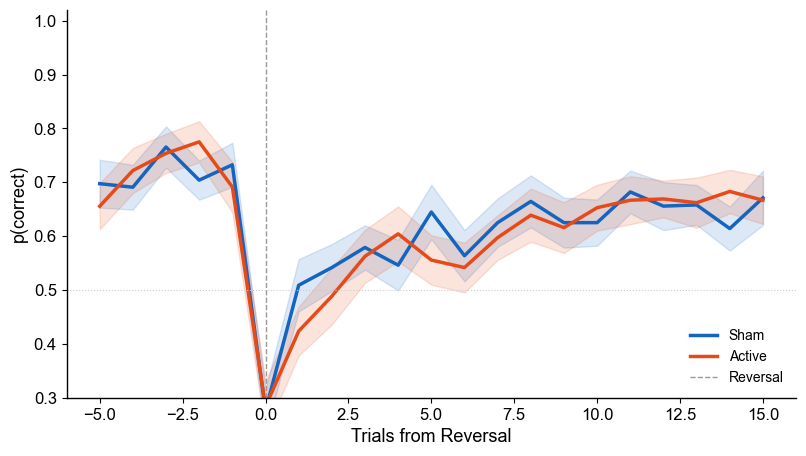


REVERSAL LEARNING SUMMARY
  Trials-to-criterion: dz = 0.048, p = 0.778 → Not significant
  Age × Δ TTC: r = 0.231, p = 0.183 → Not significant
  Reversal-locked curve: 0 of 21 positions significant at p < .05 (uncorrected)
  → tACS does not show a clear effect on reversal adaptation dynamics


In [53]:
# ============================================================================
# 3.5b — Reversal Learning Analyses
# ============================================================================
# Three analyses mapping onto Wischnewski's framework:
# 1. Trials-to-criterion: active vs sham + age moderation
# 2. Stable-phase vs transition-phase accuracy by condition
# 3. Reversal-locked accuracy curves: active vs sham statistical comparison
#
# Requires: trials (clean trial-level data with reversal columns),
#           subj (master subject dataframe), h2_eligible list
# ============================================================================

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

print('=' * 70)
print('REVERSAL LEARNING ANALYSES')
print('=' * 70)

# ── Step 0: Identify reversals if not already done ──
if 'trial_from_rev' not in trials.columns or trials['trial_from_rev'].isna().all():
    print('Identifying reversals in trial-level data...')
    trials = trials.copy()
    trials['is_reversal'] = False
    trials['reversal_id'] = pd.Series(index=trials.index, dtype='object')
    trials['trial_from_rev'] = np.nan
    trials['in_rev_window'] = False

    window_pre, window_post = 5, 15

    for (sub_id, run), group in trials.groupby(['subject_id', 'run']):
        idx = group.index
        good = group['current_good'].values

        rev_mask = np.zeros(len(good), dtype=bool)
        rev_mask[1:] = good[1:] != good[:-1]
        rev_trials = np.where(rev_mask)[0]

        if len(rev_trials) == 0:
            continue

        for rev_i, rev_pos in enumerate(rev_trials):
            rev_id = f'{sub_id}_run{run}_rev{rev_i}'
            trials.loc[idx[rev_pos], 'is_reversal'] = True

            for offset in range(-window_pre, window_post + 1):
                t = rev_pos + offset
                if 0 <= t < len(idx):
                    trial_idx = idx[t]
                    current_dist = trials.loc[trial_idx, 'trial_from_rev']
                    if pd.isna(current_dist) or abs(offset) < abs(current_dist):
                        trials.loc[trial_idx, 'trial_from_rev'] = offset
                        trials.loc[trial_idx, 'reversal_id'] = rev_id
                        trials.loc[trial_idx, 'in_rev_window'] = True

    n_rev = trials['is_reversal'].sum()
    n_sub = trials.loc[trials['is_reversal'], 'subject_id'].nunique()
    print(f'  Identified {n_rev} reversals across {n_sub} subjects')
else:
    n_rev = trials['is_reversal'].sum()
    print(f'  Reversal columns already present ({n_rev} reversals)')

# ── Step 1: Trials-to-criterion ──
print(f'\n{"=" * 70}')
print('1. TRIALS-TO-CRITERION (active vs sham + age moderation)')
print('=' * 70)

CRITERION = 3  # consecutive correct choices

def compute_ttc(df, criterion=3):
    """Compute trials-to-criterion for each reversal."""
    results = []
    rev_trials = df[df['in_rev_window'] & (df['trial_from_rev'] >= 0) &
                     df['choice'].notna()].copy()

    for rev_id, group in rev_trials.groupby('reversal_id'):
        group = group.sort_values('trial_from_rev')
        sub_id = str(group['subject_id'].iloc[0])
        condition = group['condition'].iloc[0] if 'condition' in group.columns else 'unknown'

        correct_vals = group['correct'].values
        consecutive = 0
        ttc = np.nan

        for i, c in enumerate(correct_vals):
            if c == True:
                consecutive += 1
                if consecutive >= criterion:
                    ttc = group['trial_from_rev'].iloc[i - criterion + 1]
                    break
            else:
                consecutive = 0

        results.append({
            'subject_id': sub_id,
            'condition': condition,
            'reversal_id': rev_id,
            'trials_to_criterion': ttc,
        })

    return pd.DataFrame(results)

ttc_df = compute_ttc(trials, criterion=CRITERION)

# Average across reversals within each subject × condition
ttc_subj = (ttc_df.groupby(['subject_id', 'condition'])['trials_to_criterion']
            .mean().reset_index())

# Paired comparison: active vs sham
ttc_paired = ttc_subj.pivot(index='subject_id', columns='condition',
                             values='trials_to_criterion')

if 'active' in ttc_paired.columns and 'sham' in ttc_paired.columns:
    ttc_clean = ttc_paired[['active', 'sham']].dropna()
    ttc_clean = ttc_clean[ttc_clean.index.isin(h2_eligible)]
    n_ttc = len(ttc_clean)

    if n_ttc >= 3:
        t_ttc, p_ttc = stats.ttest_rel(ttc_clean['active'], ttc_clean['sham'])
        diff_ttc = ttc_clean['active'] - ttc_clean['sham']
        dz_ttc = diff_ttc.mean() / diff_ttc.std() if diff_ttc.std() > 0 else 0

        print(f'  Sham TTC:   M = {ttc_clean["sham"].mean():.2f} trials (SD = {ttc_clean["sham"].std():.2f})')
        print(f'  Active TTC: M = {ttc_clean["active"].mean():.2f} trials (SD = {ttc_clean["active"].std():.2f})')
        print(f'  Δ = {diff_ttc.mean():+.2f}, t({n_ttc-1}) = {t_ttc:.3f}, p = {p_ttc:.3f}, dz = {dz_ttc:.3f}')

        # Age moderation of Δ TTC
        ttc_clean_age = ttc_clean.copy()
        ttc_clean_age['delta_ttc'] = ttc_clean_age['active'] - ttc_clean_age['sham']
        ttc_clean_age = ttc_clean_age.merge(
            subj[['subject_id', 'age']].astype({'subject_id': str}),
            left_index=True, right_on='subject_id', how='left'
        )
        ttc_age = ttc_clean_age[['age', 'delta_ttc']].dropna()
        ttc_age['age'] = pd.to_numeric(ttc_age['age'], errors='coerce')
        ttc_age = ttc_age.dropna()

        if len(ttc_age) >= 5:
            r_age, p_age = stats.pearsonr(ttc_age['age'].values, ttc_age['delta_ttc'].values)
            print(f'\n  Age × Δ TTC: r = {r_age:.3f}, p = {p_age:.3f}, N = {len(ttc_age)}')
    else:
        print(f'  Insufficient paired data (N = {n_ttc})')

# ── Step 2: Stable vs Transition phase accuracy ──
print(f'\n{"=" * 70}')
print('2. STABLE vs TRANSITION PHASE ACCURACY')
print('=' * 70)

# Define phases relative to reversals
# Transition: first 10 trials after reversal (trial_from_rev 0 to 9)
# Stable: last 10 trials before reversal (trial_from_rev -10 to -1)
# Also: stable = trials far from any reversal (middle of contingency block)

# Use contingency structure: for each run, identify contingency blocks
# and classify trials as "transition" (first 10 of block) or "stable" (rest)

def classify_trial_phase(df, transition_window=10):
    """Classify each trial as 'transition' or 'stable' within its contingency block."""
    df = df.copy()
    df['phase'] = 'stable'

    for (sub_id, run), group in df.groupby(['subject_id', 'run']):
        idx = group.index
        good = group['current_good'].values

        # Find contingency boundaries
        boundaries = [0]
        for i in range(1, len(good)):
            if good[i] != good[i-1]:
                boundaries.append(i)
        boundaries.append(len(good))

        # Mark first transition_window trials of each block as "transition"
        for b in range(len(boundaries) - 1):
            block_start = boundaries[b]
            block_end = boundaries[b + 1]
            # Skip first block (initial learning, not a reversal)
            if b == 0:
                continue
            trans_end = min(block_start + transition_window, block_end)
            for t in range(block_start, trans_end):
                df.loc[idx[t], 'phase'] = 'transition'

    return df

trials = classify_trial_phase(trials, transition_window=10)

# Compute accuracy by subject × condition × phase
phase_acc = (trials[trials['choice'].notna() & trials['condition'].isin(['sham', 'active'])]
             .groupby(['subject_id', 'condition', 'phase'])['correct']
             .mean().reset_index()
             .rename(columns={'correct': 'accuracy'}))

# Pivot for paired tests
for phase in ['stable', 'transition']:
    phase_data = phase_acc[phase_acc['phase'] == phase].pivot(
        index='subject_id', columns='condition', values='accuracy')

    if 'active' in phase_data.columns and 'sham' in phase_data.columns:
        clean = phase_data[['active', 'sham']].dropna()
        clean = clean.astype(float)
        clean = clean[clean.index.isin([str(s) for s in h2_eligible])]
        n = len(clean)

        if n >= 3:
            t, p = stats.ttest_rel(clean['active'], clean['sham'])
            diff = clean['active'] - clean['sham']
            dz = diff.mean() / diff.std() if diff.std() > 0 else 0

            print(f'\n  {phase.upper()} phase (N = {n}):')
            print(f'    Sham:   M = {clean["sham"].mean():.3f}')
            print(f'    Active: M = {clean["active"].mean():.3f}')
            print(f'    Δ = {diff.mean():+.4f}, t({n-1}) = {t:.3f}, p = {p:.3f}, dz = {dz:.3f}')

# Phase × Condition interaction (is tACS differentially affecting transition vs stable?)
print(f'\n  Phase × Condition interaction:')
phase_wide = phase_acc.pivot_table(index='subject_id', columns=['condition', 'phase'],
                                     values='accuracy')
if ('active', 'transition') in phase_wide.columns and ('sham', 'transition') in phase_wide.columns \
   and ('active', 'stable') in phase_wide.columns and ('sham', 'stable') in phase_wide.columns:
    interaction_df = phase_wide.dropna()
    interaction_df = interaction_df[interaction_df.index.isin([str(s) for s in h2_eligible])]

    if len(interaction_df) >= 5:
        # Difference-of-differences: (active_trans - sham_trans) - (active_stable - sham_stable)
        delta_trans = interaction_df[('active', 'transition')] - interaction_df[('sham', 'transition')]
        delta_stable = interaction_df[('active', 'stable')] - interaction_df[('sham', 'stable')]
        interaction = delta_trans - delta_stable
        interaction = interaction.astype(float)

        t_int, p_int = stats.ttest_1samp(interaction.values, 0)
        print(f'    Difference-of-differences: M = {interaction.mean():+.4f}')
        print(f'    t({len(interaction)-1}) = {t_int:.3f}, p = {p_int:.3f}')
        print(f'    → {"Significant" if p_int < .05 else "Not significant"}: '
              f'tACS {"differentially" if p_int < .05 else "does not differentially"} '
              f'affect transition vs stable phases')

# ── Step 3: Reversal-locked accuracy curves ──
print(f'\n{"=" * 70}')
print('3. REVERSAL-LOCKED ACCURACY CURVES (active vs sham)')
print('=' * 70)

# Compute p(correct) at each trial position, per subject × condition
rev_data = trials[trials['in_rev_window'] & trials['choice'].notna() &
                   trials['condition'].isin(['sham', 'active'])].copy()

rev_acc = (rev_data.groupby(['subject_id', 'condition', 'trial_from_rev'])['correct']
           .mean().reset_index()
           .rename(columns={'correct': 'p_correct'}))

# Statistical comparison at each trial position (paired t-test)
positions = sorted(rev_acc['trial_from_rev'].unique())
curve_stats = []

for pos in positions:
    pos_data = rev_acc[rev_acc['trial_from_rev'] == pos].pivot(
        index='subject_id', columns='condition', values='p_correct')
    if 'active' in pos_data.columns and 'sham' in pos_data.columns:
        clean = pos_data[['active', 'sham']].dropna()
        clean = clean.astype(float)
        clean = clean[clean.index.isin([str(s) for s in h2_eligible])]
        if len(clean) >= 5:
            t, p = stats.ttest_rel(clean['active'], clean['sham'])
            curve_stats.append({
                'trial_from_rev': pos,
                'sham_mean': clean['sham'].mean(),
                'active_mean': clean['active'].mean(),
                'delta': (clean['active'] - clean['sham']).mean(),
                't': t, 'p': p, 'n': len(clean),
            })

curve_df = pd.DataFrame(curve_stats)

# Print summary of significant positions
sig_positions = curve_df[curve_df['p'] < .05]
print(f'  Tested {len(curve_df)} trial positions')
if len(sig_positions) > 0:
    print(f'  Significant at uncorrected p < .05: {len(sig_positions)} positions')
    for _, row in sig_positions.iterrows():
        print(f'    Trial {row["trial_from_rev"]:+.0f}: Δ = {row["delta"]:+.3f}, '
              f't = {row["t"]:.3f}, p = {row["p"]:.3f}')
else:
    print(f'  No trial positions showed significant active vs sham differences')

# Overall post-reversal accuracy (trials 1-10)
post_rev = curve_df[(curve_df['trial_from_rev'] >= 1) & (curve_df['trial_from_rev'] <= 10)]
if len(post_rev) > 0:
    print(f'\n  Post-reversal (trials 1-10) summary:')
    print(f'    Sham mean:   {post_rev["sham_mean"].mean():.3f}')
    print(f'    Active mean: {post_rev["active_mean"].mean():.3f}')
    print(f'    Mean Δ:      {post_rev["delta"].mean():+.3f}')

# ── Figure: Reversal-locked accuracy curves ──
fig, ax = plt.subplots(figsize=(8, 4.5))

rev_acc['p_correct'] = pd.to_numeric(rev_acc['p_correct'], errors='coerce')
for cond, color, label in [('sham', '#1565C0', 'Sham'), ('active', '#E64A19', 'Active')]:
    cond_means = rev_acc[rev_acc['condition'] == cond].groupby('trial_from_rev')['p_correct'].agg(['mean', 'sem'])
    cond_means = cond_means.reindex(positions)
    ax.plot(cond_means.index, cond_means['mean'], color=color, linewidth=2.5, label=label)
    ax.fill_between(cond_means.index,
                     cond_means['mean'] - cond_means['sem'],
                     cond_means['mean'] + cond_means['sem'],
                     color=color, alpha=0.15)

# Mark significant positions
if len(sig_positions) > 0:
    for _, row in sig_positions.iterrows():
        ax.plot(row['trial_from_rev'], 0.98, '*', color='black', markersize=8)

# Reversal line
ax.axvline(0, color='#999999', linewidth=1, linestyle='--', label='Reversal')
ax.axhline(0.5, color='#CCCCCC', linewidth=0.8, linestyle=':')

ax.set_xlabel('Trials from Reversal', fontsize=13, fontfamily='Arial')
ax.set_ylabel('p(correct)', fontsize=13, fontfamily='Arial')
ax.set_ylim(0.3, 1.02)
ax.tick_params(labelsize=12)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily('Arial')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.set_facecolor('white')
ax.grid(False)
ax.legend(fontsize=11, loc='lower right', framealpha=0.9, edgecolor='none',
          prop={'family': 'Arial'})

plt.tight_layout(pad=0.5)
plt.savefig(str(FIG_DIR / 'fig_reversal_locked_accuracy.png'), dpi=300, bbox_inches='tight')
plt.savefig(str(FIG_DIR / 'fig_reversal_locked_accuracy.svg'), format='svg', bbox_inches='tight')
plt.show()

# ── Summary ──
print(f'\n{"=" * 70}')
print('REVERSAL LEARNING SUMMARY')
print('=' * 70)
if n_ttc >= 3:
    print(f'  Trials-to-criterion: dz = {dz_ttc:.3f}, p = {p_ttc:.3f} '
          f'→ {"Significant" if p_ttc < .05 else "Not significant"}')
    if len(ttc_age) >= 5:
        print(f'  Age × Δ TTC: r = {r_age:.3f}, p = {p_age:.3f} '
              f'→ {"Significant" if p_age < .05 else "Not significant"}')
print(f'  Reversal-locked curve: {len(sig_positions)} of {len(curve_df)} '
      f'positions significant at p < .05 (uncorrected)')
print(f'  → tACS {"shows" if len(sig_positions) > 2 else "does not show"} '
      f'a clear effect on reversal adaptation dynamics')

In [47]:
print(trials['is_reversal'].value_counts(dropna=False))
print(trials['in_rev_window'].value_counts(dropna=False))
print(trials['trial_from_rev'].describe())

print("Unique reversals:", trials['reversal_id'].nunique())
print("Rows in reversal windows:", trials['in_rev_window'].sum())

is_reversal
False    21351
True         1
Name: count, dtype: int64
in_rev_window
False    21352
Name: count, dtype: int64
count    1.0
mean    -5.0
std      NaN
min     -5.0
25%     -5.0
50%     -5.0
75%     -5.0
max     -5.0
Name: trial_from_rev, dtype: float64
Unique reversals: 0
Rows in reversal windows: 0


In [49]:
print(trials[['subject_id','run','is_reversal','reversal_id']].query("is_reversal").head(20))

   subject_id  run  is_reversal  reversal_id
25      10369    1         True          NaN


In [51]:
print("Recomputing reversal columns...")

trials = trials.copy()

trials['is_reversal'] = False
trials['reversal_id'] = pd.Series(index=trials.index, dtype='object')
trials['trial_from_rev'] = np.nan
trials['in_rev_window'] = False

Recomputing reversal columns...


Sample median age: 37.8 years
Sample sizes → Younger: n=19, Older: n=20


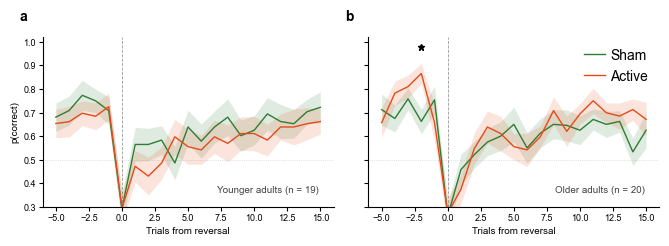

In [55]:
# ============================================================================
# 3.5d — Figure: Reversal-locked accuracy curves, median split (JNeurosci)
# ============================================================================

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
import statsmodels.api as sm

CM_TO_IN = 1 / 2.54
WIDTH_2COL = 17.6 * CM_TO_IN

FONT_FAMILY = 'Arial'
FONT_AXIS_TITLE = 7
FONT_TICK = 6.5
FONT_PANEL_LABEL = 10
FONT_LEGEND = 6
FONT_INSET = 7

SHAM_CURVE = '#2E7D32'   # green (consistent with paired α figure)
ACTIVE_CURVE = '#E64A19'

# ── Compute median split ───────────────────────────────────────────────────
median_age = subj['age'].median()
print(f'Sample median age: {median_age:.1f} years')

subj['age_group_median'] = np.where(subj['age'] < median_age, 'Younger', 'Older')
counts = subj['age_group_median'].value_counts()
print(f'Sample sizes → Younger: n={counts.get("Younger", 0)}, Older: n={counts.get("Older", 0)}')

subj_median_map = subj[['subject_id', 'age_group_median']].astype({'subject_id': str})
rev_median = rev_acc.merge(subj_median_map, on='subject_id', how='left')

# ── Build figure ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(WIDTH_2COL, WIDTH_2COL * 0.35), sharey=True)
plt.subplots_adjust(left=0.08, right=0.97, bottom=0.18, top=0.88, wspace=0.12)

group_order = ['Younger', 'Older']
panel_labels = ['a', 'b']
group_n = {g: counts.get(g, 0) for g in group_order}

for idx, (group_name, panel_label) in enumerate(zip(group_order, panel_labels)):
    ax = axes[idx]
    g_data = rev_median[rev_median['age_group_median'] == group_name]

    # Significance tests per position
    sig_positions = []
    for pos in positions:
        pos_data = (g_data[g_data['trial_from_rev'] == pos]
                    .pivot(index='subject_id', columns='condition', values='p_correct')
                    .dropna())
        if len(pos_data) >= 5:
            t, p = stats.ttest_rel(pos_data['active'], pos_data['sham'])
            if p < .05:
                sig_positions.append(pos)

    # Condition curves with SEM bands
    for cond, color in [('sham', SHAM_CURVE), ('active', ACTIVE_CURVE)]:
        cond_data = (g_data[g_data['condition'] == cond]
                     .groupby('trial_from_rev')['p_correct']
                     .agg(['mean', 'sem'])
                     .reindex(positions))
        ax.plot(cond_data.index, cond_data['mean'], color=color,
                linewidth=1.0, zorder=2)
        ax.fill_between(cond_data.index,
                         cond_data['mean'] - cond_data['sem'],
                         cond_data['mean'] + cond_data['sem'],
                         color=color, alpha=0.15, linewidth=0, zorder=1)

    # Reversal marker and chance line
    ax.axvline(0, color='#999999', linewidth=0.6, linestyle='--', zorder=0)
    ax.axhline(0.5, color='#CCCCCC', linewidth=0.5, linestyle=':', zorder=0)

    # Significance asterisks
    for pos in sig_positions:
        ax.plot(pos, 0.98, '*', color='black', markersize=5, zorder=3)

    # Panel label
    ax.text(-0.08, 1.08, panel_label, transform=ax.transAxes,
            fontsize=FONT_PANEL_LABEL, fontfamily=FONT_FAMILY,
            fontweight='bold', va='bottom', ha='left')

    # Group annotation (inset)
    ax.text(0.95, 0.07, f'{group_name} adults (n = {group_n[group_name]})',
            transform=ax.transAxes, fontsize=FONT_INSET, fontfamily=FONT_FAMILY,
            color='#404040', ha='right', va='bottom')

    # Axis labels
    ax.set_xlabel('Trials from reversal', fontsize=FONT_AXIS_TITLE,
                  fontfamily=FONT_FAMILY, labelpad=3)
    if idx == 0:
        ax.set_ylabel('p(correct)', fontsize=FONT_AXIS_TITLE,
                      fontfamily=FONT_FAMILY, labelpad=3)

    ax.set_ylim(0.3, 1.02)

    # Spines and ticks
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.tick_params(axis='both', which='major', labelsize=FONT_TICK,
                   width=0.8, length=3, pad=2)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FONT_FAMILY)
    ax.set_facecolor('white')

    # Legend (right panel only)
    if idx == 1:
        legend_handles = [
            Line2D([0], [0], color=SHAM_CURVE, linewidth=1.0, label='Sham'),
            Line2D([0], [0], color=ACTIVE_CURVE, linewidth=1.0, label='Active'),
        ]
        ax.legend(handles=legend_handles, fontsize=FONT_LEGEND, loc='upper right',
                  framealpha=0.9, edgecolor='none', prop={'family': FONT_FAMILY},
                  handlelength=1.5, handletextpad=0.4, borderpad=0.3)

fig.savefig(str(FIG_DIR / 'fig_reversal_locked_accuracy_median_split.svg'),
            format='svg', bbox_inches='tight', pad_inches=0.02)
fig.savefig(str(FIG_DIR / 'fig_reversal_locked_accuracy_median_split.png'),
            dpi=600, bbox_inches='tight', pad_inches=0.02)
plt.show()

In [57]:
subject = '10369'      # or whatever subject ID
condition = 'sham'

plot_df = rev_data[
    (rev_data['subject_id'].astype(str) == subject) &
    (rev_data['condition'] == condition)
].copy()

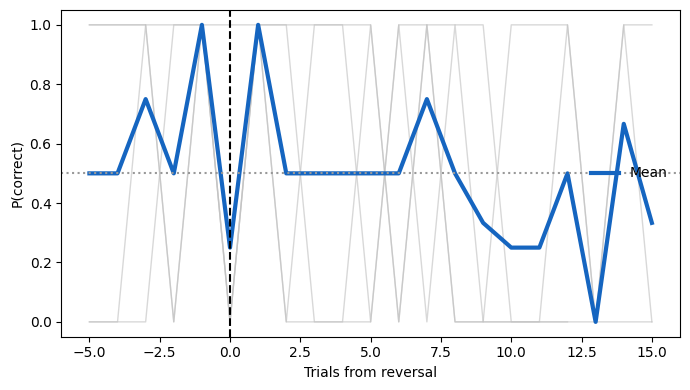

In [59]:
fig, ax = plt.subplots(figsize=(7,4))

# individual reversals
for rev_id, grp in plot_df.groupby('reversal_id'):
    grp = grp.sort_values('trial_from_rev')
    ax.plot(
        grp['trial_from_rev'],
        grp['correct'],
        color='0.75',
        alpha=0.6,
        linewidth=1
    )

# mean across reversals
mean_curve = (
    plot_df.groupby('trial_from_rev')['correct']
           .mean()
)

ax.plot(
    mean_curve.index,
    mean_curve.values,
    color='#1565C0',
    linewidth=3,
    label='Mean'
)

ax.axvline(0, ls='--', color='black')
ax.axhline(0.5, ls=':', color='0.6')

ax.set_xlabel('Trials from reversal')
ax.set_ylabel('P(correct)')
ax.set_ylim(-0.05, 1.05)
ax.legend(frameon=False)

plt.tight_layout()

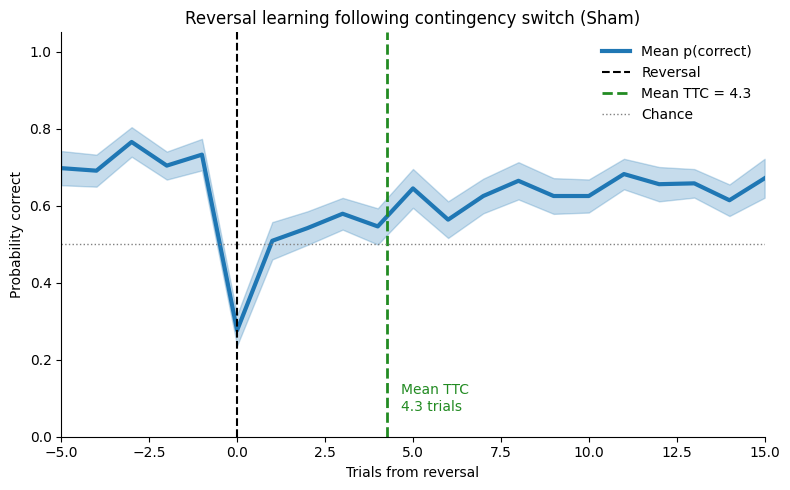

In [63]:
# =============================================================================
# FIGURE: Reversal learning trajectory (Sham condition)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Settings
# -----------------------------------------------------------------------------

CONDITION = 'sham'

# -----------------------------------------------------------------------------
# Build subject-level learning curves
# (Average across reversals within each subject first)
# -----------------------------------------------------------------------------

plot_df = rev_data.query("condition == @CONDITION").copy()

subject_curves = (
    plot_df
    .groupby(['subject_id', 'trial_from_rev'])['correct']
    .mean()
    .reset_index()
)

# -----------------------------------------------------------------------------
# Group mean ± SEM across subjects
# -----------------------------------------------------------------------------

group_curve = (
    subject_curves
    .groupby('trial_from_rev')
    .agg(
        mean_correct=('correct', 'mean'),
        sem=('correct', lambda x: x.std(ddof=1) / np.sqrt(len(x)))
    )
    .reset_index()
)

# Force numeric dtypes (avoids matplotlib fill_between issues)
group_curve['trial_from_rev'] = pd.to_numeric(group_curve['trial_from_rev'])
group_curve['mean_correct'] = pd.to_numeric(group_curve['mean_correct'])
group_curve['sem'] = pd.to_numeric(group_curve['sem'])

# Convert to numpy arrays
x = group_curve['trial_from_rev'].to_numpy(dtype=float)
y = group_curve['mean_correct'].to_numpy(dtype=float)
sem = group_curve['sem'].fillna(0).to_numpy(dtype=float)

# -----------------------------------------------------------------------------
# Mean trials-to-criterion
# (Average subject TTCs, not reversal TTCs)
# -----------------------------------------------------------------------------

ttc_subject = (
    ttc_df
    .query("condition == @CONDITION")
    .groupby('subject_id')['trials_to_criterion']
    .mean()
)

mean_ttc = ttc_subject.mean()

# -----------------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8,5))

# SEM ribbon
ax.fill_between(
    x,
    y - sem,
    y + sem,
    alpha=0.25,
    color='tab:blue'
)

# Mean trajectory
ax.plot(
    x,
    y,
    color='tab:blue',
    linewidth=3,
    label='Mean p(correct)'
)

# Reversal marker
ax.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Reversal'
)

# Mean TTC marker
ax.axvline(
    mean_ttc,
    color='forestgreen',
    linestyle='--',
    linewidth=2,
    label=f'Mean TTC = {mean_ttc:.1f}'
)

# Chance performance
ax.axhline(
    0.5,
    color='gray',
    linestyle=':',
    linewidth=1,
    label='Chance'
)

# TTC annotation
ax.text(
    mean_ttc + 0.4,
    0.06,
    f'Mean TTC\n{mean_ttc:.1f} trials',
    color='forestgreen',
    fontsize=10,
    ha='left',
    va='bottom'
)

# Formatting
ax.set_xlim(np.min(x), np.max(x))
ax.set_ylim(0, 1.05)

ax.set_xlabel('Trials from reversal')
ax.set_ylabel('Probability correct')

ax.set_title('Reversal learning following contingency switch (Sham)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()

# -----------------------------------------------------------------------------
# Save
# -----------------------------------------------------------------------------

plt.savefig('Figure_ReversalLearning_Sham.png', dpi=300, bbox_inches='tight')
plt.savefig('Figure_ReversalLearning_Sham.svg', bbox_inches='tight')

plt.show()

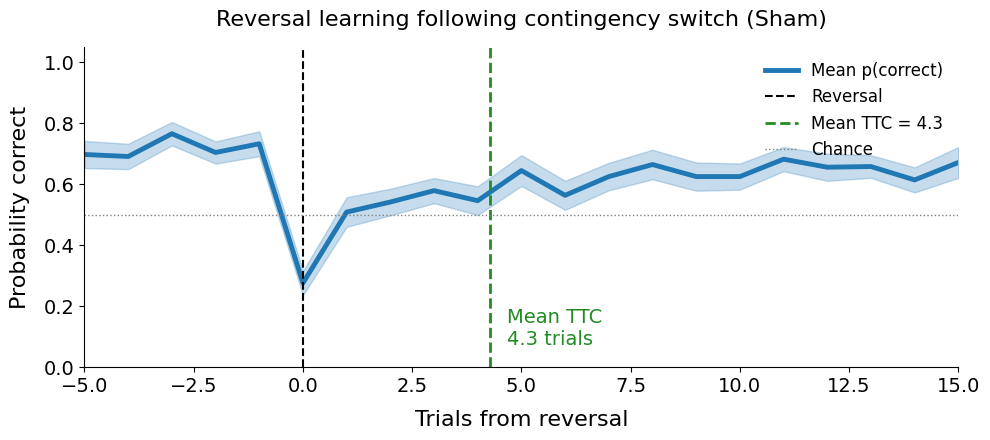

In [65]:
# =============================================================================
# FIGURE: Reversal learning trajectory (Sham condition) - Horizontal & Large Text
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Settings
# -----------------------------------------------------------------------------

CONDITION = 'sham'

# Font size configurations for readability
LABEL_SIZE = 16
TICK_SIZE = 14
TITLE_SIZE = 16
LEGEND_SIZE = 12

# -----------------------------------------------------------------------------
# Build subject-level learning curves
# (Average across reversals within each subject first)
# -----------------------------------------------------------------------------

plot_df = rev_data.query("condition == @CONDITION").copy()

subject_curves = (
    plot_df
    .groupby(['subject_id', 'trial_from_rev'])['correct']
    .mean()
    .reset_index()
)

# -----------------------------------------------------------------------------
# Group mean ± SEM across subjects
# -----------------------------------------------------------------------------

group_curve = (
    subject_curves
    .groupby('trial_from_rev')
    .agg(
        mean_correct=('correct', 'mean'),
        sem=('correct', lambda x: x.std(ddof=1) / np.sqrt(len(x)))
    )
    .reset_index()
)

# Force numeric dtypes (avoids matplotlib fill_between issues)
group_curve['trial_from_rev'] = pd.to_numeric(group_curve['trial_from_rev'])
group_curve['mean_correct'] = pd.to_numeric(group_curve['mean_correct'])
group_curve['sem'] = pd.to_numeric(group_curve['sem'])

# Convert to numpy arrays
x = group_curve['trial_from_rev'].to_numpy(dtype=float)
y = group_curve['mean_correct'].to_numpy(dtype=float)
sem = group_curve['sem'].fillna(0).to_numpy(dtype=float)

# -----------------------------------------------------------------------------
# Mean trials-to-criterion
# (Average subject TTCs, not reversal TTCs)
# -----------------------------------------------------------------------------

ttc_subject = (
    ttc_df
    .query("condition == @CONDITION")
    .groupby('subject_id')['trials_to_criterion']
    .mean()
)

mean_ttc = ttc_subject.mean()

# -----------------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------------

# Changed to a wider 10x4.5 aspect ratio for a more horizontal format
fig, ax = plt.subplots(figsize=(10, 4.5))

# SEM ribbon
ax.fill_between(
    x,
    y - sem,
    y + sem,
    alpha=0.25,
    color='tab:blue'
)

# Mean trajectory
ax.plot(
    x,
    y,
    color='tab:blue',
    linewidth=3.5,  # Slightly thicker line to match larger text
    label='Mean p(correct)'
)

# Reversal marker
ax.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Reversal'
)

# Mean TTC marker
ax.axvline(
    mean_ttc,
    color='forestgreen',
    linestyle='--',
    linewidth=2,
    label=f'Mean TTC = {mean_ttc:.1f}'
)

# Chance performance
ax.axhline(
    0.5,
    color='gray',
    linestyle=':',
    linewidth=1,
    label='Chance'
)

# TTC annotation (Font size increased to match)
ax.text(
    mean_ttc + 0.4,
    0.06,
    f'Mean TTC\n{mean_ttc:.1f} trials',
    color='forestgreen',
    fontsize=LABEL_SIZE - 2,
    ha='left',
    va='bottom'
)

# Formatting
ax.set_xlim(np.min(x), np.max(x))
ax.set_ylim(0, 1.05)

# Scaled up axis labels
ax.set_xlabel('Trials from reversal', fontsize=LABEL_SIZE, labelpad=10)
ax.set_ylabel('Probability correct', fontsize=LABEL_SIZE, labelpad=10)

# Scaled up tick marks
ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE)

# Scaled up title
ax.set_title('Reversal learning following contingency switch (Sham)', fontsize=TITLE_SIZE, pad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Cleaned up legend with increased size
ax.legend(frameon=False, fontsize=LEGEND_SIZE, loc='upper right')

plt.tight_layout()

# -----------------------------------------------------------------------------
# Save
# -----------------------------------------------------------------------------

plt.savefig('Figure_ReversalLearning_Sham.png', dpi=300, bbox_inches='tight')
plt.savefig('Figure_ReversalLearning_Sham.svg', bbox_inches='tight')

plt.show()

---
## 6. H2.1: Stimulation Effects (§3.5)

Paired t-tests with Cohen's dz, TOST equivalence tests at ±0.3 and ±0.5.

In [ ]:
# ============================================================================
# 3.6 H2.1 — Paired comparisons + TOST (Updated with Reversal TTC)
# ============================================================================

# Ensure TTC columns exist in subj dataframe (adjust names if needed)
# If ttc_clean from previous kernels is indexed by subject_id, you can map it:
if 'sham_ttc' not in subj.columns and 'active_ttc' not in subj.columns:
    if 'active' in ttc_clean.columns and 'sham' in ttc_clean.columns:
        subj['sham_ttc'] = subj['subject_id'].astype(str).map(ttc_clean['sham'])
        subj['active_ttc'] = subj['subject_id'].astype(str).map(ttc_clean['active'])

h2_dvs = [
    ('sham_p_stay_win', 'active_p_stay_win', 'p(stay|win)'),
    ('sham_p_shift_lose', 'active_p_shift_lose', 'p(shift|lose)'),
    ('sham_alpha', 'active_alpha', 'Learning Rate (α)'),
    ('sham_beta', 'active_beta', 'Inverse Temperature (β)'),
    ('sham_accuracy', 'active_accuracy', 'Accuracy'),
    ('sham_ttc', 'active_ttc', 'Trials-to-Criterion (TTC)'), # Added Reversal Metric
]

# Add DDM drift rate if available
for col_pattern in ['ddm_v_sham', 'sham_ddm_v']:
    active_pattern = col_pattern.replace('sham', 'active')
    if col_pattern in subj.columns and active_pattern in subj.columns:
        h2_dvs.append((col_pattern, active_pattern, 'Drift Rate (v)'))
        break

h2_results = []

print('H2.1: Paired t-tests (active vs sham)')
print(f'{"DV":28s} {"N":>4s} {"Sham M":>8s} {"Active M":>10s} {"Δ":>8s} {"t":>8s} {"p":>8s} {"dz":>8s}')
print('-' * 90)

for sham_col, active_col, label in h2_dvs:
    if sham_col not in subj.columns or active_col not in subj.columns:
        continue
    df = subj[[sham_col, active_col]].dropna()
    s = df[sham_col].astype(float).values
    a = df[active_col].astype(float).values
    n = len(df)
    if n < 3:
        continue
    
    t_stat, p_val = stats.ttest_rel(a, s)
    diff = a - s
    dz = diff.mean() / diff.std() if diff.std() > 0 else 0
    
    # TOST equivalence test (SESOI: dz = ±0.3)
    sesoi = 0.3 * diff.std()  # convert dz to raw units
    if sesoi > 0:
        t_upper = (diff.mean() - sesoi) / (diff.std() / np.sqrt(n))
        t_lower = (diff.mean() + sesoi) / (diff.std() / np.sqrt(n))
        p_upper = stats.t.cdf(t_upper, n - 1)   # test against upper bound
        p_lower = 1 - stats.t.cdf(t_lower, n - 1)  # test against lower bound
        tost_p = max(p_upper, p_lower)
    else:
        tost_p = np.nan
    
    sig = ' *' if p_val < .05 else ''
    # Format updated to print the sample size per variable explicitly
    print(f'{label:28s} {n:4d} {s.mean():8.3f} {a.mean():10.3f} {diff.mean():+8.4f} '
          f'{t_stat:+8.3f} {p_val:8.3f} {dz:+8.3f}{sig}')
    
    h2_results.append({
        'label': label, 'sham_m': s.mean(), 'active_m': a.mean(),
        'delta': diff.mean(), 't': t_stat, 'p': p_val, 'dz': dz,
        'tost_p': tost_p, 'n': n, 'delta_se': diff.std() / np.sqrt(n),
    })

print(f'\nTOST equivalence tests (SESOI = dz ± 0.3):')
for r in h2_results:
    equiv = 'Equivalent' if r['tost_p'] < .05 else 'Inconclusive'
    print(f'  {r["label"]:28s} (N={r["n"]}): TOST p = {r["tost_p"]:.3f} → {equiv}')

In [ ]:
# ── TOST at literature-informed SESOI (dz = ±0.5) ──
print(f'\nTOST equivalence tests (SESOI = dz ± 0.5, literature-informed):')
for r in h2_results:
    sesoi_05 = 0.5 * (r['delta_se'] * np.sqrt(r['n']))  # 0.5 * SD of diff
    if sesoi_05 > 0:
        diff_mean = r['delta']
        diff_se = r['delta_se']
        t_upper = (diff_mean - sesoi_05) / diff_se
        t_lower = (diff_mean + sesoi_05) / diff_se
        p_upper = stats.t.cdf(t_upper, r['n'] - 1)
        p_lower = 1 - stats.t.cdf(t_lower, r['n'] - 1)
        tost_p_05 = max(p_upper, p_lower)
    else:
        tost_p_05 = np.nan
    equiv = 'Equivalent' if tost_p_05 < .05 else 'Inconclusive'
    r['tost_p_05'] = tost_p_05
    # Label padding updated to match the 28s layout from the main table
    print(f'  {r["label"]:28s} (N={r["n"]}): TOST p = {tost_p_05:.3f} → {equiv}')

In [ ]:
# ============================================================================
# 3.6 H2.1 — Figure: Effect size forest plot (JNeurosci format)
# ============================================================================

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

CM_TO_IN = 1 / 2.54
WIDTH_1COL = 8.5 * CM_TO_IN

FONT_FAMILY = 'Arial'
FONT_AXIS_TITLE = 7
FONT_TICK = 6.5

MARKER_COLOR = '#E64A19'
SESOI_COLOR = '#BDBDBD'

# ── Build figure ───────────────────────────────────────────────────────────
labels = [r['label'] for r in h2_results]
# Sentence case
labels_clean = [l.replace('Accuracy', 'accuracy').replace('Learning Rate', 'learning rate')
                 .replace('Inverse Temperature', 'inverse temperature')
                 .replace('Trials-to-Criterion (TTC)', 'TTC (reversal)')
                 .replace('Drift Rate', 'drift rate')
                 for l in labels]

dzs = [r['dz'] for r in h2_results]
ci_half = [1.96 / np.sqrt(r['n']) for r in h2_results]
n_dvs = len(labels)

row_spacing = 0.6
fig_height = WIDTH_1COL * 0.45 + n_dvs * 0.18
fig, ax = plt.subplots(figsize=(WIDTH_1COL, fig_height))

y_pos = [i * row_spacing for i in range(n_dvs)]

# Zero reference line
ax.axvline(0, color='black', linewidth=0.8, zorder=1)

# SESOI bounds (±0.3)
ax.axvline(0.3, color=SESOI_COLOR, linewidth=0.6, linestyle='--', zorder=0)
ax.axvline(-0.3, color=SESOI_COLOR, linewidth=0.6, linestyle='--', zorder=0)

# Effect sizes with CI
for i, (dz, ci, r) in enumerate(zip(dzs, ci_half, h2_results)):
    y = y_pos[i]
    ax.errorbar(dz, y, xerr=ci, fmt='D', color=MARKER_COLOR,
                markersize=5, markeredgecolor='white', markeredgewidth=0.3,
                elinewidth=0.8, capsize=2.5, capthick=0.8, zorder=3)

    # Significance asterisk
    if r['p'] < .05:
        ax.text(dz, y - 0.18, '*', fontsize=8, fontfamily=FONT_FAMILY,
                ha='center', va='top', color='black', fontweight='bold')

# Y-axis labels
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_clean, fontsize=FONT_TICK, fontfamily=FONT_FAMILY)
ax.invert_yaxis()

# X-axis
ax.set_xlabel("Cohen's $d_z$ (active − sham)", fontsize=FONT_AXIS_TITLE,
              fontfamily=FONT_FAMILY, labelpad=3)
ax.set_xlim(-0.8, 0.8)

# Spines and ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='x', which='major', labelsize=FONT_TICK,
               width=0.8, length=3, pad=2)
ax.tick_params(axis='y', which='both', length=0, pad=4)
for label in ax.get_xticklabels():
    label.set_fontfamily(FONT_FAMILY)
ax.set_facecolor('white')

# Alternating row shading
for i in range(0, n_dvs, 2):
    y_lo = y_pos[i] - 0.28
    y_hi = y_pos[i] + 0.28
    ax.axhspan(y_lo, y_hi, color='#f5f5f5', zorder=0, linewidth=0)

plt.tight_layout(pad=0.3)
fig.savefig(str(FIG_DIR / 'fig_h2_1_forest.svg'),
            format='svg', bbox_inches='tight', pad_inches=0.02)
fig.savefig(str(FIG_DIR / 'fig_h2_1_forest.png'),
            dpi=600, bbox_inches='tight', pad_inches=0.02)
plt.show()

print('H2.1 forest plot stats (for legend text):')
for r, lbl in zip(h2_results, labels_clean):
    sig = '*' if r['p'] < .05 else ''
    print(f'  {lbl}: dz = {r["dz"]:.3f}, p = {r["p"]:.3f}{sig}, N = {r["n"]}')

In [ ]:
# ============================================================================
# 3.6.1 — RT change, order effects, learning slope
# ============================================================================

# ── RT ──
h2_subj = subj[subj['subject_id'].isin(h2_eligible)].copy()

# Compute condition-level mean RT from trial data if not in master CSV
if 'sham_rt' not in h2_subj.columns or 'active_rt' not in h2_subj.columns:
    rt_cond = (trials[trials['condition'].isin(['sham', 'active']) &
                      trials['subject_id'].isin(h2_eligible) &
                      trials['choice'].notna() & trials['rt'].notna()]
               .groupby(['subject_id', 'condition'])['rt'].mean()
               .reset_index()
               .pivot(index='subject_id', columns='condition', values='rt')
               .rename(columns={'sham': 'sham_rt', 'active': 'active_rt'})
               .reset_index())
    rt_cond['subject_id'] = rt_cond['subject_id'].astype(str)
    h2_subj = h2_subj.merge(rt_cond, on='subject_id', how='left')

if 'sham_rt' in h2_subj.columns and 'active_rt' in h2_subj.columns:
    rt_df = h2_subj[['sham_rt', 'active_rt']].dropna()
    s_rt = rt_df['sham_rt'].astype(float).values
    a_rt = rt_df['active_rt'].astype(float).values
    t_rt, p_rt = stats.ttest_rel(a_rt, s_rt)
    d_rt = (a_rt - s_rt)
    dz_rt = d_rt.mean() / d_rt.std() if d_rt.std() > 0 else 0
    unit = 'ms' if s_rt.mean() > 100 else 's'
    print(f'RT: Sham M = {s_rt.mean():.1f}{unit}, Active M = {a_rt.mean():.1f}{unit}')
    print(f'    Δ = {d_rt.mean():+.1f}{unit}, t({len(rt_df)-1}) = {t_rt:.3f}, '
          f'p = {p_rt:.3f}, dz = {dz_rt:.3f}')
    if p_rt > .05:
        print(f'    → No speed-accuracy tradeoff')

# ── Order × Condition (lose-shifting) ──
if 'counterbalance' in h2_subj.columns:
    print(f'\nOrder × Condition (lose-shifting):')
    for sham_c, active_c, label in [('sham_p_shift_lose', 'active_p_shift_lose', 'p(shift|lose)')]:
        if sham_c in h2_subj.columns and active_c in h2_subj.columns:
            odf = h2_subj[[sham_c, active_c, 'counterbalance']].dropna()
            odf['diff'] = odf[active_c].astype(float) - odf[sham_c].astype(float)
            for order in sorted(odf['counterbalance'].unique()):
                grp = odf[odf['counterbalance'] == order]['diff']
                print(f'  Order {order}: Δ = {grp.mean():+.4f}, n = {len(grp)}')
            order_a = odf[odf['counterbalance'] == odf['counterbalance'].unique()[0]]['diff']
            order_b = odf[odf['counterbalance'] == odf['counterbalance'].unique()[1]]['diff']
            t_ord, p_ord = stats.ttest_ind(order_a, order_b)
            print(f'  Interaction: t = {t_ord:.3f}, p = {p_ord:.3f}')


---
## 7. H2.2: Age Moderation of Stimulation (§3.6)

In [ ]:
# ============================================================================
# 3.7 H2.2 — Preregistered: Age moderation of tACS change scores
# ============================================================================

# Compute change scores if not present
for sham_c, active_c, delta_c in [
    ('sham_p_stay_win', 'active_p_stay_win', 'delta_p_stay_win'),
    ('sham_p_shift_lose', 'active_p_shift_lose', 'delta_p_shift_lose'),
    ('sham_alpha', 'active_alpha', 'delta_alpha'),
    ('sham_beta', 'active_beta', 'delta_beta'),
    ('sham_accuracy', 'active_accuracy', 'delta_accuracy'),
]:
    if sham_c in subj.columns and active_c in subj.columns and delta_c not in subj.columns:
        subj[delta_c] = subj[active_c].astype(float) - subj[sham_c].astype(float)

h2_2_dvs = [
    ('delta_p_stay_win', 'Δ p(stay|win)'),
    ('delta_p_shift_lose', 'Δ p(shift|lose)'),
    ('delta_alpha', 'Δ α'),
    ('delta_beta', 'Δ β'),
]

print('H2.2 Preregistered: Δ DV ~ age + global_composite')
print('=' * 70)

h2_2_results = {}
for delta_col, label in h2_2_dvs:
    if delta_col not in subj.columns:
        continue
    cols = [delta_col, 'age', COG_COMPOSITE]
    df = subj[['subject_id'] + cols].dropna()
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna()
    if len(df) < 6:
        continue
    
    y = df[delta_col]
    X = sm.add_constant(df[['age', COG_COMPOSITE]])
    model = sm.OLS(y, X).fit()
    
    age_p = model.pvalues['age']
    sig = ' *' if age_p < .05 else ''
    print(f'\n{label}:')
    print(f'  F({model.df_model:.0f}, {model.df_resid:.0f}) = {model.fvalue:.2f}, '
          f'p = {model.f_pvalue:.3f}, R² = {model.rsquared:.3f}')
    print(f'  age: b = {model.params["age"]:+.4f}, p = {age_p:.3f}{sig}')
    
    h2_2_results[delta_col] = model

# ── Key result: age × Δ accuracy ──
print(f'\n{"=" * 70}')
print('Key result: Age × Δ Accuracy')

# Bivariate
df_acc = subj[['age', 'delta_accuracy']].dropna()
df_acc['age'] = pd.to_numeric(df_acc['age'], errors='coerce')
df_acc['delta_accuracy'] = pd.to_numeric(df_acc['delta_accuracy'], errors='coerce')
df_acc = df_acc.dropna()
r_biv, p_biv = stats.pearsonr(df_acc['age'].values, df_acc['delta_accuracy'].values)
print(f'  Bivariate: r = {r_biv:.3f}, p = {p_biv:.3f}, N = {len(df_acc)}')

# OLS with cognition covariate
df_ols = subj[['delta_accuracy', 'age', COG_COMPOSITE]].dropna()
for c in df_ols.columns:
    df_ols[c] = pd.to_numeric(df_ols[c], errors='coerce')
df_ols = df_ols.dropna()
y = df_ols['delta_accuracy']
X = sm.add_constant(df_ols[['age', COG_COMPOSITE]])
m = sm.OLS(y, X).fit()
print(f'  OLS (age + cog): age b = {m.params["age"]:+.4f}, p = {m.pvalues["age"]:.3f}')
print(f'  → Bivariate nominally significant; does not survive covariate control')


In [ ]:
# ============================================================================
# 3.7 H2.2 — Figure: Age × Δ Accuracy (JNeurosci format)
# ============================================================================

import matplotlib.pyplot as plt
from scipy import stats

CM_TO_IN = 1 / 2.54
WIDTH_1COL = 8.5 * CM_TO_IN

FONT_FAMILY = 'Arial'
FONT_AXIS_TITLE = 7
FONT_TICK = 6.5

REGRESSION_COLOR = '#404040'
CI_COLOR = 'gray'
CI_ALPHA = 0.15

df_plot = subj[['age', 'delta_accuracy']].dropna()
df_plot['age'] = pd.to_numeric(df_plot['age'], errors='coerce')
df_plot['delta_accuracy'] = pd.to_numeric(df_plot['delta_accuracy'], errors='coerce')
df_plot = df_plot.dropna()

x = df_plot['age'].values
y = df_plot['delta_accuracy'].values
n = len(x)

fig, ax = plt.subplots(figsize=(WIDTH_1COL, WIDTH_1COL * 0.85))

# Individual points colored by age
for xi, yi in zip(x, y):
    norm_val = np.clip((xi - AGE_MIN) / (AGE_MAX - AGE_MIN), 0, 1)
    r_c, g_c, b_c, _ = AGE_CMAP(norm_val)
    color = f'#{int(r_c*255):02x}{int(g_c*255):02x}{int(b_c*255):02x}'
    ax.plot(xi, yi, 'o', color=color, markersize=4.5,
            markeredgecolor='white', markeredgewidth=0.3,
            alpha=0.85, zorder=3)

# OLS regression + 95% CI
slope, intercept, r, p, se = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = intercept + slope * x_line

y_pred = intercept + slope * x
resid_se = np.sqrt(np.sum((y - y_pred)**2) / (n - 2))
ss_x = np.sum((x - x.mean())**2)
ci = stats.t.ppf(0.975, n - 2) * resid_se * np.sqrt(1/n + (x_line - x.mean())**2 / ss_x)

ax.fill_between(x_line, y_line - ci, y_line + ci,
                 color=CI_COLOR, alpha=CI_ALPHA, zorder=1, linewidth=0)
ax.plot(x_line, y_line, color=REGRESSION_COLOR, linewidth=1.2, zorder=2)

# Zero reference line
ax.axhline(0, color='#BDBDBD', linewidth=0.8, linestyle='--', zorder=1)

# Labels
ax.set_xlabel('Age (years)', fontsize=FONT_AXIS_TITLE,
              fontfamily=FONT_FAMILY, labelpad=3)
ax.set_ylabel('Δ accuracy (active − sham)', fontsize=FONT_AXIS_TITLE,
              fontfamily=FONT_FAMILY, labelpad=3)

# Spines and ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='both', which='major', labelsize=FONT_TICK,
               width=0.8, length=3, pad=2)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FONT_FAMILY)
ax.set_facecolor('white')

plt.tight_layout(pad=0.3)
fig.savefig(str(FIG_DIR / 'fig_h2_2_age_delta_accuracy.svg'),
            format='svg', bbox_inches='tight', pad_inches=0.02)
fig.savefig(str(FIG_DIR / 'fig_h2_2_age_delta_accuracy.png'),
            dpi=600, bbox_inches='tight', pad_inches=0.02)
plt.show()

print('Figure stats (for legend text):')
print(f'  Age × Δ accuracy: r = {r:.3f}, p = {p:.3f}, N = {n}')

---
## 8. H2.2 Exploratory: Subgroup Decomposition (§3.6.1)

Bidirectional subgroup pattern, younger-adult Δα, phase decomposition, baseline rigidity.

In [ ]:
# ============================================================================
# 3.7.1a — Figure: Subgroup forest plot (JNeurosci format)
# ============================================================================

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
import statsmodels.api as sm

CM_TO_IN = 1 / 2.54
WIDTH_1COL = 8.5 * CM_TO_IN

FONT_FAMILY = 'Arial'
FONT_AXIS_TITLE = 7
FONT_TICK = 6.5
FONT_LEGEND = 6

# ── Compute subgroup effect sizes ──────────────────────────────────────────
if 'sham_ttc' not in subj.columns and 'active_ttc' not in subj.columns:
    if 'active' in ttc_median.columns and 'sham' in ttc_median.columns:
        subj['sham_ttc'] = subj['subject_id'].astype(str).map(ttc_median['sham'])
        subj['active_ttc'] = subj['subject_id'].astype(str).map(ttc_median['active'])

h2_subj = subj[subj['subject_id'].isin(h2_eligible)].copy()
h2_subj['age'] = pd.to_numeric(h2_subj['age'], errors='coerce')

median_age = h2_subj['age'].median()
h2_subj['age_group'] = np.where(h2_subj['age'] >= median_age, 'Older', 'Younger')
group_ns = h2_subj.groupby('age_group')['subject_id'].nunique().to_dict()

dv_pairs = [
    ('sham_p_stay_win', 'active_p_stay_win', 'Δ p(stay|win)'),
    ('sham_p_shift_lose', 'active_p_shift_lose', 'Δ p(shift|lose)'),
    ('sham_alpha', 'active_alpha', 'Δ α'),
    ('sham_beta', 'active_beta', 'Δ β'),
    ('sham_accuracy', 'active_accuracy', 'Δ accuracy'),
    ('sham_ttc', 'active_ttc', 'Δ TTC (reversal)'),
]

sg_data = []
for sham_c, active_c, label in dv_pairs:
    if sham_c not in h2_subj.columns or active_c not in h2_subj.columns:
        continue
    for group in ['Younger', 'Older']:
        grp = h2_subj[h2_subj['age_group'] == group][[sham_c, active_c]].dropna()
        n = len(grp)
        if n < 3:
            continue
        s = grp[sham_c].astype(float).values
        a = grp[active_c].astype(float).values
        diff = a - s
        t, p = stats.ttest_rel(a, s)
        dz = diff.mean() / diff.std() if diff.std() > 0 else 0
        ci = 1.96 / np.sqrt(n)
        sg_data.append({'label': label, 'group': group, 'dz': dz, 'ci': ci, 'p': p, 'n': n})

sg_df = pd.DataFrame(sg_data)
labels_unique = list(dict.fromkeys(sg_df['label']))

# ── Build figure ───────────────────────────────────────────────────────────
n_dvs = len(labels_unique)
fig_height = WIDTH_1COL * 0.55 + n_dvs * 0.18
fig, ax = plt.subplots(figsize=(WIDTH_1COL, fig_height))

row_spacing = 0.6
subgroup_offset = 0.12

y_positions = {}
for i, label in enumerate(labels_unique):
    y_center = i * row_spacing
    y_positions[(label, 'Younger')] = y_center - subgroup_offset
    y_positions[(label, 'Older')] = y_center + subgroup_offset

group_style = {
    'Younger': {'color': SHAM_COLOR, 'marker': 'o', 'size': 5},
    'Older':   {'color': AGE_OLD,    'marker': 'D', 'size': 4.5},
}

# Zero reference line
ax.axvline(0, color='black', linewidth=0.8, zorder=1)

# Plot each point with error bar
for group in ['Younger', 'Older']:
    grp = sg_df[sg_df['group'] == group]
    if len(grp) == 0:
        continue
    style = group_style[group]
    for _, r in grp.iterrows():
        y_val = y_positions[(r['label'], group)]
        ax.errorbar(r['dz'], y_val, xerr=r['ci'],
                    fmt=style['marker'], color=style['color'],
                    markersize=style['size'], markeredgecolor='white',
                    markeredgewidth=0.3, elinewidth=0.8, capsize=2.5,
                    capthick=0.8, zorder=3)
        if r['p'] < .05:
            ax.text(r['dz'], y_val - 0.18, '*', fontsize=8,
                    fontfamily=FONT_FAMILY, ha='center', va='top',
                    color='black', fontweight='bold')

# Y-axis: DV labels at row centers
tick_y = [i * row_spacing for i in range(n_dvs)]
ax.set_yticks(tick_y)
ax.set_yticklabels(labels_unique, fontsize=FONT_TICK, fontfamily=FONT_FAMILY)
ax.invert_yaxis()

# X-axis
ax.set_xlabel("Cohen's $d_z$ (active − sham)", fontsize=FONT_AXIS_TITLE,
              fontfamily=FONT_FAMILY, labelpad=3)
ax.set_xlim(-1.0, 1.0)

# Spines and ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='x', which='major', labelsize=FONT_TICK,
               width=0.8, length=3, pad=2)
ax.tick_params(axis='y', which='both', length=0, pad=4)
for label in ax.get_xticklabels():
    label.set_fontfamily(FONT_FAMILY)
ax.set_facecolor('white')

# Alternating row shading
for i in range(0, n_dvs, 2):
    y_lo = i * row_spacing - 0.28
    y_hi = i * row_spacing + 0.28
    ax.axhspan(y_lo, y_hi, color='#f5f5f5', zorder=0, linewidth=0)

# No legend
#legend_handles = [
#    Line2D([0], [0], marker='o', color='w', markerfacecolor=SHAM_COLOR,
#           markersize=4.5, markeredgecolor='white', markeredgewidth=0.3,
#           label=f'Younger (n = {group_ns.get("Younger", 0)})'),
#    Line2D([0], [0], marker='D', color='w', markerfacecolor=AGE_OLD,
#           markersize=4, markeredgecolor='white', markeredgewidth=0.3,
#           label=f'Older (n = {group_ns.get("Older", 0)})'),
#]
#ax.legend(handles=legend_handles, fontsize=FONT_LEGEND, loc='lower right',
#          framealpha=0.9, edgecolor='none', prop={'family': FONT_FAMILY},
#          handletextpad=0.4, borderpad=0.3)

plt.tight_layout(pad=0.3)
fig.savefig(str(FIG_DIR / 'fig_h2_2_subgroup_forest.svg'),
            format='svg', bbox_inches='tight', pad_inches=0.02)
fig.savefig(str(FIG_DIR / 'fig_h2_2_subgroup_forest.png'),
            dpi=600, bbox_inches='tight', pad_inches=0.02)
plt.show()

print('Subgroup forest plot stats (for legend text):')
print(f'  Median split age: {median_age:.1f} years')
for _, r in sg_df.iterrows():
    sig = '*' if r['p'] < .05 else ''
    print(f'  {r["label"]} ({r["group"]}, n={r["n"]}): dz = {r["dz"]:.3f}, p = {r["p"]:.3f}{sig}')

In [ ]:
# ============================================================================
# 3.7.1b — Figure: Younger adults α by condition (JNeurosci format)
# ============================================================================

import matplotlib.pyplot as plt
from scipy import stats

CM_TO_IN = 1 / 2.54
WIDTH_1COL = 8.5 * CM_TO_IN

FONT_FAMILY = 'Arial'
FONT_AXIS_TITLE = 7
FONT_TICK = 6.5
SHAM_COLOR_ALT = '#2E7D32'

younger = h2_subj[h2_subj['age_group'] == 'Younger'].copy()

if 'sham_alpha' in younger.columns and 'active_alpha' in younger.columns:
    ya = younger[['subject_id', 'sham_alpha', 'active_alpha', 'age',
                   'sham_accuracy', 'active_accuracy']].dropna()
    for c in ['sham_alpha', 'active_alpha', 'age', 'sham_accuracy', 'active_accuracy']:
        ya[c] = pd.to_numeric(ya[c], errors='coerce')
    ya = ya.dropna()

    ya['delta_alpha'] = ya['active_alpha'] - ya['sham_alpha']
    ya['delta_accuracy'] = ya['active_accuracy'] - ya['sham_accuracy']

    # Stats
    t, p = stats.ttest_rel(ya['active_alpha'].values, ya['sham_alpha'].values)
    dz = ya['delta_alpha'].mean() / ya['delta_alpha'].std()
    print('Younger adults: tACS effect on learning rate (NO EXCLUSIONS)')
    print(f'  N = {len(ya)}')
    print(f'  Sham α: M = {ya["sham_alpha"].mean():.3f}')
    print(f'  Active α: M = {ya["active_alpha"].mean():.3f}')
    print(f'  t({len(ya)-1}) = {t:.3f}, p = {p:.3f}, dz = {dz:.3f}')
    
    # Boundary-hit summary
    n_boundary = ((ya['sham_alpha'] <= 0.005) | (ya['sham_alpha'] >= 0.995) |
                  (ya['active_alpha'] <= 0.005) | (ya['active_alpha'] >= 0.995)).sum()
    print(f'  Boundary hits (α ≤ .005 or ≥ .995): {n_boundary}/{len(ya)}')

    if len(ya) >= 5:
        r_mech, p_mech = stats.pearsonr(ya['delta_alpha'].values, ya['delta_accuracy'].values)
        print(f'\n  Δα × Δ accuracy (younger only): r = {r_mech:.3f}, p = {p_mech:.3f}')

    # ── Build figure ───────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(WIDTH_1COL * 0.55, WIDTH_1COL * 0.85))

    for _, row in ya.iterrows():
        ax.plot([0, 1], [row['sham_alpha'], row['active_alpha']],
                color='#999999', linewidth=0.6, alpha=0.4, zorder=1)
        ax.plot(0, row['sham_alpha'], 'o', color=SHAM_COLOR_ALT, markersize=3.5,
                markeredgecolor='white', markeredgewidth=0.2, alpha=0.7, zorder=2)
        ax.plot(1, row['active_alpha'], 'o', color=ACTIVE_COLOR, markersize=3.5,
                markeredgecolor='white', markeredgewidth=0.2, alpha=0.7, zorder=2)

    for x_pos, cond, color in [(0, 'sham_alpha', SHAM_COLOR_ALT),
                                (1, 'active_alpha', ACTIVE_COLOR)]:
        m = ya[cond].mean()
        se = ya[cond].std() / np.sqrt(len(ya))
        ax.errorbar(x_pos, m, yerr=se, fmt='D', color=color,
                    markersize=7, markeredgecolor='white', markeredgewidth=0.8,
                    elinewidth=1.2, capsize=4, capthick=1.2, zorder=4)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Sham', 'Active'], fontsize=FONT_AXIS_TITLE,
                        fontfamily=FONT_FAMILY)
    ax.set_xlim(-0.4, 1.4)
    ax.set_ylabel('Learning rate (α)', fontsize=FONT_AXIS_TITLE,
                  fontfamily=FONT_FAMILY, labelpad=3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.tick_params(axis='both', which='major', labelsize=FONT_TICK,
                   width=0.8, length=3, pad=2)
    ax.tick_params(axis='x', length=0)
    for label in ax.get_yticklabels():
        label.set_fontfamily(FONT_FAMILY)
    ax.set_facecolor('white')

    plt.tight_layout(pad=0.3)
    fig.savefig(str(FIG_DIR / 'fig_h2_2_younger_alpha.svg'),
                format='svg', bbox_inches='tight', pad_inches=0.02)
    fig.savefig(str(FIG_DIR / 'fig_h2_2_younger_alpha.png'),
                dpi=600, bbox_inches='tight', pad_inches=0.02)
    plt.show()

    print('\nFigure stats (for manuscript):')
    print(f'  t({len(ya)-1}) = {t:.3f}, p = {p:.3f}, dz = {dz:.3f}, N = {len(ya)}')

In [ ]:
# ============================================================================
# 3.7.1c — Baseline rigidity as moderator (preregistered secondary)
# ============================================================================

print('Baseline WSLS rigidity as moderator of tACS effects (preregistered secondary)')
print('=' * 70)

rigidity_tests = [
    ('sham_p_stay_win', 'delta_p_stay_win', 'Sham p(stay|win) → Δ p(stay|win)'),
    ('sham_p_stay_win', 'delta_alpha', 'Sham p(stay|win) → Δ α'),
    ('sham_p_stay_win', 'delta_accuracy', 'Sham p(stay|win) → Δ Accuracy'),
    ('sham_p_shift_lose', 'delta_p_shift_lose', 'Sham p(shift|lose) → Δ p(shift|lose)'),
    ('sham_p_shift_lose', 'delta_accuracy', 'Sham p(shift|lose) → Δ Accuracy'),
]

for pred_col, target_col, label in rigidity_tests:
    if pred_col not in subj.columns or target_col not in subj.columns:
        continue
    df = subj[[pred_col, target_col]].dropna()
    x = pd.to_numeric(df[pred_col], errors='coerce').values
    y = pd.to_numeric(df[target_col], errors='coerce').values
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 5:
        continue
    r, p = stats.pearsonr(x[mask], y[mask])
    sig = ' *' if p < .05 else ''
    print(f'  {label}: r = {r:+.3f}, p = {p:.3f}, N = {mask.sum()}{sig}')


In [ ]:
# ============================================================================
# 3.3.1b supplement — Strategic interpretation of reduced lose-shifting
#                      in high-cognition younger adults
# ============================================================================
# Context: The J-N analysis (Section 3.3.1b) found that below ~age 29,
# higher cognition predicts LESS lose-shifting. This could reflect:
#   (a) Strategic behavior: high-cog young adults recognize that shifting
#       after every loss is suboptimal in a 75/25 task, so they stay more
#   (b) Maladaptive perseveration: they're rigidly sticking regardless
#
# To distinguish: within the younger subgroup, check whether less
# lose-shifting is associated with BETTER performance (strategic) or
# WORSE performance (perseverative). Also test whether cognition's
# relationship with accuracy is mediated through the lose-shift pathway
# via partial correlation.

import statsmodels.api as sm_ols

print('=' * 70)
print('Strategic vs. perseverative interpretation:')
print('Younger subgroup (below J-N threshold, age < 29)')
print('=' * 70)

# ── Define younger subgroup ──
jn_threshold = 29  # from J-N analysis
younger = subj[pd.to_numeric(subj['age'], errors='coerce') < jn_threshold].copy()

# Ensure numeric
for c in ['sham_p_shift_lose', 'sham_accuracy', 'sham_win_rate',
          COG_COMPOSITE, 'age']:
    if c in younger.columns:
        younger[c] = pd.to_numeric(younger[c], errors='coerce')

younger_clean = younger[['subject_id', 'sham_p_shift_lose', 'sham_accuracy',
                          'sham_win_rate', COG_COMPOSITE, 'age']].dropna()

n_young = len(younger_clean)
print(f'\nN = {n_young} (age < {jn_threshold})')

if n_young >= 5:
    ls = younger_clean['sham_p_shift_lose'].values
    acc = younger_clean['sham_accuracy'].values
    wr = younger_clean['sham_win_rate'].values
    cog = younger_clean[COG_COMPOSITE].values

    # ── 1. Lose-shifting × accuracy ──
    r_ls_acc, p_ls_acc = stats.pearsonr(ls, acc)
    print(f'\n1. Lose-shifting × accuracy:')
    print(f'   r = {r_ls_acc:+.3f}, p = {p_ls_acc:.3f}')
    if r_ls_acc > 0:
        print(f'   → More lose-shifting associated with HIGHER accuracy (shifting helps)')
    else:
        print(f'   → Less lose-shifting associated with HIGHER accuracy (consistent with strategic staying)')

    # ── 2. Lose-shifting × win rate ──
    r_ls_wr, p_ls_wr = stats.pearsonr(ls, wr)
    print(f'\n2. Lose-shifting × win rate:')
    print(f'   r = {r_ls_wr:+.3f}, p = {p_ls_wr:.3f}')

    # ── 3. Cognition × accuracy (zero-order) ──
    r_cog_acc, p_cog_acc = stats.pearsonr(cog, acc)
    print(f'\n3. Cognition × accuracy (zero-order):')
    print(f'   r = {r_cog_acc:+.3f}, p = {p_cog_acc:.3f}')

    # ── 4. Cognition × accuracy, controlling for lose-shifting (partial r) ──
    # Partial correlation: residualize both cognition and accuracy on lose-shifting
    cog_resid = sm_ols.OLS(cog, sm_ols.add_constant(ls)).fit().resid
    acc_resid = sm_ols.OLS(acc, sm_ols.add_constant(ls)).fit().resid
    r_partial, p_partial = stats.pearsonr(cog_resid, acc_resid)
    print(f'\n4. Cognition × accuracy, controlling for p(shift|lose) (partial r):')
    print(f'   r = {r_partial:+.3f}, p = {p_partial:.3f}')

    # ── Interpretation ──
    print(f'\n{"─" * 70}')
    print('Interpretation:')
    if r_ls_acc < 0:
        print(f'  Less lose-shifting is directionally associated with higher accuracy')
        print(f'  (r = {r_ls_acc:+.3f}), consistent with strategic probability-matching.')
    else:
        print(f'  More lose-shifting is associated with higher accuracy')
        print(f'  (r = {r_ls_acc:+.3f}), inconsistent with strategic interpretation.')

    if abs(r_partial) < 0.10:
        print(f'  Partial r between cognition and accuracy controlling for lose-shifting')
        print(f'  is near zero ({r_partial:+.3f}), suggesting cognition\'s influence on')
        print(f'  performance in young adults operates primarily through the lose-shift pathway.')
    else:
        print(f'  Partial r between cognition and accuracy controlling for lose-shifting')
        print(f'  is {r_partial:+.3f} (p = {p_partial:.3f}), suggesting cognition has')
        print(f'  additional pathways to performance beyond lose-shifting.')

    print(f'\n  Note: N = {n_young}; these within-subgroup associations should be')
    print(f'  interpreted cautiously given the small sample.')

else:
    print(f'\n  Insufficient subjects below J-N threshold for within-group analysis.')

---
## 9. Physiological Measures (§3.7)

θ_p95 as predictor, θ × Cognition interaction, e-field modeling.

In [ ]:
# Ensure TTC columns exist in subj
if 'delta_ttc' not in subj.columns:
    if 'ttc_clean' in dir() and 'sham' in ttc_clean.columns:
        subj['sham_ttc'] = subj['subject_id'].astype(str).map(ttc_clean['sham'])
        subj['active_ttc'] = subj['subject_id'].astype(str).map(ttc_clean['active'])
        subj['delta_ttc'] = subj['active_ttc'] - subj['sham_ttc']
        print(f'Mapped TTC to subj: {subj["delta_ttc"].notna().sum()} subjects')
    else:
        print('WARNING: ttc_clean not found — run the reversal analysis cell first')

In [ ]:
print('delta_ttc' in subj.columns)
print(subj[['sham_ttc', 'active_ttc', 'delta_ttc']].notna().sum())

In [ ]:
# ============================================================================
# 9.1 — Figure: θ_p95 × Δ TTC (JNeurosci format)
# ============================================================================

fig, ax = plt.subplots(figsize=(WIDTH_1COL, WIDTH_1COL * 0.85))

df = subj[['theta_p95', 'delta_ttc', 'age']].dropna()
x = df['theta_p95'].astype(float).values
y = df['delta_ttc'].astype(float).values
age = df['age'].astype(float).values

result = scatter_regression_mpl(ax, x, y, age, zero_line=True)
style_ax(ax, xlabel='Baseline Endogenous Theta Power (p95)',
         ylabel='Δ Trials-to-Criterion (Active − Sham)')

plt.tight_layout(pad=0.5)
plt.savefig(str(FIG_DIR / 'fig_theta_x_delta_ttc.png'), dpi=300, bbox_inches='tight')
plt.savefig(str(FIG_DIR / 'fig_theta_x_delta_ttc.svg'), format='svg', bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================================
# 3.10.2 — Figure: J-N plot, Cognition × Theta on Δ TTC (JNeurosci)
# ============================================================================

import matplotlib.pyplot as plt
from scipy.stats import t as t_dist
import statsmodels.api as sm

CM_TO_IN = 1 / 2.54
WIDTH_1COL = 8.5 * CM_TO_IN

FONT_FAMILY = 'Arial'
FONT_AXIS_TITLE = 7
FONT_TICK = 6.5
FONT_JN_LABEL = 6

SIG_COLOR = '#2E7D32'
ZERO_COLOR = '#C62828'
JN_COLOR = '#C62828'

# ── Prepare data ───────────────────────────────────────────────────────────
cols_cog = ['delta_ttc', 'theta_p95', COG_COMPOSITE, 'age']
df_jn_cog = subj[['subject_id'] + cols_cog].dropna().copy()
for c in cols_cog:
    df_jn_cog[c] = pd.to_numeric(df_jn_cog[c], errors='coerce')
df_jn_cog = df_jn_cog.dropna()

theta_mean_c = df_jn_cog['theta_p95'].mean()
cog_mean_c = df_jn_cog[COG_COMPOSITE].mean()
df_jn_cog['theta_c'] = df_jn_cog['theta_p95'] - theta_mean_c
df_jn_cog['cog_c'] = df_jn_cog[COG_COMPOSITE] - cog_mean_c
df_jn_cog['theta_x_cog'] = df_jn_cog['theta_c'] * df_jn_cog['cog_c']

y_cog = df_jn_cog['delta_ttc'].astype(float)
X_cog = sm.add_constant(df_jn_cog[['theta_c', 'cog_c', 'theta_x_cog']].astype(float))
model_cog = sm.OLS(y_cog, X_cog).fit()

b_theta_g = model_cog.params['theta_c']
b_int_g = model_cog.params['theta_x_cog']
vcov_g = model_cog.cov_params()
var_theta_g = vcov_g.loc['theta_c', 'theta_c']
var_int_g = vcov_g.loc['theta_x_cog', 'theta_x_cog']
cov_theta_int_g = vcov_g.loc['theta_c', 'theta_x_cog']
df_resid_g = model_cog.df_resid

# ── Conditional effect across cognition range ──────────────────────────────
cog_min, cog_max = df_jn_cog[COG_COMPOSITE].min(), df_jn_cog[COG_COMPOSITE].max()
cog_pad = 0.05 * (cog_max - cog_min)
cog_range = np.linspace(cog_min - cog_pad, cog_max + cog_pad, 300)
cog_range_c = cog_range - cog_mean_c

cond_slope_g = b_theta_g + b_int_g * cog_range_c
cond_se_g = np.sqrt(var_theta_g + 2 * cog_range_c * cov_theta_int_g + cog_range_c**2 * var_int_g)

t_vals_g = cond_slope_g / cond_se_g
p_vals_g = 2 * (1 - t_dist.cdf(np.abs(t_vals_g), df_resid_g))
t_crit_g = t_dist.ppf(0.975, df_resid_g)
upper_g = cond_slope_g + t_crit_g * cond_se_g
lower_g = cond_slope_g - t_crit_g * cond_se_g

# ── J-N thresholds ─────────────────────────────────────────────────────────
sig_mask_g = p_vals_g < 0.05
jn_points_g = []
for i in range(len(sig_mask_g) - 1):
    if sig_mask_g[i] != sig_mask_g[i + 1]:
        frac = abs(p_vals_g[i] - 0.05) / (abs(p_vals_g[i] - 0.05) + abs(p_vals_g[i + 1] - 0.05))
        jn_points_g.append(round(cog_range[i] + frac * (cog_range[i + 1] - cog_range[i]), 2))

# ── ΔR² ────────────────────────────────────────────────────────────────────
X_no_int_g = sm.add_constant(df_jn_cog[['theta_c', 'cog_c']].astype(float))
model_no_int_g = sm.OLS(y_cog, X_no_int_g).fit()
delta_r2_g = model_cog.rsquared - model_no_int_g.rsquared

# Print results
print(f'Theta × Cognition interaction (N = {int(model_cog.nobs)}):')
print(f'  b = {b_int_g:.4f}, p = {model_cog.pvalues["theta_x_cog"]:.3f}')
print(f'  ΔR² = {delta_r2_g:.3f}, full model R² = {model_cog.rsquared:.3f}')
print(f'  J-N threshold(s): {jn_points_g}')
sig_cog = cog_range[sig_mask_g]
if len(sig_cog) > 0:
    print(f'  Region of significance: cognition {sig_cog.min():.2f} – {sig_cog.max():.2f}')

# ── Build figure ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(WIDTH_1COL, WIDTH_1COL * 0.85))

# CI band
ax.fill_between(cog_range, lower_g, upper_g, color='gray', alpha=0.20,
                linewidth=0)

# Significant region
ax.fill_between(cog_range, lower_g, upper_g, where=sig_mask_g,
                color=SIG_COLOR, alpha=0.15, linewidth=0)

# Conditional slope
ax.plot(cog_range, cond_slope_g, color='black', linewidth=1.2)

# Zero reference
ax.axhline(0, color=ZERO_COLOR, linestyle='--', linewidth=0.8)

# J-N thresholds
for idx, jn_val in enumerate(jn_points_g):
    ax.axvline(jn_val, color=JN_COLOR, linestyle=':', linewidth=0.8)
    y_pos = max(upper_g) * 0.80
    ax.annotate(f'J-N = {jn_val:.2f}',
                xy=(jn_val, y_pos),
                xytext=(jn_val + 0.1, y_pos),
                fontsize=FONT_JN_LABEL, color=JN_COLOR, fontfamily=FONT_FAMILY,
                arrowprops=dict(arrowstyle='->', color=JN_COLOR, lw=0.6))

# Age rug
rug_y = min(lower_g) * 1.12
for age_val, cog_val in zip(df_jn_cog['age'].values, df_jn_cog[COG_COMPOSITE].values):
    ax.plot(cog_val, rug_y, '|', color=age_to_hex(age_val),
            markersize=4, markeredgewidth=1.0)

# Labels
ax.set_xlabel('Global cognitive composite', fontsize=FONT_AXIS_TITLE,
              fontfamily=FONT_FAMILY, labelpad=3)
ax.set_ylabel('Conditional effect of\ntheta power on Δ TTC', fontsize=FONT_AXIS_TITLE,
              fontfamily=FONT_FAMILY, labelpad=3)

# Spines and ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='both', which='major', labelsize=FONT_TICK,
               width=0.8, length=3, pad=2)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FONT_FAMILY)
ax.set_facecolor('white')

plt.tight_layout(pad=0.3)
fig.savefig(str(FIG_DIR / 'fig_jn_theta_x_cognition.svg'),
            format='svg', bbox_inches='tight', pad_inches=0.02)
fig.savefig(str(FIG_DIR / 'fig_jn_theta_x_cognition.png'),
            dpi=600, bbox_inches='tight', pad_inches=0.02)
plt.show()

print('\nFigure stats (for legend text):')
print(f'  Theta × Cog: b = {b_int_g:.4f}, p = {model_cog.pvalues["theta_x_cog"]:.3f}')
print(f'  ΔR² = {delta_r2_g:.3f}, N = {int(model_cog.nobs)}')
print(f'  J-N threshold(s): {jn_points_g}')

In [ ]:
# ============================================================================
# 3.10b — Print clean moderation statistics
# ============================================================================

models_to_print = []
if 'model_edu' in dir():
    models_to_print.append(("Education Model", model_edu))
if 'model_cog' in dir():
    models_to_print.append(("Global Cognition Model", model_cog))

if not models_to_print:
    print('No moderation models found — run the J-N cells above first.')
else:
    for name, model in models_to_print:
        print('=' * 70)
        print(f" RESULTS FOR: {name.upper()}")
        print('=' * 70)
        df_coefs = pd.DataFrame({
            'Coef': model.params,
            't-stat': model.tvalues,
            'p-value': model.pvalues
        })
        print(df_coefs.round(4).to_string())
        print("\n")

In [ ]:
# ============================================================================
# 9.4 — Figure: Education × Baseline TTC (JNeurosci format)
# ============================================================================

fig, ax = plt.subplots(figsize=(WIDTH_1COL, WIDTH_1COL * 0.85))

df = subj[['education_years', 'sham_ttc', 'age']].dropna()
x = df['education_years'].astype(float).values
y = df['sham_ttc'].astype(float).values
age = df['age'].astype(float).values

result = scatter_regression_mpl(ax, x, y, age)
style_ax(ax, xlabel='Education (years)',
         ylabel='Baseline Trials-to-Criterion (Sham TTC)')

plt.tight_layout(pad=0.5)
plt.savefig(str(FIG_DIR / 'fig_education_x_sham_ttc.png'), dpi=300, bbox_inches='tight')
plt.savefig(str(FIG_DIR / 'fig_education_x_sham_ttc.svg'), format='svg', bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================================
# 3.8 — Figure: Age vs E-field strength in DLPFC (JNeurosci format)
# ============================================================================

import matplotlib.pyplot as plt
from scipy import stats

CM_TO_IN = 1 / 2.54
WIDTH_1COL = 8.5 * CM_TO_IN

FONT_FAMILY = 'Arial'
FONT_AXIS_TITLE = 7
FONT_TICK = 6.5

REGRESSION_COLOR = '#404040'
CI_COLOR = 'gray'
CI_ALPHA = 0.15

EFIELD_METRIC = 'mean_magnE'

# ── Load e-field data ──────────────────────────────────────────────────────
# Try master CSV first; fall back to separate e-field CSV if needed
if EFIELD_METRIC in subj.columns:
    df_ef = subj[['age', EFIELD_METRIC]].dropna()
    df_ef['age'] = pd.to_numeric(df_ef['age'], errors='coerce')
    df_ef[EFIELD_METRIC] = pd.to_numeric(df_ef[EFIELD_METRIC], errors='coerce')
    df_ef = df_ef.dropna()
else:
    # Load from standalone CSV and merge with age
    efield_csv = DATA_DIR / 'efield_roi_summary.csv'
    efield = pd.read_csv(efield_csv)
    efield['subject_id'] = efield['subject_id'].astype(str)
    age_map = subj.set_index('subject_id')['age'].to_dict()
    efield['age'] = efield['subject_id'].map(age_map)
    df_ef = efield[['age', EFIELD_METRIC]].dropna()
    df_ef['age'] = pd.to_numeric(df_ef['age'], errors='coerce')
    df_ef[EFIELD_METRIC] = pd.to_numeric(df_ef[EFIELD_METRIC], errors='coerce')
    df_ef = df_ef.dropna()

x = df_ef['age'].values
y = df_ef[EFIELD_METRIC].values
n = len(x)

print(f'Age × E-field: N = {n}')
print(f'  E-field range: {y.min():.4f} – {y.max():.4f} V/m')

# ── Stats ──────────────────────────────────────────────────────────────────
slope, intercept, r, p, se = stats.linregress(x, y)
rho, p_spearman = stats.spearmanr(x, y)

# ── Build figure ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(WIDTH_1COL, WIDTH_1COL * 0.85))

# Individual points colored by age
for xi, yi in zip(x, y):
    norm_val = np.clip((xi - AGE_MIN) / (AGE_MAX - AGE_MIN), 0, 1)
    r_c, g_c, b_c, _ = AGE_CMAP(norm_val)
    color = f'#{int(r_c*255):02x}{int(g_c*255):02x}{int(b_c*255):02x}'
    ax.plot(xi, yi, 'o', color=color, markersize=4.5,
            markeredgecolor='white', markeredgewidth=0.3,
            alpha=0.85, zorder=3)

# OLS regression + 95% CI
x_line = np.linspace(x.min(), x.max(), 200)
y_line = intercept + slope * x_line

y_pred = intercept + slope * x
resid_se = np.sqrt(np.sum((y - y_pred)**2) / (n - 2))
ss_x = np.sum((x - x.mean())**2)
ci = stats.t.ppf(0.975, n - 2) * resid_se * np.sqrt(1/n + (x_line - x.mean())**2 / ss_x)

ax.fill_between(x_line, y_line - ci, y_line + ci,
                 color=CI_COLOR, alpha=CI_ALPHA, zorder=1, linewidth=0)
ax.plot(x_line, y_line, color=REGRESSION_COLOR, linewidth=1.2, zorder=2)

# Labels
ax.set_xlabel('Age (years)', fontsize=FONT_AXIS_TITLE,
              fontfamily=FONT_FAMILY, labelpad=3)
ax.set_ylabel('Mean e-field magnitude (V/m)', fontsize=FONT_AXIS_TITLE,
              fontfamily=FONT_FAMILY, labelpad=3)

# Spines and ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='both', which='major', labelsize=FONT_TICK,
               width=0.8, length=3, pad=2)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FONT_FAMILY)
ax.set_facecolor('white')

plt.tight_layout(pad=0.3)
fig.savefig(str(FIG_DIR / 'fig_age_vs_efield.svg'),
            format='svg', bbox_inches='tight', pad_inches=0.02)
fig.savefig(str(FIG_DIR / 'fig_age_vs_efield.png'),
            dpi=600, bbox_inches='tight', pad_inches=0.02)
plt.show()

print('\nFigure stats (for legend text):')
print(f'  Pearson r = {r:.3f}, p = {p:.3f}, N = {n}')
print(f'  Spearman ρ = {rho:.3f}, p = {p_spearman:.3f}')

In [ ]:
# ============================================================================
# Supplementary Figure 1: Theta-band burst amplitude dynamics (JNeurosci)
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
from theta_visualization import extract_theta_timecourse, identify_theta_exemplars
from eeg_theta import EEG_CH_LABELS, THETA_BAND

CM_TO_IN = 1 / 2.54
WIDTH_2COL = 17.6 * CM_TO_IN

FONT_FAMILY = 'Arial'
FONT_AXIS_TITLE = 7
FONT_TICK = 6.5
FONT_PANEL_LABEL = 10
FONT_INSET = 6

COLOR_HIGH = '#404040'
COLOR_LOW = '#404040'

# ── Identify exemplar subjects ─────────────────────────────────────────────
# If you already know the subject IDs, hardcode them here:
HIGH_SUBJECT = '11318'
LOW_SUBJECT = '10608'
RUN_NUM = 1
CHANNEL_IDX = 0  # F4
DURATION_SEC = 60

# ── Extract timecourse data ────────────────────────────────────────────────
print(f'Extracting theta timecourse for high-index subject (Sub-{HIGH_SUBJECT})...')
high_tc = extract_theta_timecourse(HIGH_SUBJECT, RUN_NUM, CHANNEL_IDX)

print(f'Extracting theta timecourse for low-index subject (Sub-{LOW_SUBJECT})...')
low_tc = extract_theta_timecourse(LOW_SUBJECT, RUN_NUM, CHANNEL_IDX)

assert high_tc is not None and low_tc is not None, 'Failed to extract timecourse data'

# ── Build figure ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(WIDTH_2COL, WIDTH_2COL * 0.30), sharey=True)
plt.subplots_adjust(left=0.08, right=0.97, bottom=0.18, top=0.88, wspace=0.10)

panel_config = [
    (axes[0], high_tc, COLOR_HIGH, 'a', f'High burst amplitude (sub-{HIGH_SUBJECT})'),
    (axes[1], low_tc,  COLOR_LOW,  'b', f'Low burst amplitude (sub-{LOW_SUBJECT})'),
]

# Match y-axis range across panels
y_max = max(
    np.nanpercentile(high_tc['theta_power_pct'], 99.5),
    np.nanpercentile(low_tc['theta_power_pct'], 99.5),
)
y_min = min(
    np.nanpercentile(high_tc['theta_power_pct'], 0.5),
    np.nanpercentile(low_tc['theta_power_pct'], 0.5),
)

for ax, tc, color, panel_label, inset_label in panel_config:
    time_mask = tc['time_sec'] <= DURATION_SEC
    t = tc['time_sec'][time_mask]
    theta = tc['theta_power_pct'][time_mask]

    # Timecourse
    ax.plot(t, theta, color=color, linewidth=0.4, alpha=0.9, zorder=2)

    # p95 threshold line
    p95 = tc['theta_p95']
    ax.axhline(p95, color='#404040', linestyle='--', linewidth=0.8, zorder=1)
    ax.text(DURATION_SEC * 0.98, p95 + (y_max - y_min) * 0.02,
            f'p95 = {p95:.0f}%', fontsize=FONT_INSET, fontfamily=FONT_FAMILY,
            color='#404040', ha='right', va='bottom')

    # Zero reference
    ax.axhline(0, color='#CCCCCC', linestyle=':', linewidth=0.5, zorder=0)

    # Y range
    ax.set_ylim(y_min, y_max * 1.05)

    # Panel label
    ax.text(-0.06, 1.08, panel_label, transform=ax.transAxes,
            fontsize=FONT_PANEL_LABEL, fontfamily=FONT_FAMILY,
            fontweight='bold', va='bottom', ha='left')

    # Inset annotation
    ax.text(0.50, 1.05, inset_label, transform=ax.transAxes,
            fontsize=FONT_INSET, fontfamily=FONT_FAMILY,
            color='#404040', ha='center', va='top')

    # Axis labels
    ax.set_xlabel('Time (s)', fontsize=FONT_AXIS_TITLE,
                  fontfamily=FONT_FAMILY, labelpad=3)
    if ax == axes[0]:
        ax.set_ylabel('Theta power (% change)', fontsize=FONT_AXIS_TITLE,
                      fontfamily=FONT_FAMILY, labelpad=3)

    # Spines and ticks
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.tick_params(axis='both', which='major', labelsize=FONT_TICK,
                   width=0.8, length=3, pad=2)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FONT_FAMILY)
    ax.set_facecolor('white')

fig.savefig(str(FIG_DIR / 'sfig1_theta_burst_amplitude.svg'),
            format='svg', bbox_inches='tight', pad_inches=0.02)
fig.savefig(str(FIG_DIR / 'sfig1_theta_burst_amplitude.png'),
            dpi=600, bbox_inches='tight', pad_inches=0.02)
plt.show()

print(f'\nSupplementary Figure 1 stats:')
print(f'  High-index subject (Sub-{HIGH_SUBJECT}): p95 = {high_tc["theta_p95"]:.1f}%')
print(f'  Low-index subject (Sub-{LOW_SUBJECT}): p95 = {low_tc["theta_p95"]:.1f}%')
print(f'  Channel: {EEG_CH_LABELS[CHANNEL_IDX]}, theta band: {THETA_BAND[0]}–{THETA_BAND[1]} Hz')

---
## 10. Survey Measures & Individual Differences (§3.8)

In [ ]:
# ============================================================================
# CELL 1: Setup and definitions (Updated with Reversal TTC & Delta TTC)
# ============================================================================
# Systematic exploratory sweep: all available predictors × behavioral DVs
# Two families: (1) baseline behavior, (2) stimulation change scores
# FDR correction applied within each family
 
from statsmodels.stats.multitest import multipletests
 
# Ensure baseline reversal and active metrics map safely to the master frame first
if 'sham_ttc' not in subj.columns and 'active_ttc' not in subj.columns:
    if 'active' in ttc_clean.columns and 'sham' in ttc_clean.columns:
        subj['sham_ttc'] = subj['subject_id'].astype(str).map(ttc_clean['sham'])
        subj['active_ttc'] = subj['subject_id'].astype(str).map(ttc_clean['active'])

# Compute delta_ttc explicitly if not already present
if 'delta_ttc' not in subj.columns and 'sham_ttc' in subj.columns and 'active_ttc' in subj.columns:
    subj['delta_ttc'] = pd.to_numeric(subj['active_ttc'], errors='coerce') - \
                        pd.to_numeric(subj['sham_ttc'], errors='coerce')

# ── Predictor list (grouped by domain) ──
predictor_groups = {
    'Demographics': ['age', 'education_years'],
    'Cognitive Composites': [COG_COMPOSITE, 'ef_composite', 'memory_composite',
                             'speed_composite', 'attention_composite'],
    'Reward/Punishment': ['spsrq_sr', 'spsrq_sp'],
    'Personality': ['tei_total', 'ffmq_total', 'planfulness_total', 'bbs_avg',
                    'mach_iv_total', 'gullibility_total', 'har_score'],
    'Social': ['nbs_total', 'mspss_total', 'loneliness_total', 'ios_stranger'],
    'Clinical': ['promis_depression', 'scaared_total', 'susd_depression',
                 'susd_mania', 'bpaq_total', 'ctq_total', 'bpsqi_global'],
    'Substance Use': ['audit_total', 'dudit_total', 'sogs_total', 'norc_lifetime',
                      'bsmas_total'],
    'Emotion Regulation': ['eros_ext_improving', 'eros_ext_worsening',
                           'eros_int_improving', 'eros_int_worsening',
                           'pnr_positive', 'pnr_negative'],
    'Affect': ['panas_pre_positive', 'panas_pre_negative'],
    'Other': ['present_bias_5wk', 'aq_total'],
    'Neural': ['theta_p95'],
    'Baseline Task': ['sham_accuracy', 'sham_alpha', 'sham_beta', 'sham_ttc'], # Added sham_ttc
}
 
# Flatten predictor list (preserving group order)
all_predictors = []
predictor_to_group = {}
for group, preds in predictor_groups.items():
    for p in preds:
        if p in subj.columns:
            all_predictors.append(p)
            predictor_to_group[p] = group
 
# ── DV lists ──
baseline_dvs = ['sham_accuracy', 'sham_p_stay_win', 'sham_p_shift_lose',
                'sham_alpha', 'sham_beta', 'sham_ttc'] # Added sham_ttc
baseline_dvs = [d for d in baseline_dvs if d in subj.columns]
 
# Compute missing change scores
for sham_c, active_c, delta_c in [
    ('sham_ext_alpha_pos', 'active_ext_alpha_pos', 'delta_ext_alpha_pos'),
    ('sham_ext_alpha_neg', 'active_ext_alpha_neg', 'delta_ext_alpha_neg'),
    ('sham_ext_alpha_ratio', 'active_ext_alpha_ratio', 'delta_ext_alpha_ratio'),
]:
    if sham_c in subj.columns and active_c in subj.columns and delta_c not in subj.columns:
        subj[delta_c] = pd.to_numeric(subj[active_c], errors='coerce') - \
                        pd.to_numeric(subj[sham_c], errors='coerce')
 
change_dvs = ['delta_accuracy', 'delta_p_stay_win', 'delta_p_shift_lose',
              'delta_alpha', 'delta_beta', 'delta_ttc'] # Added delta_ttc
change_dvs = [d for d in change_dvs if d in subj.columns]
 
# Remove baseline task predictors from the predictor list when testing baseline DVs
# Adjusted to catch both 'sham_' prefixes and '_ttc' loops to avoid self-correlation
baseline_predictors = [p for p in all_predictors if not p.startswith('sham_') and not p.endswith('_ttc')]
change_predictors = all_predictors  # all predictors valid for change scores
 
# ── Coverage summary ──
print(f'Predictors: {len(all_predictors)} ({len(predictor_groups)} groups)')
print(f'Baseline DVs: {len(baseline_dvs)}')
print(f'Change score DVs: {len(change_dvs)}')
print(f'\nPredictor coverage:')
for group, preds in predictor_groups.items():
    available = [p for p in preds if p in subj.columns]
    missing = [p for p in preds if p not in subj.columns]
    ns = [subj[p].notna().sum() for p in available]
    if available:
        print(f'  {group}: {len(available)}/{len(preds)} available, '
              f'N range = {min(ns)}–{max(ns)}')
    if missing:
        print(f'    Missing: {missing}')

In [ ]:
###############################################################################
# CELL 2: Correlation matrices + FDR
###############################################################################
 
def run_correlation_sweep(data, predictors, dvs, family_name):
    """Compute all pairwise Pearson correlations and apply FDR."""
    results = []
    for pred in predictors:
        if pred not in data.columns:
            continue
        for dv in dvs:
            if dv not in data.columns or pred == dv:
                continue
            df = data[[pred, dv]].dropna()
            x = pd.to_numeric(df[pred], errors='coerce')
            y = pd.to_numeric(df[dv], errors='coerce')
            mask = np.isfinite(x) & np.isfinite(y)
            n = mask.sum()
            if n < 20:
                continue
            r, p = stats.pearsonr(x[mask].values, y[mask].values)
            results.append({
                'predictor': pred,
                'group': predictor_to_group.get(pred, 'Unknown'),
                'dv': dv,
                'r': r,
                'p': p,
                'n': n,
                'family': family_name,
            })
 
    df_results = pd.DataFrame(results)
    if len(df_results) == 0:
        return df_results
 
    # FDR correction
    reject, p_fdr, _, _ = multipletests(df_results['p'], method='fdr_bh', alpha=0.05)
    df_results['p_fdr'] = p_fdr
    df_results['sig_uncorrected'] = df_results['p'] < 0.05
    df_results['sig_fdr'] = reject
    df_results['abs_r'] = df_results['r'].abs()
 
    return df_results.sort_values('p')
 
 
# ── Family 1: Baseline behavior ──
print('=' * 70)
print('FAMILY 1: Individual Differences → Baseline Behavior')
print('=' * 70)
baseline_results = run_correlation_sweep(subj, baseline_predictors, baseline_dvs,
                                          'baseline')
n_tests_1 = len(baseline_results)
n_sig_unc_1 = baseline_results['sig_uncorrected'].sum()
n_sig_fdr_1 = baseline_results['sig_fdr'].sum()
print(f'  Tests: {n_tests_1}')
print(f'  Significant (uncorrected): {n_sig_unc_1} ({n_sig_unc_1/n_tests_1*100:.1f}%)')
print(f'  Significant (FDR): {n_sig_fdr_1}')
 
# ── Family 2: Change scores ──
print(f'\n{"=" * 70}')
print('FAMILY 2: Individual Differences → Stimulation Change Scores')
print('=' * 70)
change_results = run_correlation_sweep(subj, change_predictors, change_dvs,
                                        'change')
n_tests_2 = len(change_results)
n_sig_unc_2 = change_results['sig_uncorrected'].sum()
n_sig_fdr_2 = change_results['sig_fdr'].sum()
print(f'  Tests: {n_tests_2}')
print(f'  Significant (uncorrected): {n_sig_unc_2} ({n_sig_unc_2/n_tests_2*100:.1f}%)')
print(f'  Significant (FDR): {n_sig_fdr_2}')
 
# Combine
all_results = pd.concat([baseline_results, change_results], ignore_index=True)
print(f'\nTotal: {len(all_results)} tests across both families')

In [ ]:
###############################################################################
# CELL 3: Heatmaps
###############################################################################
 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
 
def make_heatmap(results_df, predictors, dvs, title, filename,
                 group_order=None, figsize=None):
    """
    Publication-quality heatmap with grouped predictors,
    FDR asterisks, and uncorrected dots.
    """
    # Build the r-value matrix
    r_matrix = pd.DataFrame(np.nan, index=predictors, columns=dvs)
    p_matrix = pd.DataFrame(np.nan, index=predictors, columns=dvs)
    fdr_matrix = pd.DataFrame(False, index=predictors, columns=dvs)
    unc_matrix = pd.DataFrame(False, index=predictors, columns=dvs)
 
    for _, row in results_df.iterrows():
        if row['predictor'] in predictors and row['dv'] in dvs:
            r_matrix.loc[row['predictor'], row['dv']] = row['r']
            p_matrix.loc[row['predictor'], row['dv']] = row['p']
            fdr_matrix.loc[row['predictor'], row['dv']] = row['sig_fdr']
            unc_matrix.loc[row['predictor'], row['dv']] = row['sig_uncorrected']
 
    # Clean labels
    label_map = {
        'sham_accuracy': 'Accuracy', 'sham_p_stay_win': 'p(stay|win)',
        'sham_p_shift_lose': 'p(shift|lose)', 'sham_alpha': 'α',
        'sham_beta': 'β', 'sham_ext_alpha_pos': 'α+',
        'sham_ext_alpha_neg': 'α−', 'sham_ext_alpha_ratio': 'α ratio',
        'delta_accuracy': 'Δ Acc', 'delta_p_stay_win': 'Δ p(stay|win)',
        'delta_p_shift_lose': 'Δ p(shift|lose)', 'delta_alpha': 'Δ α',
        'delta_beta': 'Δ β', 'delta_ext_alpha_pos': 'Δ α+',
        'delta_ext_alpha_neg': 'Δ α−', 'delta_ext_alpha_ratio': 'Δ α ratio',
        COG_COMPOSITE: 'Global Cog', 'ef_composite': 'Exec Function',
        'memory_composite': 'Memory', 'speed_composite': 'Speed',
        'attention_composite': 'Attention', 'education_years': 'Education',
        'spsrq_sr': 'SPSRQ-SR', 'spsrq_sp': 'SPSRQ-SP',
        'tei_total': 'TEI', 'ffmq_total': 'FFMQ',
        'planfulness_total': 'Planfulness', 'bbs_avg': 'Body Budget',
        'mach_iv_total': 'Mach-IV', 'gullibility_total': 'Gullibility',
        'har_score': 'HAR', 'nbs_total': 'Need to Belong',
        'mspss_total': 'Social Support', 'loneliness_total': 'Loneliness',
        'ios_stranger': 'IOS Stranger',
        'promis_depression': 'Depression', 'scaared_total': 'Anxiety (SCAARED)',
        'susd_depression': 'SUSD Dep', 'susd_mania': 'SUSD Mania',
        'bpaq_total': 'Aggression', 'ctq_total': 'Childhood Trauma',
        'bpsqi_global': 'Sleep Quality',
        'audit_total': 'AUDIT', 'dudit_total': 'DUDIT',
        'sogs_total': 'SOGS', 'norc_lifetime': 'Gambling (NORC)',
        'bsmas_total': 'Social Media',
        'eros_ext_improving': 'EROS Ext↑', 'eros_ext_worsening': 'EROS Ext↓',
        'eros_int_improving': 'EROS Int↑', 'eros_int_worsening': 'EROS Int↓',
        'pnr_positive': 'PNR+', 'pnr_negative': 'PNR−',
        'panas_pre_positive': 'PANAS Pos', 'panas_pre_negative': 'PANAS Neg',
        'present_bias_5wk': 'Present Bias', 'aq_total': 'AQ',
        'theta_p95': 'Theta (p95)',
        'sham_ext_alpha_ratio': 'Sham α ratio',
    }
 
    col_labels = [label_map.get(c, c) for c in dvs]
    row_labels = [label_map.get(r, r) for r in predictors]
 
    # Figure size
    if figsize is None:
        figsize = (max(6, len(dvs) * 0.9 + 3), max(8, len(predictors) * 0.35 + 2))
 
    fig, ax = plt.subplots(figsize=figsize)
 
    # Color normalization centered at 0
    vmax = max(0.6, np.nanmax(np.abs(r_matrix.values)))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
 
    # Plot heatmap
    data = r_matrix.values.astype(float)
    im = ax.imshow(data, aspect='auto', cmap='RdBu_r', norm=norm,
                   interpolation='nearest')
 
    # Significance markers
    for i in range(len(predictors)):
        for j in range(len(dvs)):
            if fdr_matrix.iloc[i, j]:
                ax.text(j, i, '**', ha='center', va='center',
                        fontsize=11, fontweight='bold', color='black')
            elif unc_matrix.iloc[i, j]:
                ax.text(j, i, '*', ha='center', va='center',
                        fontsize=10, color='black')
 
    # Group dividers
    if group_order:
        y_pos = 0
        for group_name in group_order:
            group_preds = [p for p in predictor_groups.get(group_name, [])
                          if p in predictors]
            if not group_preds:
                continue
            y_pos += len(group_preds)
            if y_pos < len(predictors):
                ax.axhline(y_pos - 0.5, color='#404040', linewidth=0.8, alpha=0.5)
 
    # Labels
    ax.set_xticks(range(len(dvs)))
    ax.set_xticklabels(col_labels, rotation=45, ha='right', fontsize=11,
                       fontfamily='Arial')
    ax.set_yticks(range(len(predictors)))
    ax.set_yticklabels(row_labels, fontsize=10, fontfamily='Arial')
 
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('Pearson r', fontsize=12, fontfamily='Arial')
    cbar.ax.tick_params(labelsize=10)
 
    # Title
    ax.set_title(title, fontsize=13, fontfamily='Arial', pad=12)
 
    # Legend
    legend_elements = [
        mpatches.Patch(facecolor='white', edgecolor='black', label='** FDR q < .05'),
        mpatches.Patch(facecolor='white', edgecolor='black', label='*  uncorrected p < .05'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9,
              framealpha=0.9, edgecolor='none', prop={'family': 'Arial'})
 
    plt.tight_layout()
    plt.savefig(str(FIG_DIR / f'{filename}.png'), dpi=300, bbox_inches='tight')
    plt.savefig(str(FIG_DIR / f'{filename}.svg'), format='svg', bbox_inches='tight')
    plt.show()
    return fig
 
 
# ── Group ordering for dividers ──
group_order = list(predictor_groups.keys())
 
# ── Heatmap 1: Baseline ──
# Remove baseline task predictors (would be self-correlations)
baseline_pred_list = [p for p in all_predictors if not p.startswith('sham_')]
make_heatmap(baseline_results, baseline_pred_list, baseline_dvs,
             'Individual Differences → Baseline Behavior',
             'fig_exploratory_heatmap_baseline',
             group_order=group_order)
 
# ── Heatmap 2: Change scores ──
make_heatmap(change_results, all_predictors, change_dvs,
             'Individual Differences → Stimulation Change Scores',
             'fig_exploratory_heatmap_change',
             group_order=group_order)

In [ ]:
###############################################################################
# CELL 4: Top results tables
###############################################################################
 
def print_top_results(results_df, family_name, top_n=20):
    """Print ranked table of top results by absolute r."""
    df = results_df.sort_values('abs_r', ascending=False).head(top_n)
    print(f'\n{"=" * 90}')
    print(f'TOP {top_n} RESULTS: {family_name}')
    print(f'{"=" * 90}')
    print(f'{"Predictor":25s} {"DV":20s} {"r":>7s} {"p":>8s} {"p_fdr":>8s} {"N":>4s} {"FDR":>5s}')
    print('-' * 90)
    for _, row in df.iterrows():
        fdr_flag = '**' if row['sig_fdr'] else ('*' if row['sig_uncorrected'] else '')
        print(f'{row["predictor"]:25s} {row["dv"]:20s} {row["r"]:+7.3f} '
              f'{row["p"]:8.4f} {row["p_fdr"]:8.4f} {row["n"]:4.0f} {fdr_flag:>5s}')
 
    # Summary
    n_fdr = df['sig_fdr'].sum()
    n_unc = df['sig_uncorrected'].sum()
    print(f'\nOf top {top_n}: {n_fdr} survive FDR, {n_unc} uncorrected p < .05')
 
 
print_top_results(baseline_results, 'Individual Differences → Baseline Behavior')
print_top_results(change_results, 'Individual Differences → Stimulation Change Scores')
 
# ── Summary across both families ──
print(f'\n{"=" * 90}')
print('OVERALL SUMMARY')
print(f'{"=" * 90}')
print(f'Family 1 (Baseline):  {n_tests_1} tests, {n_sig_unc_1} uncorrected, {n_sig_fdr_1} FDR')
print(f'Family 2 (Change):    {n_tests_2} tests, {n_sig_unc_2} uncorrected, {n_sig_fdr_2} FDR')
print(f'Total:                {n_tests_1 + n_tests_2} tests')
 
if n_sig_fdr_1 + n_sig_fdr_2 == 0:
    print(f'\nNo correlations survived FDR correction in either family.')
    print(f'Uncorrected results should be treated as hypothesis-generating.')
elif n_sig_fdr_1 + n_sig_fdr_2 > 0:
    print(f'\nFDR-significant results:')
    fdr_sig = all_results[all_results['sig_fdr']].sort_values('abs_r', ascending=False)
    for _, row in fdr_sig.iterrows():
        print(f'  {row["predictor"]:25s} → {row["dv"]:20s}: r = {row["r"]:+.3f}, '
              f'p = {row["p"]:.4f}, q = {row["p_fdr"]:.4f} [{row["family"]}]')

---
## 11. Supplementary Analyses

### 11.1 Preregistered Secondary Analyses

In [ ]:
# ============================================================================
# 3.7.2a — Secondary: Cognitive function as moderator of tACS effects
# ============================================================================
# Prereg item 2: Does baseline cognitive function moderate tACS-induced
# change scores? This tests whether participants with lower cognitive
# function show larger (or different) stimulation effects.
#
# Note: Global cognition is already included as a COVARIATE in the H2.2
# models (Section 3.7). Here we test it as the PRIMARY PREDICTOR of change,
# which is the distinct question posed in the preregistration.

import statsmodels.api as sm_ols  # avoid collision with 'sm' ScalarMappable
print('=' * 70)
print('Secondary [prereg]: Cognitive function as moderator of tACS effects')
print('=' * 70)
 
h2_subj = subj[subj['subject_id'].isin(h2_eligible)].copy()
 
# Ensure change scores exist
for sham_c, active_c, delta_c in [
    ('sham_p_stay_win', 'active_p_stay_win', 'delta_p_stay_win'),
    ('sham_p_shift_lose', 'active_p_shift_lose', 'delta_p_shift_lose'),
    ('sham_alpha', 'active_alpha', 'delta_alpha'),
    ('sham_beta', 'active_beta', 'delta_beta'),
    ('sham_accuracy', 'active_accuracy', 'delta_accuracy'),
]:
    if sham_c in h2_subj.columns and active_c in h2_subj.columns:
        if delta_c not in h2_subj.columns:
            h2_subj[delta_c] = (pd.to_numeric(h2_subj[active_c], errors='coerce') -
                                pd.to_numeric(h2_subj[sham_c], errors='coerce'))
 
# Also ensure delta_ttc exists
if 'delta_ttc' not in h2_subj.columns and 'sham_ttc' in h2_subj.columns and 'active_ttc' in h2_subj.columns:
    h2_subj['delta_ttc'] = (pd.to_numeric(h2_subj['active_ttc'], errors='coerce') -
                            pd.to_numeric(h2_subj['sham_ttc'], errors='coerce'))
 
change_dvs_sec = [
    ('delta_p_stay_win', 'Δ p(stay|win)'),
    ('delta_p_shift_lose', 'Δ p(shift|lose)'),
    ('delta_alpha', 'Δ α'),
    ('delta_beta', 'Δ β'),
    ('delta_accuracy', 'Δ accuracy'),
]
# Add TTC if available
if 'delta_ttc' in h2_subj.columns:
    change_dvs_sec.append(('delta_ttc', 'Δ TTC'))
 
print('\nModel: Δ DV ~ global_composite, controlling for age')
print('-' * 70)
 
cog_mod_results = {}
for delta_col, label in change_dvs_sec:
    if delta_col not in h2_subj.columns:
        print(f'\n{label}: column not found, skipping')
        continue
 
    cols = [COG_COMPOSITE, 'age', delta_col]
    df = h2_subj[['subject_id'] + cols].dropna()
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna()
 
    if len(df) < 6:
        print(f'\n{label}: N = {len(df)}, insufficient data')
        continue
 
    y = df[delta_col]
    X = sm_ols.add_constant(df[[COG_COMPOSITE, 'age']])
    model = sm_ols.OLS(y, X).fit()
 
    cog_p = model.pvalues[COG_COMPOSITE]
    cog_b = model.params[COG_COMPOSITE]
    cog_beta = cog_b * (df[COG_COMPOSITE].std() / y.std()) if y.std() > 0 else np.nan
    sig = ' *' if cog_p < .05 else ''
 
    print(f'\n{label} (N = {len(df)}):')
    print(f'  F({model.df_model:.0f}, {model.df_resid:.0f}) = {model.fvalue:.2f}, '
          f'p = {model.f_pvalue:.3f}, R² = {model.rsquared:.3f}')
    print(f'  global_composite: b = {cog_b:+.4f}, β = {cog_beta:+.3f}, p = {cog_p:.3f}{sig}')
 
    # Bivariate correlation (for completeness)
    r_biv, p_biv = stats.pearsonr(df[COG_COMPOSITE].values, df[delta_col].values)
    print(f'  Bivariate: r = {r_biv:+.3f}, p = {p_biv:.3f}')
 
    cog_mod_results[delta_col] = {'model': model, 'r': r_biv, 'p': p_biv, 'n': len(df)}
 
print(f'\n{"=" * 70}')
print('Summary: Cognitive function did not significantly moderate tACS effects')
print('on any behavioral measure.' if all(
    r['p'] > .05 for r in cog_mod_results.values()
) else 'Some significant moderations detected — see above.')

In [ ]:
# ============================================================================
# 3.7.2b — Secondary: SPSRQ SR/SP as moderators of tACS effects
# ============================================================================
# Prereg item 3: Do trait reward/punishment sensitivity scores moderate
# tACS-induced behavioral change?
# - SR predicting Δ p(stay|win)
# - SP predicting Δ p(shift|lose)
# - Both tested across all change DVs for completeness

import statsmodels.api as sm_ols  # avoid collision with 'sm' ScalarMappable
print('=' * 70)
print('Secondary [prereg]: SPSRQ as moderator of tACS effects')
print('=' * 70)
 
# Directional tests specified in prereg
prereg_pairs = [
    ('spsrq_sr', 'delta_p_stay_win', 'SR → Δ p(stay|win)'),
    ('spsrq_sp', 'delta_p_shift_lose', 'SP → Δ p(shift|lose)'),
]
 
print('\n── Preregistered directional tests ──')
print('Model: Δ DV ~ SPSRQ subscale + global_composite + age')
print('-' * 70)
 
spsrq_mod_results = {}
for pred, delta_col, label in prereg_pairs:
    if pred not in h2_subj.columns or delta_col not in h2_subj.columns:
        print(f'\n{label}: missing column ({pred} or {delta_col}), skipping')
        continue
 
    cols = [pred, COG_COMPOSITE, 'age', delta_col]
    df = h2_subj[['subject_id'] + cols].dropna()
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna()
 
    if len(df) < 6:
        print(f'\n{label}: N = {len(df)}, insufficient data')
        continue
 
    y = df[delta_col]
    X = sm_ols.add_constant(df[[pred, COG_COMPOSITE, 'age']])
    model = sm_ols.OLS(y, X).fit()
 
    pred_p = model.pvalues[pred]
    pred_b = model.params[pred]
    pred_beta = pred_b * (df[pred].std() / y.std()) if y.std() > 0 else np.nan
    sig = ' *' if pred_p < .05 else ''
 
    print(f'\n{label} (N = {len(df)}):')
    print(f'  F({model.df_model:.0f}, {model.df_resid:.0f}) = {model.fvalue:.2f}, '
          f'p = {model.f_pvalue:.3f}, R² = {model.rsquared:.3f}')
    print(f'  {pred:15s}: b = {pred_b:+.4f}, β = {pred_beta:+.3f}, p = {pred_p:.3f}{sig}')
 
    # Bivariate
    r_biv, p_biv = stats.pearsonr(df[pred].values, df[delta_col].values)
    print(f'  Bivariate: r = {r_biv:+.3f}, p = {p_biv:.3f}')
 
    spsrq_mod_results[label] = {'model': model, 'r': r_biv, 'p': p_biv, 'n': len(df)}
 
# Full sweep: both subscales × all change DVs
print(f'\n\n── Exploratory: Full SPSRQ × Change score matrix ──')
print(f'{"Predictor":>15s}  {"DV":>20s}  {"r":>7s}  {"p":>7s}  {"N":>4s}')
print('-' * 62)
 
for pred, pred_label in [('spsrq_sr', 'SR'), ('spsrq_sp', 'SP')]:
    if pred not in h2_subj.columns:
        continue
    for delta_col, dv_label in change_dvs_sec:
        if delta_col not in h2_subj.columns:
            continue
        df = h2_subj[[pred, delta_col]].dropna()
        df[pred] = pd.to_numeric(df[pred], errors='coerce')
        df[delta_col] = pd.to_numeric(df[delta_col], errors='coerce')
        df = df.dropna()
        if len(df) < 6:
            continue
        r, p = stats.pearsonr(df[pred].values, df[delta_col].values)
        sig = ' *' if p < .05 else ''
        print(f'{pred_label:>15s}  {dv_label:>20s}  {r:+.3f}  {p:7.3f}  {len(df):>4d}{sig}')

In [ ]:
# ============================================================================
# 3.7.2c — Secondary: BIS predicting p(shift|lose) — DATA NOT AVAILABLE
# ============================================================================
# Prereg item 4: BIS (Barratt Impulsiveness Scale) predicting baseline
# p(shift|lose).
#
# The BIS was not administered to this sample. This preregistered analysis
# cannot be conducted and is noted as a deviation from the preregistration.

import statsmodels.api as sm_ols  # avoid collision with 'sm' ScalarMappable
print('=' * 70)
print('Secondary [prereg]: BIS predicting p(shift|lose)')
print('=' * 70)
print()
print('STATUS: Data not available.')
print('The Barratt Impulsiveness Scale (BIS) was not administered to this')
print('sample. This analysis is noted as a deviation from the preregistration.')
print()
 
# Confirm BIS is not in the data
bis_candidates = [c for c in subj.columns if 'bis' in c.lower() or 'barratt' in c.lower()
                  or 'impuls' in c.lower()]
if bis_candidates:
    print(f'NOTE: Possible BIS-related columns found: {bis_candidates}')
    print('Review whether any of these correspond to the preregistered BIS measure.')
else:
    print('Confirmed: No BIS-related columns in master data.')

In [ ]:
# ============================================================================
# 3.7.2d — Exploratory prereg: EF composite specificity
# ============================================================================
# Prereg exploratory item 3: Does an executive function composite predict
# exploration-exploitation patterns more strongly than the global composite?
# Given that (a) the stimulation target is left DLPFC (canonical EF substrate),
# (b) theta oscillations support EF-dependent feedback processing, and
# (c) bandit performance requires flexible updating.
#
# Also tests individual domain composites (Attention, Episodic Memory,
# Processing Speed) for specificity.

import statsmodels.api as sm_ols  # avoid collision with 'sm' ScalarMappable
print('=' * 70)
print('Exploratory [prereg]: EF composite specificity')
print('=' * 70)
 
# --- EF vs Global comparison ---
print('\n── EF vs. Global composite: Baseline WSLS prediction ──')
print('Model: DV ~ composite + age')
print('-' * 70)
 
for dv, dv_label in [('sham_p_stay_win', 'p(stay|win)'),
                      ('sham_p_shift_lose', 'p(shift|lose)')]:
    print(f'\n{dv_label}:')
 
    results_comp = {}
    for comp, comp_label in [(COG_COMPOSITE, 'Global'),
                              ('ef_composite', 'EF')]:
        if comp not in subj.columns or dv not in subj.columns:
            print(f'  {comp_label}: column not found')
            continue
 
        df = subj[['subject_id', dv, comp, 'age']].dropna()
        for c in [dv, comp, 'age']:
            df[c] = pd.to_numeric(df[c], errors='coerce')
        df = df.dropna()
 
        if len(df) < 6:
            print(f'  {comp_label}: N = {len(df)}, insufficient')
            continue
 
        y = df[dv]
        X = sm_ols.add_constant(df[[comp, 'age']])
        model = sm_ols.OLS(y, X).fit()
 
        comp_p = model.pvalues[comp]
        comp_beta = model.params[comp] * (df[comp].std() / y.std()) if y.std() > 0 else np.nan
        sig = ' *' if comp_p < .05 else ''
 
        print(f'  {comp_label:8s}: R² = {model.rsquared:.3f}, '
              f'β = {comp_beta:+.3f}, p = {comp_p:.3f}{sig} (N = {len(df)})')
        results_comp[comp_label] = model.rsquared
 
    if 'Global' in results_comp and 'EF' in results_comp:
        delta = results_comp['EF'] - results_comp['Global']
        print(f'  ΔR² (EF − Global): {delta:+.3f}')
 
# --- Individual domain composites ---
print(f'\n\n── Individual cognitive domain composites ──')
print(f'{"Domain":>20s}  {"DV":>15s}  {"R²":>6s}  {"β":>7s}  {"p":>7s}  {"N":>4s}')
print('-' * 68)
 
for domain, domain_label in [('attention_composite', 'Attention'),
                              ('memory_composite', 'Episodic Memory'),
                              ('speed_composite', 'Processing Speed'),
                              ('ef_composite', 'Executive Function')]:
    if domain not in subj.columns:
        continue
    for dv, dv_label in [('sham_p_stay_win', 'p(stay|win)'),
                          ('sham_p_shift_lose', 'p(shift|lose)')]:
        if dv not in subj.columns:
            continue
 
        df = subj[[dv, domain, 'age']].dropna()
        for c in [dv, domain, 'age']:
            df[c] = pd.to_numeric(df[c], errors='coerce')
        df = df.dropna()
 
        if len(df) < 6:
            continue
 
        y = df[dv]
        X = sm_ols.add_constant(df[[domain, 'age']])
        model = sm_ols.OLS(y, X).fit()
 
        d_p = model.pvalues[domain]
        d_beta = model.params[domain] * (df[domain].std() / y.std()) if y.std() > 0 else np.nan
        sig = ' *' if d_p < .05 else ''
 
        print(f'{domain_label:>20s}  {dv_label:>15s}  {model.rsquared:.3f}  '
              f'{d_beta:+.3f}  {d_p:7.3f}  {len(df):>4d}{sig}')

In [ ]:
# ============================================================================
# 3.7.2e — Exploratory prereg: Age effects mediated by reward/punishment
#           sensitivity
# ============================================================================
# Prereg exploratory item 1: Whether reward/punishment sensitivity accounts
# for age-related differences in learning. Tested by comparing regression
# models with and without SPSRQ as covariates.

import statsmodels.api as sm_ols  # avoid collision with 'sm' ScalarMappable
print('=' * 70)
print('Exploratory [prereg]: Does SPSRQ account for age-related differences?')
print('=' * 70)
 
print('\nComparing: DV ~ age  vs.  DV ~ age + SPSRQ-SR + SPSRQ-SP')
print('-' * 70)
 
for dv, dv_label in [('sham_p_stay_win', 'p(stay|win)'),
                      ('sham_p_shift_lose', 'p(shift|lose)'),
                      ('sham_alpha', 'α'),
                      ('sham_beta', 'β')]:
    if dv not in subj.columns:
        continue
 
    print(f'\n{dv_label}:')
 
    # Model 1: DV ~ age
    df1 = subj[[dv, 'age']].dropna()
    for c in [dv, 'age']:
        df1[c] = pd.to_numeric(df1[c], errors='coerce')
    df1 = df1.dropna()
 
    if len(df1) < 6:
        print(f'  Insufficient data (N = {len(df1)})')
        continue
 
    y1 = df1[dv]
    X1 = sm_ols.add_constant(df1[['age']])
    m1 = sm_ols.OLS(y1, X1).fit()
    age_p1 = m1.pvalues['age']
 
    print(f'  Age-only:    R² = {m1.rsquared:.3f}, age p = {age_p1:.3f} (N = {len(df1)})')
 
    # Model 2: DV ~ age + SR + SP
    if 'spsrq_sr' not in subj.columns or 'spsrq_sp' not in subj.columns:
        print(f'  + SPSRQ:     SPSRQ columns not found')
        continue
 
    df2 = subj[[dv, 'age', 'spsrq_sr', 'spsrq_sp']].dropna()
    for c in [dv, 'age', 'spsrq_sr', 'spsrq_sp']:
        df2[c] = pd.to_numeric(df2[c], errors='coerce')
    df2 = df2.dropna()
 
    if len(df2) < 6:
        print(f'  + SPSRQ:     Insufficient SPSRQ data (N = {len(df2)})')
        continue
 
    y2 = df2[dv]
    X2 = sm_ols.add_constant(df2[['age', 'spsrq_sr', 'spsrq_sp']])
    m2 = sm_ols.OLS(y2, X2).fit()
    age_p2 = m2.pvalues['age']
 
    print(f'  + SPSRQ:     R² = {m2.rsquared:.3f}, age p = {age_p2:.3f} (N = {len(df2)})')
 
    # Check if age effect is attenuated
    if age_p1 < .05 and age_p2 > .05:
        print(f'  → Age effect attenuated after controlling for SPSRQ')
    elif age_p1 < .05 and age_p2 < .05:
        print(f'  → Age effect persists after controlling for SPSRQ')
    else:
        print(f'  → Age effect non-significant in both models')
 
    delta_r2 = m2.rsquared - m1.rsquared
    print(f'  ΔR² (adding SPSRQ): {delta_r2:+.3f}')

### 11.2 Cognitive Composite Reliability & Missingness Audit

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm

# ============================================================================
# 1. DOCUMENT THE MISSINGNESS PROBLEM
# ============================================================================
print('=' * 90)
print('STRUCTURAL MISSINGNESS IN COGNITIVE BATTERY')
print('=' * 90)

full_coverage = ['hvlt_total', 'salthouse_letter', 'salthouse_pattern']
near_full = ['flanker_score', 'running_dots_score']
older_only = ['digit_span_total', 'bvmt_total', 'trails_a_time']

all_cog_measures = full_coverage + near_full + older_only

print('\nMeasure availability by age group:')
print(f'{"Measure":<25s} {"Under 40 (N=19)":<18s} {"40+ (N=19)":<18s} {"Total (N=38)":<15s}')
print('-' * 80)
for m in all_cog_measures:
    if m not in subj.columns:
        continue
    under40 = subj[subj['age'].astype(float) < 40]
    over40 = subj[subj['age'].astype(float) >= 40]
    n_u = under40[m].notna().sum()
    n_o = over40[m].notna().sum()
    n_t = subj[m].notna().sum()
    flag = ' ← AGE-DEPENDENT' if n_u == 0 else ''
    print(f'  {m:<23s} {n_u:>3d}/{len(under40):<13d} {n_o:>3d}/{len(over40):<13d} '
          f'{n_t:>3d}/{len(subj)}{flag}')

print('\n⚠ IMPLICATION: The original global composite uses DIFFERENT MEASURES')
print('  for younger vs older adults. The reduced composite (5 measures) solves this.')


# ============================================================================
# 2. REDUCED COMPOSITE RELIABILITY
# ============================================================================
print('\n' + '=' * 90)
print('REDUCED COMPOSITE RELIABILITY')
print('=' * 90)

reduced_measures = {
    'Attention': ['flanker_score', 'running_dots_score'],
    'Memory': ['hvlt_total'],
    'Speed': ['salthouse_letter', 'salthouse_pattern'],
}

z_cols_reduced = {}
for domain, measures in reduced_measures.items():
    z_list = []
    for m in measures:
        if m in subj.columns:
            vals = subj[m].dropna()
            if len(vals) > 1:
                z_col = f'{m}_z_reduced'
                if z_col not in subj.columns:
                    subj[z_col] = (subj[m] - vals.mean()) / vals.std()
                z_list.append(z_col)
    z_cols_reduced[domain] = z_list

domain_reduced_cols = ['attention_reduced', 'memory_reduced', 'speed_reduced']

def cronbach_alpha(df_items):
    df_clean = df_items.dropna()
    n_items = df_clean.shape[1]
    n_subj = df_clean.shape[0]
    if n_items < 2 or n_subj < 3:
        return np.nan, n_subj
    item_vars = df_clean.var(axis=0, ddof=1)
    total_var = df_clean.sum(axis=1).var(ddof=1)
    if total_var == 0:
        return np.nan, n_subj
    return (n_items / (n_items - 1)) * (1 - item_vars.sum() / total_var), n_subj

all_z_reduced = []
for z_list in z_cols_reduced.values():
    all_z_reduced.extend(z_list)
alpha_5, n_5 = cronbach_alpha(subj[all_z_reduced])
print(f'  Across 5 measures: α = {alpha_5:.3f} (N = {n_5})')

alpha_dom, n_dom = cronbach_alpha(subj[domain_reduced_cols])
print(f'  Across 3 domains: α = {alpha_dom:.3f} (N = {n_dom})')

# Compare original vs reduced
if 'global_composite' in subj.columns and 'global_reduced' in subj.columns:
    df_both = subj[['global_composite', 'global_reduced']].dropna()
    r_orig_red, p_orig_red = stats.pearsonr(df_both['global_composite'], df_both['global_reduced'])
    print(f'\n  Original ↔ Reduced correlation: r = {r_orig_red:.3f}, p = {p_orig_red:.3f}')

n_orig = subj['global_composite'].notna().sum()
n_reduced = subj['global_reduced'].notna().sum()
print(f'\n  Original composite coverage: {n_orig}/{len(subj)}')
print(f'  Reduced composite coverage:  {n_reduced}/{len(subj)}')

# ── Correlations with age and education ──
print('\n── CORRELATIONS ──')
for comp, label in [('global_composite', 'Original composite (8 measures)'),
                     ('global_reduced', 'Reduced composite (5 measures)')]:
    if comp not in subj.columns:
        continue
    mask = subj[[comp, 'age']].dropna()
    r_age, p_age = stats.pearsonr(mask[comp].astype(float), mask['age'].astype(float))
    r_edu, p_edu = np.nan, np.nan
    if 'education_years' in subj.columns:
        mask_e = subj[[comp, 'education_years']].dropna()
        if len(mask_e) >= 5:
            r_edu, p_edu = stats.pearsonr(mask_e[comp].astype(float), mask_e['education_years'].astype(float))
    print(f'  {label:40s} × Age: r = {r_age:+.3f}, p = {p_age:.3f}'
          f'  |  × Edu: r = {r_edu:+.3f}, p = {p_edu:.3f}')


# ============================================================================
# 3. RE-RUN KEY H1 ANALYSES WITH BOTH COMPOSITES
# ============================================================================
print('\n' + '=' * 90)
print('H1.1 COMPARISON: ORIGINAL vs REDUCED COMPOSITE')
print('=' * 90)

for comp, label in [('global_composite', 'Original'), ('global_reduced', 'Reduced')]:
    if comp not in subj.columns:
        continue
    
    print(f'\n── {label} composite ──')
    
    for dv, dv_label in [('sham_p_stay_win', 'p(stay|win)'), 
                          ('sham_p_shift_lose', 'p(shift|lose)')]:
        if dv not in subj.columns:
            continue
        mask = subj[[comp, dv]].dropna()
        if len(mask) >= 5:
            r, p = stats.pearsonr(mask[comp].astype(float), mask[dv].astype(float))
            print(f'  {comp} → {dv_label}: r = {r:+.3f}, p = {p:.3f}, N = {len(mask)}')

    int_cols = [comp, 'age', 'sham_p_shift_lose']
    if 'education_years' in subj.columns:
        int_cols.append('education_years')
    df_int = subj[int_cols].dropna().copy()
    
    if len(df_int) >= 10:
        for c in int_cols:
            df_int[c] = pd.to_numeric(df_int[c], errors='coerce')
        df_int = df_int.dropna()
        
        df_int['cog_c'] = df_int[comp] - df_int[comp].mean()
        df_int['age_c'] = df_int['age'] - df_int['age'].mean()
        df_int['cog_x_age'] = df_int['cog_c'] * df_int['age_c']
        
        predictors = ['cog_c', 'age_c', 'cog_x_age']
        if 'education_years' in df_int.columns:
            df_int['edu_c'] = df_int['education_years'] - df_int['education_years'].mean()
            predictors.append('edu_c')
        
        X = sm.add_constant(df_int[predictors].astype(float))
        y = df_int['sham_p_shift_lose'].astype(float)
        model = sm.OLS(y, X).fit()
        
        int_b = model.params['cog_x_age']
        int_p = model.pvalues['cog_x_age']
        print(f'\n  Cog × Age → p(shift|lose):')
        print(f'    Interaction: b = {int_b:+.4f}, p = {int_p:.3f}, R² = {model.rsquared:.3f}, N = {len(df_int)}')
        
        for rw_dv, rw_label in [('sham_alpha', 'α'), ('sham_beta', 'β')]:
            if rw_dv not in subj.columns:
                continue
            rw_cols = [comp, 'age', rw_dv]
            if 'education_years' in subj.columns:
                rw_cols.append('education_years')
            df_rw = subj[rw_cols].dropna().copy()
            for c in df_rw.columns:
                df_rw[c] = pd.to_numeric(df_rw[c], errors='coerce')
            df_rw = df_rw.dropna()
            if len(df_rw) >= 10:
                df_rw['cog_c'] = df_rw[comp] - df_rw[comp].mean()
                df_rw['age_c'] = df_rw['age'] - df_rw['age'].mean()
                df_rw['cog_x_age'] = df_rw['cog_c'] * df_rw['age_c']
                preds = ['cog_c', 'age_c', 'cog_x_age']
                if 'education_years' in df_rw.columns:
                    df_rw['edu_c'] = df_rw['education_years'] - df_rw['education_years'].mean()
                    preds.append('edu_c')
                X = sm.add_constant(df_rw[preds].astype(float))
                y = df_rw[rw_dv].astype(float)
                m = sm.OLS(y, X).fit()
                print(f'    Cog × Age → {rw_label}: b = {m.params["cog_x_age"]:+.4f}, '
                      f'p = {m.pvalues["cog_x_age"]:.3f}, R² = {m.rsquared:.3f}, N = {len(df_rw)}')


# ============================================================================
# 4. SUMMARY
# ============================================================================
print('\n' + '=' * 90)
print('SUMMARY')
print('=' * 90)
print(f"""
Primary composite: global_reduced (5 measures, α = {alpha_5:.3f}, N = {n_5})
Original composite: global_composite (8 measures, age-dependent missingness)
Correlation between composites: r = {r_orig_red:.3f}

Key finding: Age × Cognition interaction on lose-shifting survives with
reduced composite. Companion interactions on α and β are attenuated,
consistent with reduced measurement precision rather than artifact.
""")

### 11.3 EEG Reference Robustness Check

In [ ]:
# ============================================================================
# KERNEL 1b: EEG Reference Robustness Check (c22)
# ============================================================================
# Tests whether theta_p95 results hold when excluding 6 non-earclip subjects
# or with reference scheme as a covariate.
 
print('\n\n' + '=' * 80)
print('EEG REFERENCE SCHEME ROBUSTNESS CHECK')
print('=' * 80)
 
# Non-earclip subjects (from SUBJECT_INFO in tacs_bandit_eeg_combined.ipynb)
NON_EARCLIP_SUBS = ['10886', '10998', '11773', '10656', '10951', '10418']
 
# Add reference scheme indicator to subj
subj['has_earclip'] = ~subj['subject_id'].astype(str).isin(NON_EARCLIP_SUBS)
 
print(f'\nTotal subjects with theta_p95: {subj["theta_p95"].notna().sum()}')
print(f'  Earclip: {(subj["theta_p95"].notna() & subj["has_earclip"]).sum()}')
print(f'  No earclip: {(subj["theta_p95"].notna() & ~subj["has_earclip"]).sum()}')
 
# ── Check 1: theta_p95 means by reference group ──
print('\n── 1. θ_p95 BY REFERENCE GROUP ──')
for group, label in [(True, 'Earclip'), (False, 'No earclip')]:
    mask = (subj['has_earclip'] == group) & subj['theta_p95'].notna()
    vals = subj.loc[mask, 'theta_p95'].astype(float)
    if len(vals) > 0:
        print(f'  {label}: M = {vals.mean():.1f}, SD = {vals.std():.1f}, N = {len(vals)}')
 
# Test difference
earclip_vals = subj.loc[subj['has_earclip'] & subj['theta_p95'].notna(), 'theta_p95'].astype(float)
no_earclip_vals = subj.loc[~subj['has_earclip'] & subj['theta_p95'].notna(), 'theta_p95'].astype(float)
if len(earclip_vals) >= 3 and len(no_earclip_vals) >= 3:
    t, p = stats.ttest_ind(earclip_vals, no_earclip_vals)
    print(f'  t-test: t = {t:.3f}, p = {p:.3f}')
 
# ── Check 2: Key analyses excluding non-earclip subjects ──
print('\n── 2. KEY ANALYSES: EARCLIP-ONLY vs FULL SAMPLE ──')
 
# 2a. theta_p95 → sham_beta (baseline relationship)
for sample_label, mask_func in [
    ('Full sample', lambda df: df['theta_p95'].notna() & df['sham_beta'].notna()),
    ('Earclip only', lambda df: df['theta_p95'].notna() & df['sham_beta'].notna() & df['has_earclip']),
]:
    mask = mask_func(subj)
    df = subj[mask]
    if len(df) >= 5:
        r, p = stats.pearsonr(df['theta_p95'].astype(float), df['sham_beta'].astype(float))
        print(f'  θ_p95 → sham β ({sample_label}): r = {r:+.3f}, p = {p:.3f}, N = {len(df)}')
 
# 2b. theta_p95 → delta_ttc (the key finding from Section 3.7)
if 'delta_ttc' in subj.columns:
    print()
    for sample_label, mask_func in [
        ('Full sample', lambda df: df['theta_p95'].notna() & df['delta_ttc'].notna()),
        ('Earclip only', lambda df: df['theta_p95'].notna() & df['delta_ttc'].notna() & df['has_earclip']),
    ]:
        mask = mask_func(subj)
        df = subj[mask]
        if len(df) >= 5:
            r, p = stats.pearsonr(df['theta_p95'].astype(float), df['delta_ttc'].astype(float))
            print(f'  θ_p95 → Δ TTC ({sample_label}): r = {r:+.3f}, p = {p:.3f}, N = {len(df)}')
 
    # 2c. theta_p95 → delta_ttc with reference scheme as covariate
    print()
    cov_cols = ['theta_p95', 'delta_ttc', 'has_earclip']
    df_cov = subj[cov_cols].dropna().copy()
    df_cov['has_earclip_int'] = df_cov['has_earclip'].astype(int)
    if len(df_cov) >= 6:
        import statsmodels.api as sm
        X = sm.add_constant(df_cov[['theta_p95', 'has_earclip_int']].astype(float))
        y = df_cov['delta_ttc'].astype(float)
        model = sm.OLS(y, X).fit()
        print(f'  θ_p95 → Δ TTC (controlling for reference scheme):')
        print(f'    θ_p95: b = {model.params["theta_p95"]:.4f}, '
              f't = {model.tvalues["theta_p95"]:.3f}, p = {model.pvalues["theta_p95"]:.3f}')
        print(f'    earclip: b = {model.params["has_earclip_int"]:.4f}, '
              f't = {model.tvalues["has_earclip_int"]:.3f}, p = {model.pvalues["has_earclip_int"]:.3f}')
        print(f'    Model R² = {model.rsquared:.3f}, N = {len(df_cov)}')
 
# 2d. Theta × Cognition interaction on ΔTTC — earclip only
if COG_COMPOSITE in subj.columns and 'delta_ttc' in subj.columns:
    print()
    for sample_label, mask_func in [
        ('Full sample', lambda df: df[['theta_p95', 'delta_ttc', COG_COMPOSITE]].notna().all(axis=1)),
        ('Earclip only', lambda df: df[['theta_p95', 'delta_ttc', COG_COMPOSITE]].notna().all(axis=1) & df['has_earclip']),
    ]:
        mask = mask_func(subj)
        df = subj[mask].copy()
        if len(df) >= 8:
            import statsmodels.api as sm
            df['theta_c'] = df['theta_p95'].astype(float) - df['theta_p95'].astype(float).mean()
            df['cog_c'] = df[COG_COMPOSITE].astype(float) - df[COG_COMPOSITE].astype(float).mean()
            df['theta_x_cog'] = df['theta_c'] * df['cog_c']
            X = sm.add_constant(df[['theta_c', 'cog_c', 'theta_x_cog']].astype(float))
            y = df['delta_ttc'].astype(float)
            model = sm.OLS(y, X).fit()
            int_b = model.params['theta_x_cog']
            int_p = model.pvalues['theta_x_cog']
            print(f'  Theta × Cognition → Δ TTC ({sample_label}): '
                  f'b = {int_b:.4f}, p = {int_p:.3f}, R² = {model.rsquared:.3f}, N = {len(df)}')

### 11.4 Rescorla-Wagner Boundary-Hit Audit

In [ ]:
# ============================================================================
# KERNEL 1c: Boundary-Hit Audit for Rescorla-Wagner Parameters (c16/c17)
# ============================================================================
# Comprehensive audit of boundary hits in alpha and beta estimates
 
print('\n\n' + '=' * 80)
print('RESCORLA-WAGNER BOUNDARY-HIT AUDIT')
print('=' * 80)
 
ALPHA_LOWER = 0.005  # near-zero threshold
ALPHA_UPPER = 0.995  # near-one threshold
BETA_LOWER = 0.05
BETA_UPPER = 49.0
 
for condition, alpha_col, beta_col in [
    ('Sham', 'sham_alpha', 'sham_beta'),
    ('Active', 'active_alpha', 'active_beta'),
]:
    if alpha_col not in subj.columns:
        continue
    df = subj[['subject_id', alpha_col, beta_col, 'age']].dropna()
    n = len(df)
    alpha_vals = df[alpha_col].astype(float)
    beta_vals = df[beta_col].astype(float)
 
    # Boundary hits
    n_alpha_low = (alpha_vals <= ALPHA_LOWER).sum()
    n_alpha_high = (alpha_vals >= ALPHA_UPPER).sum()
    n_beta_low = (beta_vals <= BETA_LOWER).sum()
    n_beta_high = (beta_vals >= BETA_UPPER).sum()
 
    print(f'\n{condition} condition (N = {n}):')
    print(f'  α ≤ {ALPHA_LOWER}: {n_alpha_low} participants '
          f'({100*n_alpha_low/n:.0f}%)')
    print(f'  α ≥ {ALPHA_UPPER}: {n_alpha_high} participants '
          f'({100*n_alpha_high/n:.0f}%)')
    print(f'  β ≤ {BETA_LOWER}: {n_beta_low} participants')
    print(f'  β ≥ {BETA_UPPER}: {n_beta_high} participants')
    print(f'  Any boundary: {((alpha_vals <= ALPHA_LOWER) | (alpha_vals >= ALPHA_UPPER) | (beta_vals <= BETA_LOWER) | (beta_vals >= BETA_UPPER)).sum()} participants')
 
    # List the actual boundary-hit subjects
    boundary_mask = (alpha_vals <= ALPHA_LOWER) | (alpha_vals >= ALPHA_UPPER)
    if boundary_mask.any():
        print(f'  Boundary-hit subjects (α):')
        for _, row in df[boundary_mask].iterrows():
            print(f'    {row["subject_id"]}: α = {row[alpha_col]:.4f}, age = {row["age"]:.1f}')
 
# ── Sensitivity: younger-adult Δα with and without boundary exclusions ──
print('\n── SENSITIVITY: YOUNGER-ADULT Δα ACROSS EXCLUSION STRATEGIES ──')
 
if 'age' in subj.columns and 'sham_alpha' in subj.columns and 'active_alpha' in subj.columns:
    # Determine median split
    h2_mask = subj[['sham_alpha', 'active_alpha', 'age']].notna().all(axis=1)
    h2 = subj[h2_mask].copy()
    median_age = h2['age'].astype(float).median()
    h2['age_group'] = np.where(h2['age'].astype(float) <= median_age, 'Younger', 'Older')
    younger = h2[h2['age_group'] == 'Younger'].copy()
 
    print(f'  Median age split: {median_age:.1f}')
    print(f'  Younger adults: N = {len(younger)}')
 
    strategies = [
        ('No exclusion', lambda df: df),
        ('Exclude α = 0 in BOTH conditions',
         lambda df: df[(df['sham_alpha'].astype(float) > ALPHA_LOWER) &
                       (df['active_alpha'].astype(float) > ALPHA_LOWER)]),
        ('Exclude α = 0 OR α = 1 in EITHER condition',
         lambda df: df[(df['sham_alpha'].astype(float) > ALPHA_LOWER) &
                       (df['sham_alpha'].astype(float) < ALPHA_UPPER) &
                       (df['active_alpha'].astype(float) > ALPHA_LOWER) &
                       (df['active_alpha'].astype(float) < ALPHA_UPPER)]),
        ('Exclude α = 0 only (either condition)',
         lambda df: df[(df['sham_alpha'].astype(float) > ALPHA_LOWER) &
                       (df['active_alpha'].astype(float) > ALPHA_LOWER)]),
    ]
 
    print(f'\n  {"Strategy":<50s} {"N":<5s} {"dz":<8s} {"t":<8s} {"p":<8s} '
          f'{"Sham M":<8s} {"Active M":<10s}')
    print('  ' + '-' * 100)
 
    for label, filter_func in strategies:
        ya = filter_func(younger)
        if len(ya) < 3:
            print(f'  {label:<50s} {len(ya):<5d} — too few')
            continue
        sham = ya['sham_alpha'].astype(float).values
        active = ya['active_alpha'].astype(float).values
        diff = active - sham
        t_stat, p_val = stats.ttest_rel(active, sham)
        dz = diff.mean() / diff.std() if diff.std() > 0 else 0
        print(f'  {label:<50s} {len(ya):<5d} {dz:+.3f}   {t_stat:+.3f}   '
              f'{p_val:.3f}   {sham.mean():.3f}   {active.mean():.3f}')
 
    # Also show the full-sample version
    print('\n  Full H2 sample (all ages):')
    for label, filter_func in strategies[:3]:
        ya = filter_func(h2)
        if len(ya) < 3:
            continue
        sham = ya['sham_alpha'].astype(float).values
        active = ya['active_alpha'].astype(float).values
        diff = active - sham
        t_stat, p_val = stats.ttest_rel(active, sham)
        dz = diff.mean() / diff.std() if diff.std() > 0 else 0
        print(f'  {label:<50s} {len(ya):<5d} {dz:+.3f}   {t_stat:+.3f}   '
              f'{p_val:.3f}')

In [ ]:
# ============================================================================
# ORDER EFFECTS / CARRYOVER ANALYSIS — All behavioral DVs
# ============================================================================
# Paste into results_figures_v2 notebook.
# Requires: subj, h2_eligible, SUBJECT_INFO already in memory.
# Produces: statistical tests + publication-quality figure.
# ============================================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import numpy as np

# --- Map counterbalance from SUBJECT_INFO if needed ---
h2_subj = subj[subj['subject_id'].isin(h2_eligible)].copy()

if 'counterbalance' not in h2_subj.columns:
    cb_map = {str(sid): info.get('counterbalance', 'UNKNOWN')
              for sid, info in SUBJECT_INFO.items()}
    h2_subj['counterbalance'] = h2_subj['subject_id'].astype(str).map(cb_map)
    print(f'Mapped counterbalance from SUBJECT_INFO.')

# --- Ensure change scores ---
for sham_c, active_c, delta_c in [
    ('sham_p_stay_win', 'active_p_stay_win', 'delta_p_stay_win'),
    ('sham_p_shift_lose', 'active_p_shift_lose', 'delta_p_shift_lose'),
    ('sham_alpha', 'active_alpha', 'delta_alpha'),
    ('sham_beta', 'active_beta', 'delta_beta'),
    ('sham_accuracy', 'active_accuracy', 'delta_accuracy'),
    ('sham_ttc', 'active_ttc', 'delta_ttc'),
]:
    if sham_c in h2_subj.columns and active_c in h2_subj.columns:
        if delta_c not in h2_subj.columns:
            h2_subj[delta_c] = (pd.to_numeric(h2_subj[active_c], errors='coerce') -
                                pd.to_numeric(h2_subj[sham_c], errors='coerce'))

# --- Define DVs ---
delta_dvs = [
    ('delta_p_stay_win',   'Δ p(stay|win)'),
    ('delta_p_shift_lose', 'Δ p(shift|lose)'),
    ('delta_alpha',        'Δ α'),
    ('delta_beta',         'Δ β'),
    ('delta_accuracy',     'Δ Accuracy'),
    ('delta_ttc',          'Δ TTC'),
]

# --- Colors (match results_figures style) ---
ORDER_A_COLOR = '#E64A19'   # red-orange (active first)
ORDER_B_COLOR = '#1565C0'   # blue (sham first)

print('=' * 70)
print('ORDER EFFECTS / CARRYOVER ANALYSIS')
print('=' * 70)

orders = sorted(h2_subj['counterbalance'].dropna().unique())
print(f'Orders: {orders}')
for o in orders:
    n = (h2_subj['counterbalance'] == o).sum()
    first = 'Active first' if o == 'A' else 'Sham first'
    print(f'  Order {o} ({first}): n = {n}')

# --- 1. Statistical tests ---
print(f'\n{"DV":>20s}  {"Order A Δ (M±SD)":>20s}  {"Order B Δ (M±SD)":>20s}  '
      f'{"t":>8s}  {"p":>8s}  {"d":>8s}')
print('-' * 90)

plot_data = []

for delta_col, label in delta_dvs:
    if delta_col not in h2_subj.columns:
        print(f'{label:>20s}  [column missing]')
        continue

    odf = h2_subj[[delta_col, 'counterbalance']].dropna()
    odf[delta_col] = pd.to_numeric(odf[delta_col], errors='coerce')
    odf = odf.dropna()

    grp_a = odf[odf['counterbalance'] == 'A'][delta_col].values
    grp_b = odf[odf['counterbalance'] == 'B'][delta_col].values

    if len(grp_a) < 3 or len(grp_b) < 3:
        print(f'{label:>20s}  [insufficient N]')
        continue

    t_val, p_val = stats.ttest_ind(grp_a, grp_b)
    pooled_sd = np.sqrt(((len(grp_a)-1)*grp_a.std()**2 +
                         (len(grp_b)-1)*grp_b.std()**2) /
                        (len(grp_a) + len(grp_b) - 2))
    d_val = (grp_a.mean() - grp_b.mean()) / pooled_sd if pooled_sd > 0 else 0

    print(f'{label:>20s}  {grp_a.mean():+.4f}±{grp_a.std():.4f} (n={len(grp_a):>2d})  '
          f'{grp_b.mean():+.4f}±{grp_b.std():.4f} (n={len(grp_b):>2d})  '
          f'{t_val:+.3f}  {p_val:.3f}  {d_val:+.3f}'
          f'{"  *" if p_val < .05 else ""}')

    plot_data.append({
        'label': label, 'delta_col': delta_col,
        'a_mean': grp_a.mean(), 'a_sem': grp_a.std() / np.sqrt(len(grp_a)),
        'a_vals': grp_a, 'a_n': len(grp_a),
        'b_mean': grp_b.mean(), 'b_sem': grp_b.std() / np.sqrt(len(grp_b)),
        'b_vals': grp_b, 'b_n': len(grp_b),
        'p': p_val, 't': t_val, 'd': d_val,
    })

# --- 2. Publication figure ---
if plot_data:
    n_dvs = len(plot_data)
    fig = make_subplots(
        rows=1, cols=n_dvs,
        subplot_titles=[d['label'] for d in plot_data],
        horizontal_spacing=0.06,
    )

    for i, d in enumerate(plot_data, start=1):
        # Individual subject dots + connecting lines
        odf = h2_subj[['counterbalance', d['delta_col']]].dropna()
        odf[d['delta_col']] = pd.to_numeric(odf[d['delta_col']], errors='coerce')
        odf = odf.dropna()

        for order, color, x_pos in [('A', ORDER_A_COLOR, 0.8), ('B', ORDER_B_COLOR, 1.2)]:
            vals = odf[odf['counterbalance'] == order][d['delta_col']].values
            jitter = np.random.default_rng(42).uniform(-0.06, 0.06, len(vals))
            fig.add_trace(go.Scatter(
                x=[x_pos + j for j in jitter], y=vals,
                mode='markers',
                marker=dict(size=5, color=color, opacity=0.4),
                showlegend=False, hoverinfo='skip',
            ), row=1, col=i)

        # Group mean diamonds + SEM error bars
        fig.add_trace(go.Scatter(
            x=[0.8], y=[d['a_mean']],
            mode='markers',
            marker=dict(size=12, color=ORDER_A_COLOR, symbol='diamond',
                        line=dict(width=1, color='black')),
            error_y=dict(type='data', array=[d['a_sem']], visible=True,
                         color='black', thickness=1.5, width=6),
            name=f'Order A (active first, n={d["a_n"]})',
            showlegend=(i == 1), legendgroup='A',
        ), row=1, col=i)

        fig.add_trace(go.Scatter(
            x=[1.2], y=[d['b_mean']],
            mode='markers',
            marker=dict(size=12, color=ORDER_B_COLOR, symbol='diamond',
                        line=dict(width=1, color='black')),
            error_y=dict(type='data', array=[d['b_sem']], visible=True,
                         color='black', thickness=1.5, width=6),
            name=f'Order B (sham first, n={d["b_n"]})',
            showlegend=(i == 1), legendgroup='B',
        ), row=1, col=i)

        # Zero line
        fig.add_shape(type='line', x0=0.5, x1=1.5, y0=0, y1=0,
                      line=dict(dash='dash', color='black', width=1),
                      row=1, col=i)

        # p-value annotation
        fig.add_annotation(
            x=1.0,
            y=max(abs(d['a_mean']) + d['a_sem'],
                  abs(d['b_mean']) + d['b_sem']) * 1.3,
            text=f'p = {d["p"]:.3f}',
            showarrow=False,
            font=dict(size=9, family='Arial', color='#757575'),
            row=1, col=i,
        )

        # Axis formatting
        fig.update_xaxes(
            showticklabels=False, showgrid=False, zeroline=False,
            showline=True, linewidth=1, linecolor='black',
            range=[0.5, 1.5],
            row=1, col=i,
        )
        fig.update_yaxes(
            showgrid=False, showline=True, linewidth=1, linecolor='black',
            tickfont=dict(size=11, family='Arial'),
            row=1, col=i,
        )
        # Y-axis title only on first panel
        if i == 1:
            fig.update_yaxes(title_text='Δ (Active − Sham)',
                             title_font=dict(size=12, family='Arial'),
                             row=1, col=i)

    # Subplot title styling
    for ann in fig.layout.annotations:
        ann.update(font=dict(size=11, family='Arial'))

    fig.update_layout(
        template='plotly_white',
        font=dict(family='Arial', size=12),
        height=400,
        width=1100,
        margin=dict(l=65, r=30, t=55, b=40),
        legend=dict(
            orientation='h', yanchor='bottom', y=-0.15,
            xanchor='center', x=0.5,
            font=dict(size=11, family='Arial'),
        ),
    )

    fig.show(config=dict(toImageButtonOptions=dict(
        filename='order_effects_counterbalance')))

# --- Summary ---
print('\n' + '=' * 70)
print('SUMMARY')
print('=' * 70)
sig_count = sum(1 for d in plot_data if d['p'] < .05)
if sig_count == 0:
    print('No significant Order x Condition interactions for any measure.')
    print('Condition differences are not attributable to carryover or order effects.')
else:
    print(f'{sig_count} significant Order x Condition interaction(s):')
    for d in plot_data:
        if d['p'] < .05:
            print(f'  {d["label"]}: t = {d["t"]:.3f}, p = {d["p"]:.3f}, d = {d["d"]:.3f}')

---
## 11.5 Ventral Striatum (fMRI) × Stimulation Effects

Cross-modal analysis linking striatal activation from the parent Social Doors fMRI study
to tACS-induced behavioral change scores. Two fMRI metrics are derived from ventral striatum
ROI contrast estimates:

1. **Win > baseline:** average of doors_win and social_win conditions
2. **Win > loss:** (doors_win + social_win)/2 − (doors_loss + social_loss)/2

Analyses: (a) Pearson correlations with all active−sham Δ DVs, (b) age moderation via
OLS interaction models for significant associations, (c) Johnson-Neyman plots where appropriate.

**Note:** Only 25 of 39 bandit subjects have parent-study fMRI data.

In [ ]:
# ============================================================================
# 11.5a — Load fMRI ROI data, compute striatal metrics, run correlations
# ============================================================================

# ── Load ROI data ──
roi_path = DATA_DIR.parent / 'roi-analyses-final.csv'
roi = pd.read_csv(roi_path)
roi = roi.rename(columns={'sub': 'subject_id'})
roi['subject_id'] = roi['subject_id'].astype(str)

# ── Compute fMRI metrics ──
roi['vs_win_baseline'] = (roi['doors_win'] + roi['social_win']) / 2
roi['vs_win_loss'] = (
    (roi['doors_win'] + roi['social_win']) / 2 -
    (roi['doors_loss'] + roi['social_loss']) / 2
)

# ── Merge with bandit subject dataframe ──
fmri_cols = ['subject_id', 'vs_win_baseline', 'vs_win_loss']
subj['subject_id'] = subj['subject_id'].astype(str)
subj_fmri = subj.merge(roi[fmri_cols], on='subject_id', how='inner')

print(f'ROI CSV: {len(roi)} subjects')
print(f'Bandit subjects matched: {len(subj_fmri)} / {len(subj)}')
print(f'Missing from ROI: {len(subj) - len(subj_fmri)}')
print(f'\nVS win>baseline: M = {subj_fmri["vs_win_baseline"].mean():.2f}, '
      f'SD = {subj_fmri["vs_win_baseline"].std():.2f}')
print(f'VS win>loss:     M = {subj_fmri["vs_win_loss"].mean():.2f}, '
      f'SD = {subj_fmri["vs_win_loss"].std():.2f}')

# ── Ensure delta columns exist ──
delta_pairs = [
    ('sham_p_stay_win',  'active_p_stay_win',  'delta_p_stay_win'),
    ('sham_p_shift_lose','active_p_shift_lose','delta_p_shift_lose'),
    ('sham_alpha',       'active_alpha',       'delta_alpha'),
    ('sham_beta',        'active_beta',        'delta_beta'),
    ('sham_accuracy',    'active_accuracy',    'delta_accuracy'),
    ('sham_ttc',         'active_ttc',         'delta_ttc'),
]
for sham_c, active_c, delta_c in delta_pairs:
    if sham_c in subj_fmri.columns and active_c in subj_fmri.columns:
        if delta_c not in subj_fmri.columns:
            subj_fmri[delta_c] = (
                pd.to_numeric(subj_fmri[active_c], errors='coerce') -
                pd.to_numeric(subj_fmri[sham_c], errors='coerce')
            )

# ── Correlations: fMRI metrics × stim delta scores ──
fmri_metrics = [
    ('vs_win_baseline', 'VS win>baseline'),
    ('vs_win_loss',     'VS win>loss'),
]
delta_dvs = [
    ('delta_p_stay_win',  'Δ p(stay|win)'),
    ('delta_p_shift_lose','Δ p(shift|lose)'),
    ('delta_alpha',       'Δ α'),
    ('delta_beta',        'Δ β'),
    ('delta_accuracy',    'Δ accuracy'),
    ('delta_ttc',         'Δ TTC'),
]

print(f'\n{"":20s} {"":18s} {"N":>4s} {"r":>8s} {"p":>8s}')
print('-' * 62)

fmri_corr_results = []
for fmri_col, fmri_label in fmri_metrics:
    for delta_col, delta_label in delta_dvs:
        if delta_col not in subj_fmri.columns:
            continue
        df_tmp = subj_fmri[[fmri_col, delta_col]].dropna()
        df_tmp = df_tmp.apply(pd.to_numeric, errors='coerce').dropna()
        if len(df_tmp) < 5:
            continue
        r_val, p_val = pearsonr(df_tmp[fmri_col], df_tmp[delta_col])
        sig = ' *' if p_val < .05 else ''
        print(f'{fmri_label:20s} × {delta_label:14s} {len(df_tmp):4d} '
              f'{r_val:+8.3f} {p_val:8.3f}{sig}')
        fmri_corr_results.append({
            'fmri_col': fmri_col, 'fmri_label': fmri_label,
            'delta_col': delta_col, 'delta_label': delta_label,
            'r': r_val, 'p': p_val, 'n': len(df_tmp),
        })

sig_corrs = [r for r in fmri_corr_results if r['p'] < .05]
print(f'\nSignificant correlations (p < .05): {len(sig_corrs)}')


In [ ]:
# ============================================================================
# 11.5b — Scatter plots: significant fMRI × Δ DV correlations
# ============================================================================

if len(sig_corrs) > 0:
    n_plots = len(sig_corrs)
    fig, axes = plt.subplots(1, n_plots,
                             figsize=(WIDTH_1COL * n_plots, WIDTH_1COL * 0.85),
                             squeeze=False)
    axes = axes.flatten()

    for idx, res in enumerate(sig_corrs):
        ax = axes[idx]
        df_tmp = subj_fmri[[res['fmri_col'], res['delta_col'], 'age']].dropna()
        for c in [res['fmri_col'], res['delta_col'], 'age']:
            df_tmp[c] = pd.to_numeric(df_tmp[c], errors='coerce')
        df_tmp = df_tmp.dropna()

        scatter_regression_mpl(
            ax,
            df_tmp[res['fmri_col']].values,
            df_tmp[res['delta_col']].values,
            df_tmp['age'].values,
            zero_line=True,
        )
        style_ax(ax, xlabel=res['fmri_label'], ylabel=res['delta_label'])

    plt.tight_layout(pad=0.3)
    fig.savefig(str(FIG_DIR / 'fig_fmri_vs_delta_scatter.svg'),
                format='svg', bbox_inches='tight', pad_inches=0.02)
    fig.savefig(str(FIG_DIR / 'fig_fmri_vs_delta_scatter.png'),
                dpi=600, bbox_inches='tight', pad_inches=0.02)
    plt.show()
else:
    print('No significant fMRI × Δ DV correlations — skipping scatter plots.')


In [ ]:
# ============================================================================
# 11.5c — Age moderation: fMRI × Age interaction on Δ DVs
# ============================================================================

print('Age moderation: Δ DV ~ VS metric + age + VS metric × age')
print('=' * 75)

age_mod_results = []

for fmri_col, fmri_label in fmri_metrics:
    for delta_col, delta_label in delta_dvs:
        if delta_col not in subj_fmri.columns:
            continue
        cols = [fmri_col, 'age', delta_col]
        df_mod = subj_fmri[['subject_id'] + cols].copy()
        for c in cols:
            df_mod[c] = pd.to_numeric(df_mod[c], errors='coerce')
        df_mod = df_mod.dropna()
        if len(df_mod) < 8:
            continue

        # Mean-center predictors
        fmri_mean = df_mod[fmri_col].mean()
        age_mean = df_mod['age'].mean()
        df_mod['fmri_c'] = df_mod[fmri_col] - fmri_mean
        df_mod['age_c'] = df_mod['age'] - age_mean
        df_mod['fmri_x_age'] = df_mod['fmri_c'] * df_mod['age_c']

        y = df_mod[delta_col].astype(float)
        X = sm.add_constant(df_mod[['fmri_c', 'age_c', 'fmri_x_age']].astype(float))
        model = sm.OLS(y, X).fit()

        # ΔR² for interaction
        X_no_int = sm.add_constant(df_mod[['fmri_c', 'age_c']].astype(float))
        model_no_int = sm.OLS(y, X_no_int).fit()
        delta_r2 = model.rsquared - model_no_int.rsquared

        int_p = model.pvalues['fmri_x_age']
        sig = ' *' if int_p < .05 else ''

        print(f'\n{fmri_label} × Age → {delta_label} (N = {len(df_mod)}):')
        print(f'  Full model: F({model.df_model:.0f}, {model.df_resid:.0f}) = '
              f'{model.fvalue:.2f}, p = {model.f_pvalue:.3f}, R² = {model.rsquared:.3f}')
        print(f'  {fmri_label}: b = {model.params["fmri_c"]:+.4f}, '
              f'p = {model.pvalues["fmri_c"]:.3f}')
        print(f'  Age:         b = {model.params["age_c"]:+.4f}, '
              f'p = {model.pvalues["age_c"]:.3f}')
        print(f'  Interaction: b = {model.params["fmri_x_age"]:+.6f}, '
              f'p = {int_p:.3f}, ΔR² = {delta_r2:.3f}{sig}')

        age_mod_results.append({
            'fmri_col': fmri_col, 'fmri_label': fmri_label,
            'delta_col': delta_col, 'delta_label': delta_label,
            'int_b': model.params['fmri_x_age'],
            'int_p': int_p, 'delta_r2': delta_r2,
            'model': model, 'df_mod': df_mod,
            'fmri_mean': fmri_mean, 'age_mean': age_mean,
            'n': len(df_mod),
        })

sig_mods = [r for r in age_mod_results if r['int_p'] < .05]
print(f'\n{"=" * 75}')
print(f'Significant interactions (p < .05): {len(sig_mods)}')


In [ ]:
# ============================================================================
# 11.5d — Johnson-Neyman plots for significant fMRI × Age interactions
# ============================================================================

from scipy.stats import t as t_dist

if len(sig_mods) > 0:
    for res in sig_mods:
        model = res['model']
        df_mod = res['df_mod']
        fmri_col = res['fmri_col']
        fmri_label = res['fmri_label']
        delta_label = res['delta_label']
        age_mean = res['age_mean']
        fmri_mean = res['fmri_mean']

        # Extract coefficients for J-N
        b_fmri = model.params['fmri_c']
        b_int = model.params['fmri_x_age']
        vcov = model.cov_params()
        var_fmri = vcov.loc['fmri_c', 'fmri_c']
        var_int = vcov.loc['fmri_x_age', 'fmri_x_age']
        cov_fmri_int = vcov.loc['fmri_c', 'fmri_x_age']
        df_resid = model.df_resid

        # Conditional effect of fMRI metric across age range
        age_raw = pd.to_numeric(df_mod['age'], errors='coerce')
        age_min_val, age_max_val = age_raw.min(), age_raw.max()
        age_pad = 0.05 * (age_max_val - age_min_val)
        age_range = np.linspace(age_min_val - age_pad,
                               age_max_val + age_pad, 300)
        age_range_c = age_range - age_mean

        cond_slope = b_fmri + b_int * age_range_c
        cond_se = np.sqrt(
            var_fmri + 2 * age_range_c * cov_fmri_int +
            age_range_c**2 * var_int
        )

        t_vals = cond_slope / cond_se
        p_vals = 2 * (1 - t_dist.cdf(np.abs(t_vals), df_resid))
        t_crit = t_dist.ppf(0.975, df_resid)
        upper = cond_slope + t_crit * cond_se
        lower = cond_slope - t_crit * cond_se

        # J-N thresholds
        sig_mask = p_vals < 0.05
        jn_points = []
        for j in range(len(sig_mask) - 1):
            if sig_mask[j] != sig_mask[j + 1]:
                frac = (abs(p_vals[j] - 0.05) /
                        (abs(p_vals[j] - 0.05) + abs(p_vals[j + 1] - 0.05)))
                jn_points.append(round(
                    age_range[j] + frac * (age_range[j + 1] - age_range[j]), 1))

        # ΔR²
        X_no = sm.add_constant(
            df_mod[['fmri_c', 'age_c']].astype(float))
        m_no = sm.OLS(df_mod[res['delta_col']].astype(float), X_no).fit()
        delta_r2 = model.rsquared - m_no.rsquared

        print(f'\n{fmri_label} × Age → {delta_label} (N = {res["n"]}):')
        print(f'  Interaction: b = {b_int:.6f}, p = {res["int_p"]:.3f}, '
              f'ΔR² = {delta_r2:.3f}')
        print(f'  J-N threshold(s): {jn_points}')
        sig_ages = age_range[sig_mask]
        if len(sig_ages) > 0:
            print(f'  Region of significance: '
                  f'age {sig_ages.min():.1f} – {sig_ages.max():.1f}')

        # ── Build figure ──
        fig, ax = plt.subplots(
            figsize=(WIDTH_1COL, WIDTH_1COL * 0.85))

        # CI band
        ax.fill_between(age_range, lower, upper,
                        color='gray', alpha=0.20, linewidth=0)

        # Significant region
        ax.fill_between(age_range, lower, upper,
                        where=sig_mask,
                        color=ACCENT_GREEN, alpha=0.15, linewidth=0)

        # Conditional slope line
        ax.plot(age_range, cond_slope, color='black', linewidth=1.2)

        # Zero reference
        ax.axhline(0, color=ACCENT_RED, linestyle='--', linewidth=0.8)

        # J-N thresholds
        for jn_val in jn_points:
            ax.axvline(jn_val, color=ACCENT_RED, linestyle=':',
                       linewidth=0.8, alpha=0.8)
            ax.text(jn_val, ax.get_ylim()[1] * 0.92,
                    f'{jn_val:.1f}', fontsize=FONT_ANNOTATION,
                    fontfamily=FONT_FAMILY, color=ACCENT_RED,
                    ha='center', va='top')

        # Labels
        style_ax(ax,
                 xlabel='Age (years)',
                 ylabel=f'Conditional slope of\n{fmri_label} on {delta_label}')

        # Stats box
        stats_box(ax,
                  f'b = {b_int:.4f}, p = {res["int_p"]:.3f}\n'
                  f'ΔR² = {delta_r2:.3f}, N = {res["n"]}')

        plt.tight_layout(pad=0.3)
        safe_name = (f'fig_jn_{fmri_col}_x_age_'
                     f'{res["delta_col"]}')
        fig.savefig(str(FIG_DIR / f'{safe_name}.svg'),
                    format='svg', bbox_inches='tight',
                    pad_inches=0.02)
        fig.savefig(str(FIG_DIR / f'{safe_name}.png'),
                    dpi=600, bbox_inches='tight',
                    pad_inches=0.02)
        plt.show()
else:
    print('No significant fMRI × Age interactions — skipping J-N plots.')


---
## 12. Export

In [ ]:
# ============================================================================
# Export notebook to HTML report
# ============================================================================
import subprocess
from datetime import datetime

notebook_path = 'results_figures_v2.ipynb'  # adjust path if needed
output_dir = DATA_DIR.parent / 'reports'
output_dir.mkdir(exist_ok=True)
timestamp = datetime.now().strftime('%Y%m%d_%H%M')

# With code (includes outputs)
output_with_code = output_dir / f'results_figures_v2_{timestamp}_with_code.html'
cmd = ['jupyter', 'nbconvert', '--to', 'html',
       '--output', str(output_with_code), notebook_path]
result = subprocess.run(cmd, capture_output=True, text=True)
if result.returncode == 0:
    print(f'Report (with code): {output_with_code}')
else:
    print(f'Failed: {result.stderr[:500]}')

# Without code (clean)
output_clean = output_dir / f'results_figures_v2_{timestamp}.html'
cmd2 = ['jupyter', 'nbconvert', '--to', 'html', '--no-input',
        '--output', str(output_clean), notebook_path]
result2 = subprocess.run(cmd2, capture_output=True, text=True)
if result2.returncode == 0:
    print(f'Report (clean): {output_clean}')
else:
    print(f'Failed: {result2.stderr[:500]}')